In [11]:
import os
import wget
import tarfile

# Gathering B1.002 source data
# Modify PATH at will
PATH_TO_InDATA = "../data/"
link = "https://drive.usercontent.google.com/uc?id=1Hf1ppfOXO2q2D57IrRA5QkB9zGBVA55T&export=download"

# Create path
os.makedirs(PATH_TO_InDATA, exist_ok=True)

In [6]:
# Download
def download_data(PATH_TO_InDATA):
    os.chdir(PATH_TO_InDATA)
    wget.download(link, out=PATH_TO_InDATA )

download_data(PATH_TO_InDATA)

100% [..........................................................................] 1652786 / 1652786

In [12]:
def decompress_data(PATH_TO_FILE, PATH_TO_InDATA):
    os.makedirs(PATH_TO_InDATA, exist_ok=True)
    with tarfile.open(PATH_TO_FILE, "r:gz") as tar:
        tar.extractall(path=PATH_TO_InDATA)

# Modify PATHS at will
PATH_TO_FILE = os.path.join(PATH_TO_InDATA, "B1.tar.gz")
decompress_data(PATH_TO_FILE, PATH_TO_InDATA)

In [14]:
# Specify the location of the CC config file. 
# os.environ['CC_CONFIG'] = '/path/to/your_cc_config.json'  #  e.g. chemicalchecker/setup/cc_config.json
os.environ['CC_CONFIG'] = '/aloy/home/acomajuncosa/cc_config.json'

from chemicalchecker import ChemicalChecker
ChemicalChecker.set_verbosity('DEBUG') # CRITICAL, ERROR, WARN, INFO or DEBUG
from chemicalchecker.core import DataSignature
import numpy as np
import pandas as pd
import json
%matplotlib inline

FileNotFoundError: [Errno 2] No such file or directory: '/aloy/home/acomajuncosa/cc_config.json'

In [2]:
local_cc_dir = '../local_CC_B1'
PATH_TO_DATA = "/aloy/home/acomajuncosa/CC_DATA/DATA/"  # See Download_Data.ipynb // Procedure step 3
# PATH_TO_DATA = "/aloy/web_checker/package_cc/2021_07/sign_model_links/"
cc_local = ChemicalChecker(local_cc_dir, dbconnect=False, custom_data_path=PATH_TO_DATA)

2024-10-25 08:46:46,692 chemicalchecker.core.chemcheck.ChemicalChecker [DEBUG   ] ChemicalChecker with root: /aloy/home/acomajuncosa/Protocols/local_CC_B1
2024-10-25 08:46:46,778 chemicalchecker.core.chemcheck.ChemicalChecker [INFO    ] CC root directory exists: ignoring 'custom_data_path'.


## LOAD INPUT DATA -- NEW B1.002 SPACE ##

In [13]:
# Dataset Name
dataset = 'B1.002'

# Input file
inputFile = "../data/B1/repohub_pairs.h5"

# Get old pairs (INCHIKEY-FEATURE)
preprocess_old = "../data/B1/B1.001_preprocess.old.h5"
old_pairs = DataSignature(preprocess_old).get_h5_dataset('pairs')
old_pairs = set([tuple(i) for i in old_pairs])

# Get new pairs (INCHIKEY-FEATURE)
new_pairs = DataSignature(inputFile).get_h5_dataset('pairs')
new_pairs = set([tuple(i) for i in new_pairs])

print("OLD PAIRS: " + str(len(old_pairs)))
print("OLD IKs: " + str(len(set([i[0] for i in old_pairs]))))
print("OLD FEATURES: " + str(len(set([i[1] for i in old_pairs]))))
print("--------------")
print("NEW PAIRS: " + str(len(new_pairs)))
print("NEW IKs: " + str(len(set([i[0] for i in new_pairs]))))
print("NEW FEATURES: " + str(len(set([i[1] for i in new_pairs]))))
print("--------------")

# Merge pairs
merged_pairs = new_pairs.union(old_pairs)
merged_pairs = np.array(sorted(merged_pairs))
print("MERGED PAIRS: " + str(len(merged_pairs)))
print("OVERLAPPING PAIRS: " + str(len(new_pairs.intersection(old_pairs))))

NameError: name 'DataSignature' is not defined

In [4]:
print("NUMBER OF COMPOUNDS: " + str(len(set(merged_pairs[:,0]))))
print("NUMBER OF MoAs: " + str(len(set(merged_pairs[:,1]))))

NUMBER OF COMPOUNDS: 6944
NUMBER OF MoAs: 4626


## sign0 ##

2024-10-24 16:41:07,011 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] New signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/full/B/B1/B1.002/sign0
2024-10-24 16:41:07,026 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] New signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/reference/B/B1/B1.002/sign0
2024-10-24 16:41:07,038 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Clearing signature /aloy/home/acomajuncosa/Protocols/local_CC_B1/reference/B/B1/B1.002/sign0
2024-10-24 16:41:07,064 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/full/B/B1/B1.002/sign0
2024-10-24 16:41:07,065 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Clearing signature /aloy/home/acomajuncosa/Protocols/local_CC_B1/full/B/B1/B1.002/sign0
2024-10-24 16:41:07,106 chemicalchecker.core.signature_base.BaseSignature [INFO    ] STATUS: FIT START
2024-10-24 16:41:07,123 chemic

Features frequency (6944, 1314)


Iterating on `V` axis 0: 100%|██████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.30it/s]
2024-10-24 16:41:18,811 chemicalchecker.util.sanitize.sanitizer.Sanitizer [INFO    ] Filter 661 keys (min_keys_abs): ['ACAKNPKRLPMONU-UHFFFAOYSA-N' 'ACLUEOBQFRYTQS-JTQLQIEISA-N'
 'ACTRVOBWPAIOHC-XIXRPRMCSA-N' 'AEENEMOEBJOKGN-UZLBHIALSA-N'
 'AFTZZRFCMOAFCR-UHFFFAOYSA-N' 'AFZWZVLPIMHLSE-UHFFFAOYSA-N'
 'AIGAZQPHXLWMOJ-UHFFFAOYSA-N' 'AKIIPHDGVCFVCC-UHFFFAOYSA-N'
 'ALLWOAVDORUJLA-MRXNPFEDSA-N' 'ANMLJLFWUCQGKZ-HXUWFJFHSA-N'
 'AOZPVMOOEJAZGK-UHFFFAOYSA-N' 'ARJCBSRIPGJMAD-LLVKDONJSA-N'
 'ARYQHSWJGHCGJS-UHFFFAOYSA-N' 'ATHGHQPFGPMSJY-UHFFFAOYSA-N'
 'AUNGANRZJHBGPY-SCRDCRAPSA-N' 'AUVVAXYIELKVAI-CKBKHPSWSA-N'
 'AVZCPICCWKMZDT-UHFFFAOYSA-N' 'AWIVHRPYFSSVOG-UHFFFAOYSA-N'
 'AYFVYJQAPQTCCC-GBXIJSLDSA-N' 'AZYDQCGCBQYFSE-GFCCVEGCSA-N'
 'BBQRBOIMSKMFFO-LTGZKZEYSA-N' 'BCPOLXUSCUFDGE-UHFFFAOYSA-N'
 'BDBMLMBYCXNVMC-UHFFFAOYSA-O' 'BEZXGSZPWXRHIN-INIZCTEOSA-N'
 'BGBNULCRKBVAKL

Flter nans and inf (6283, 1314)
Filter too many features (6283, 1314)


2024-10-24 16:41:47,976 chemicalchecker.core.signature_data.DataSignature [WARNING ] Features are not available
2024-10-24 16:42:20,873 chemicalchecker.core.signature_data.DataSignature [DEBUG   ] Mappings are not available, using implicit key-key mappings.
2024-10-24 16:42:20,877 chemicalchecker.util.remove_near_duplicates.remove_near_duplicates.RNDuplicates [DEBUG   ] RNDuplicates to use 128 bits
2024-10-24 16:42:20,889 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/reference/B/B1/B1.002/sign0
[INFO    ] Loading faiss with AVX2 support.
[INFO    ] Successfully loaded faiss with AVX2 support.
2024-10-24 16:42:21,005 chemicalchecker.util.remove_near_duplicates.remove_near_duplicates.RNDuplicates [INFO    ] Removing near duplicates.
2024-10-24 16:42:21,006 chemicalchecker.util.remove_near_duplicates.remove_near_duplicates.RNDuplicates [DEBUG   ] Data input is: /aloy/home/acomajuncosa/Protocols/local_CC_B1/ful

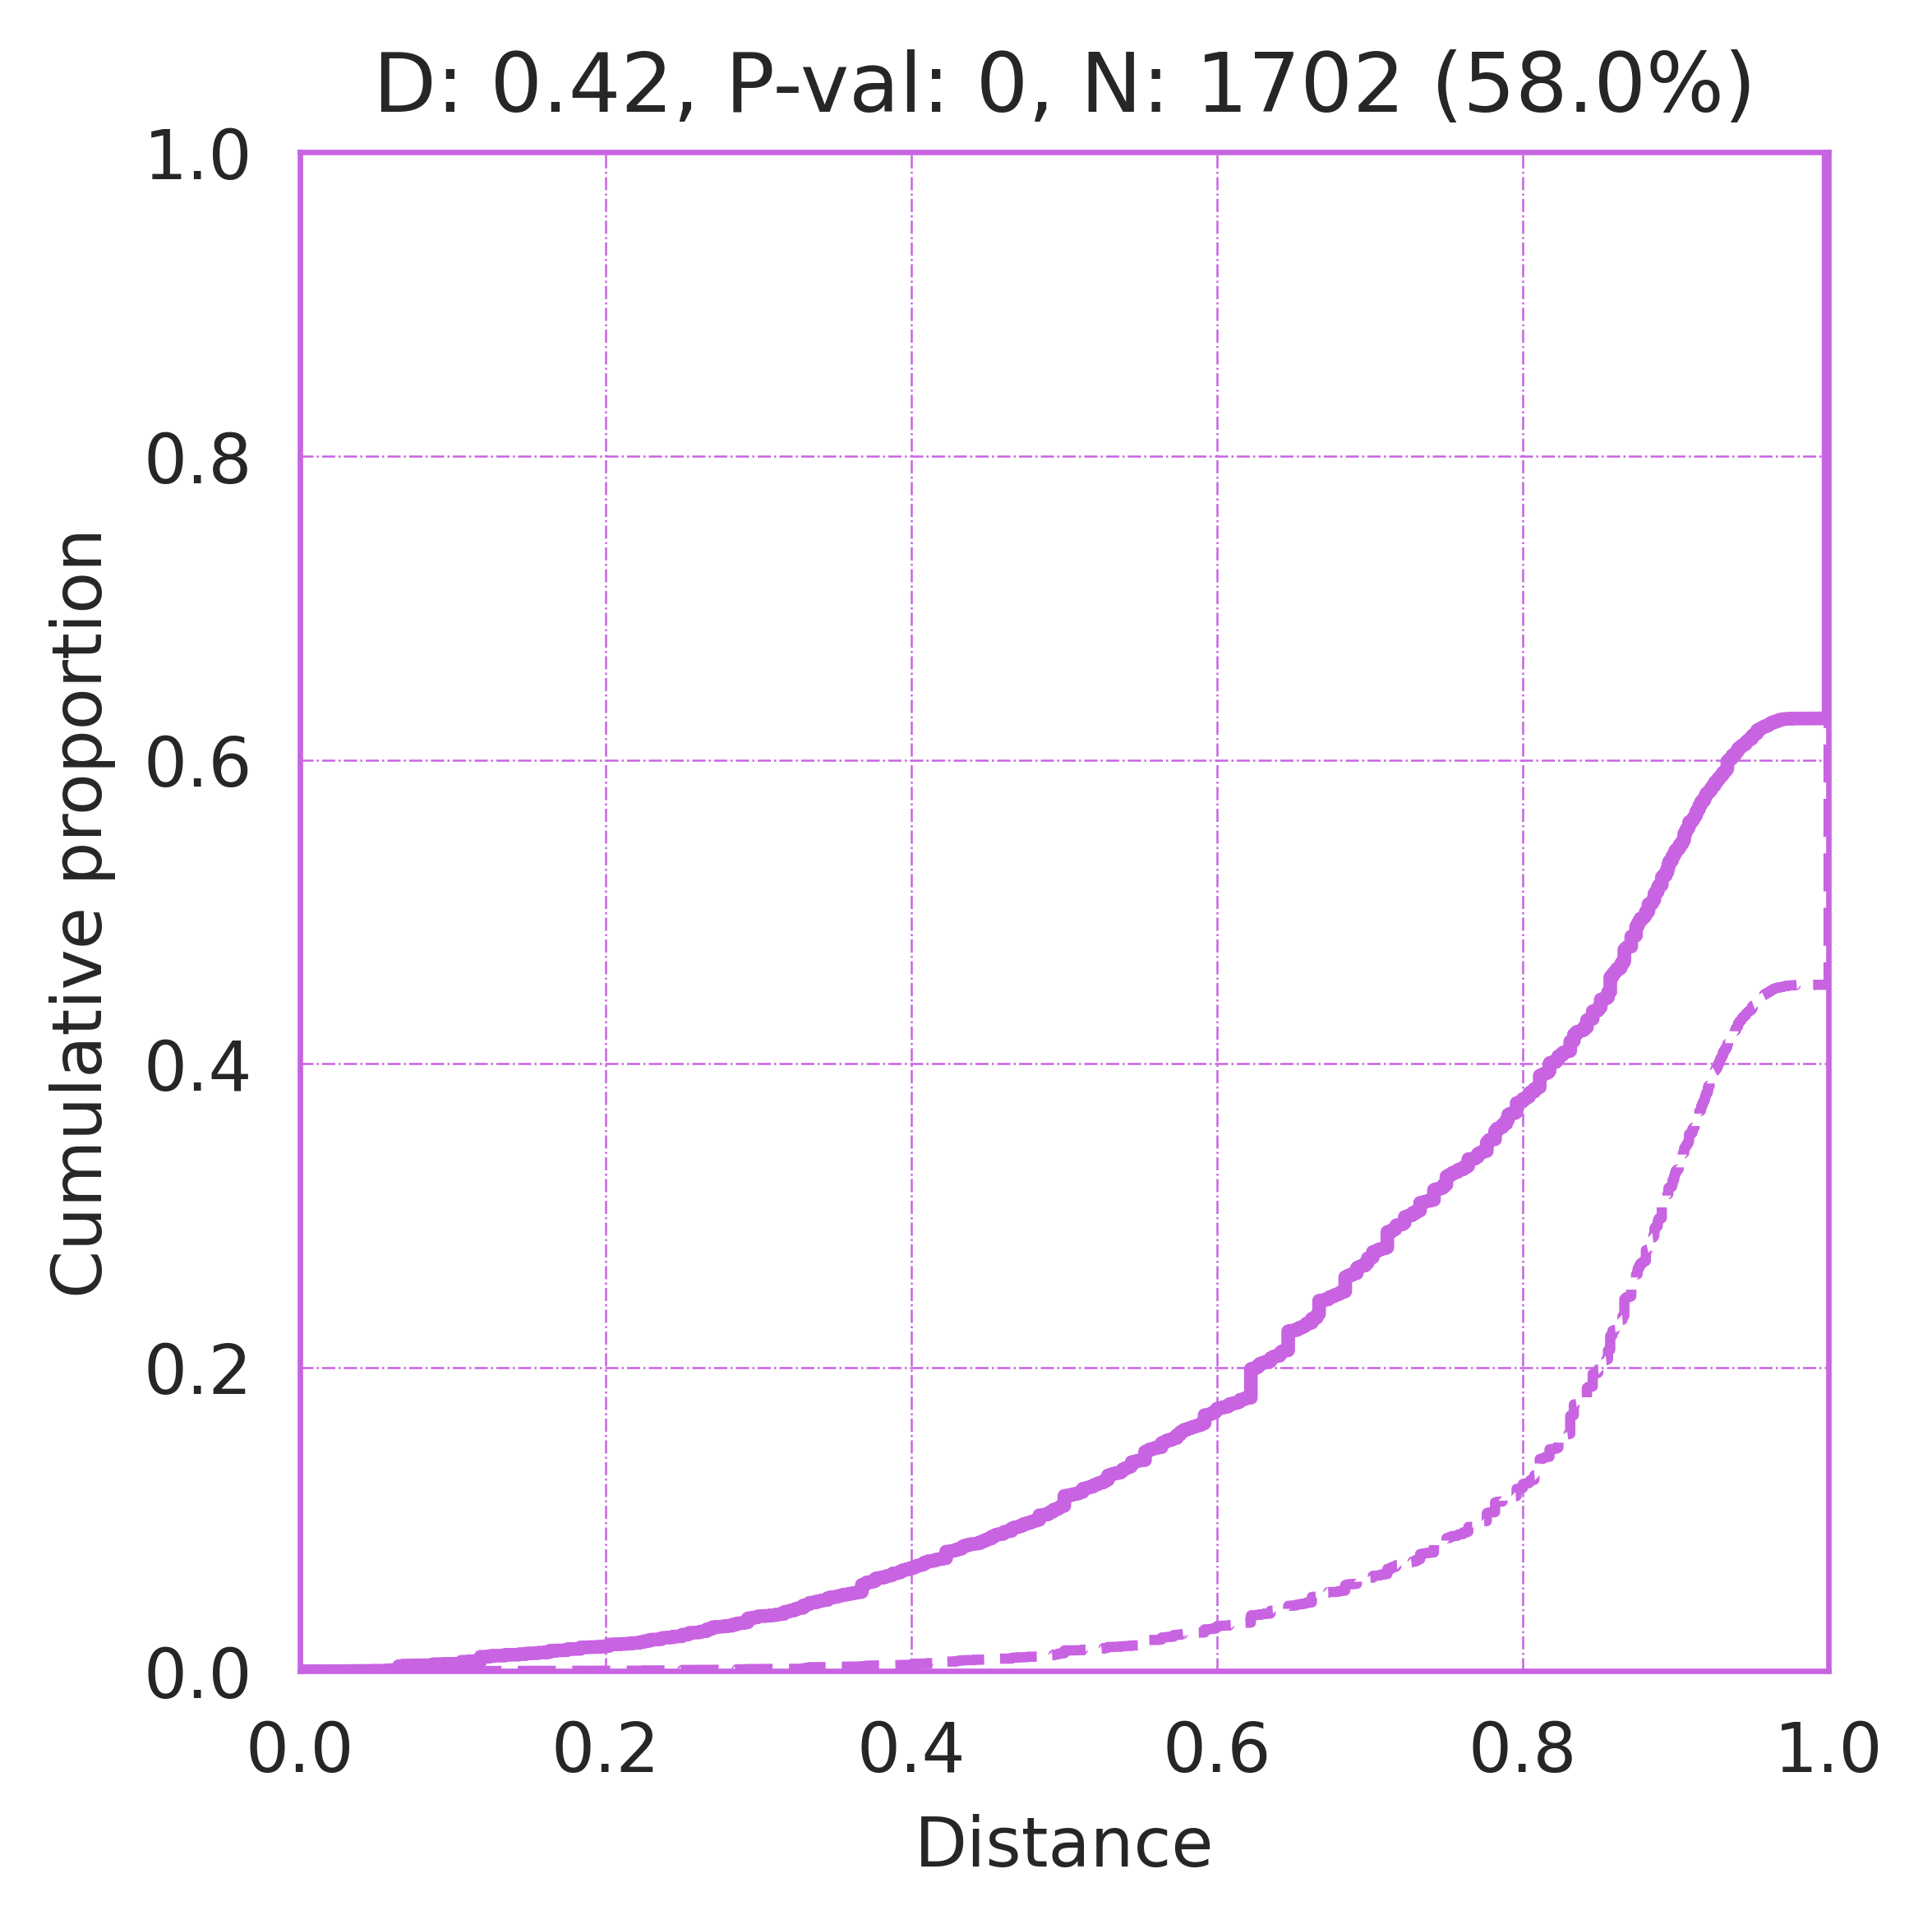

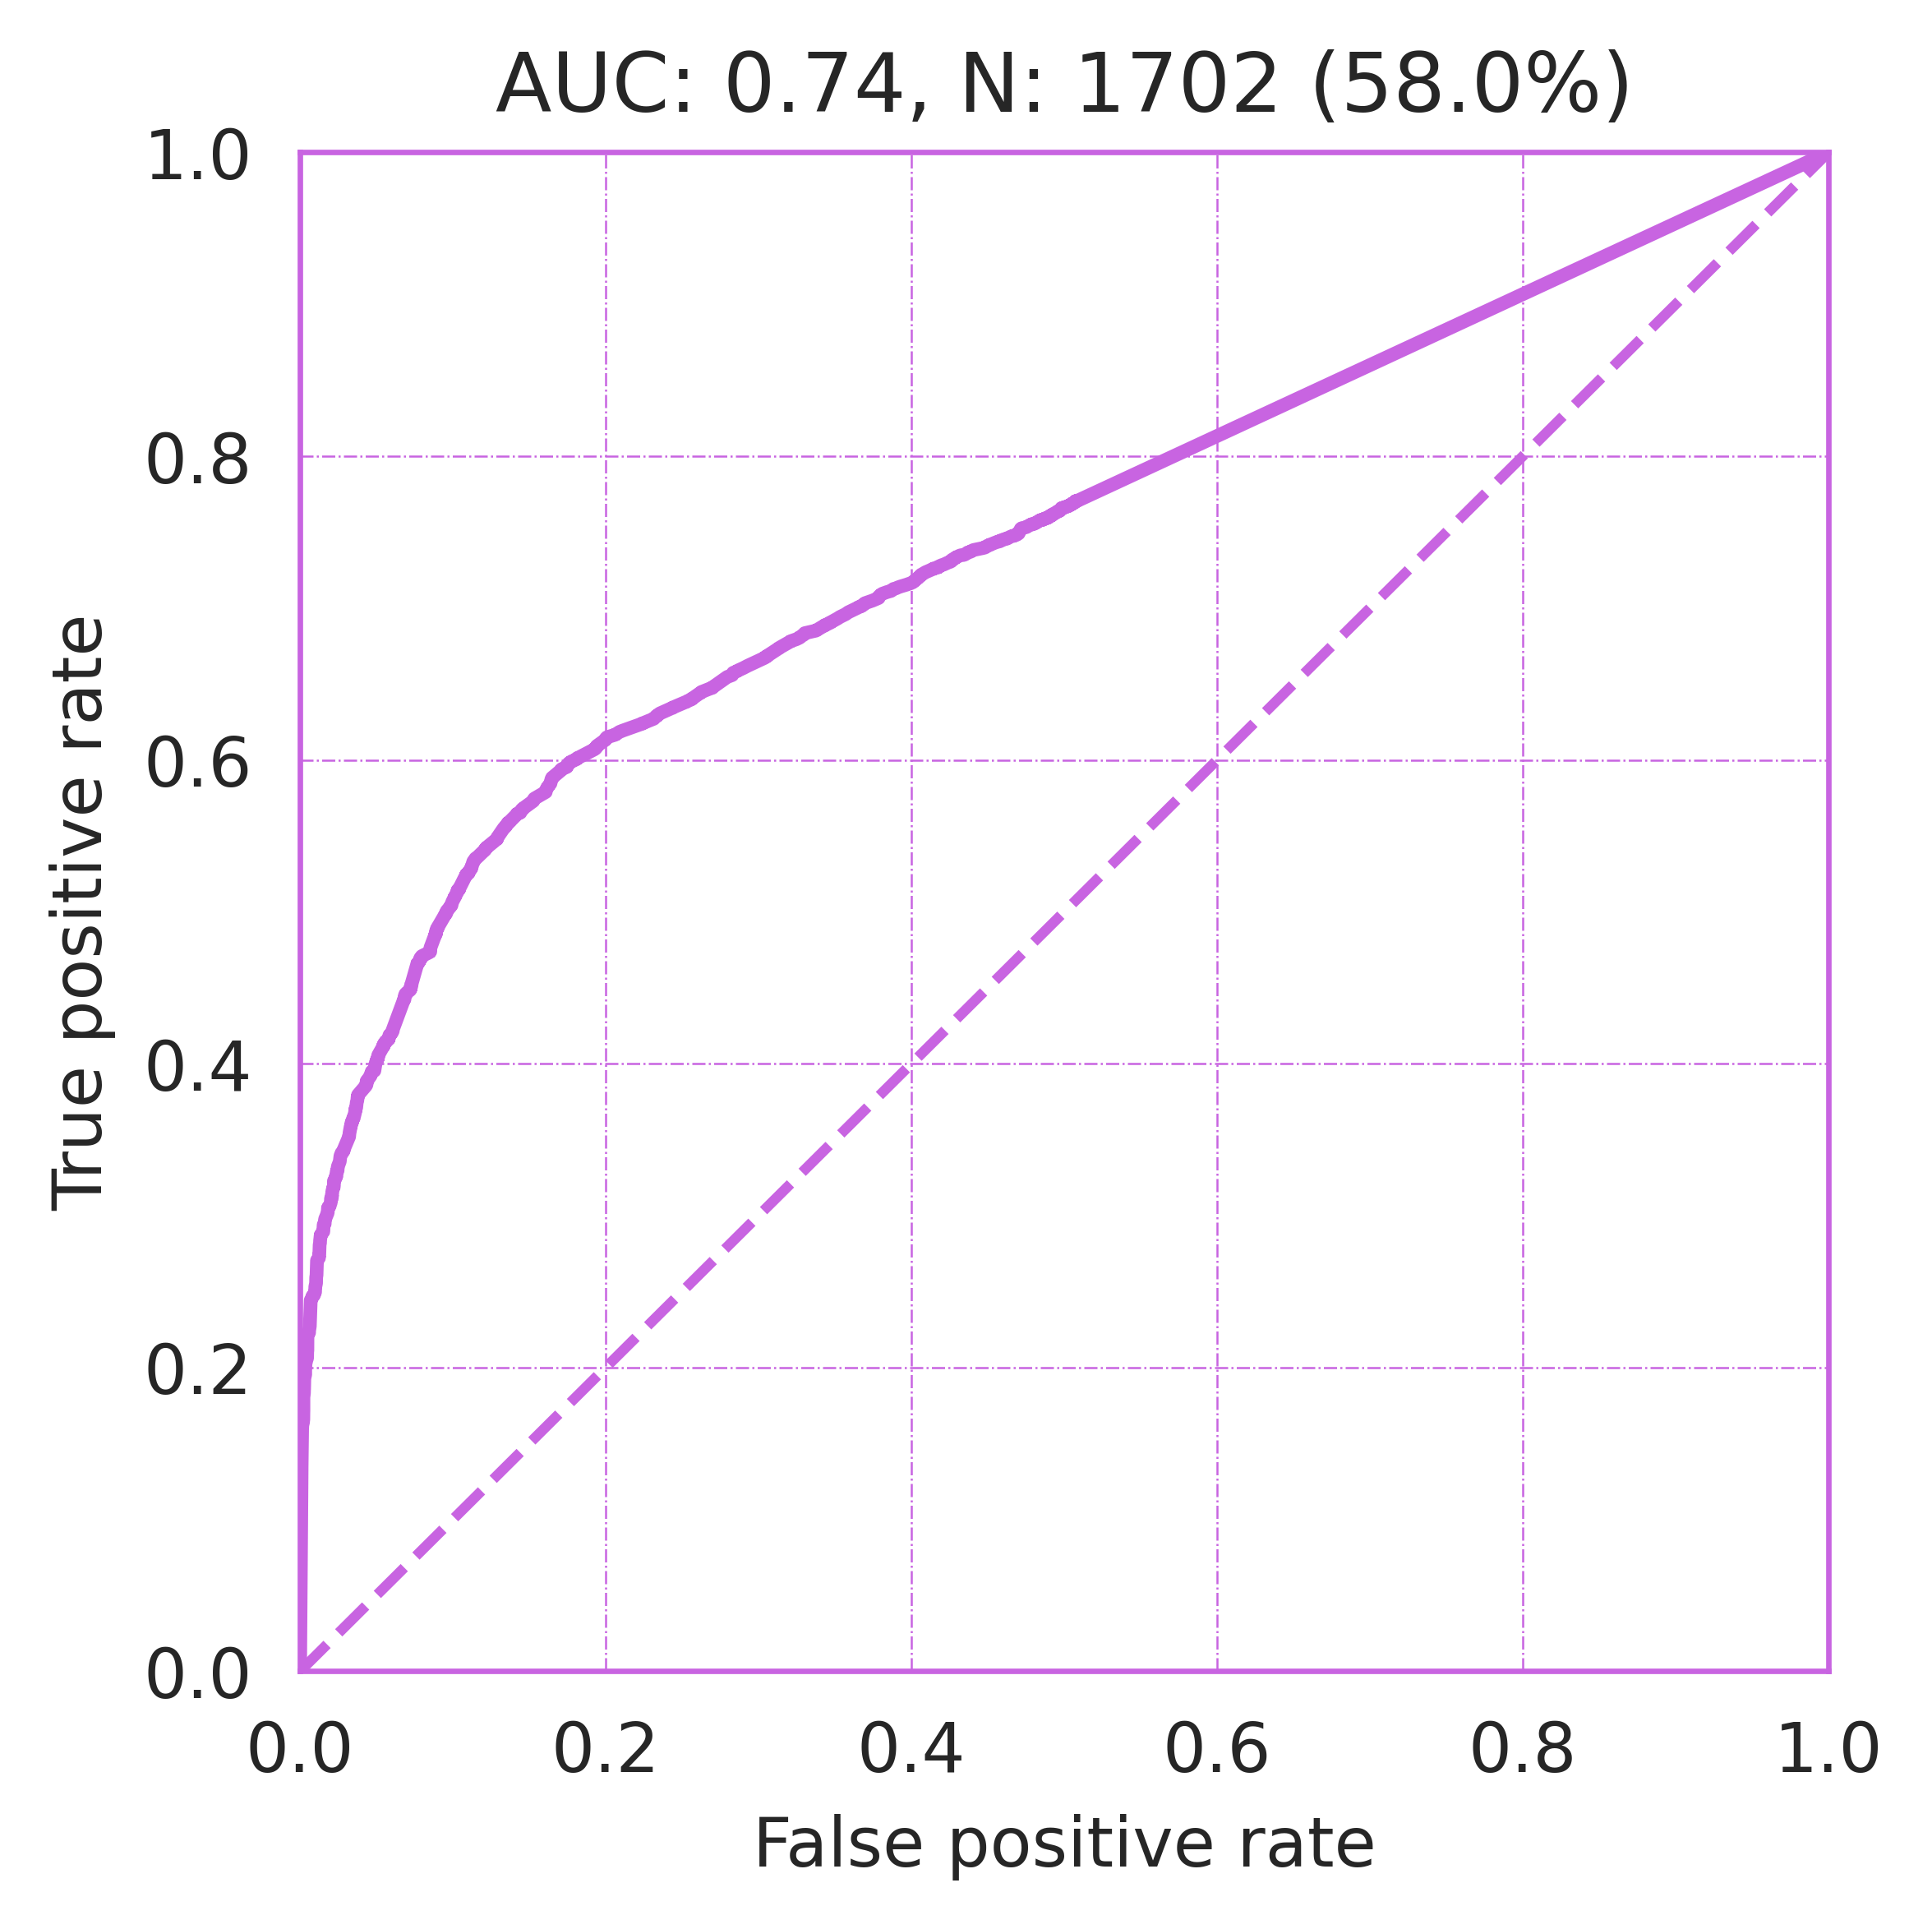

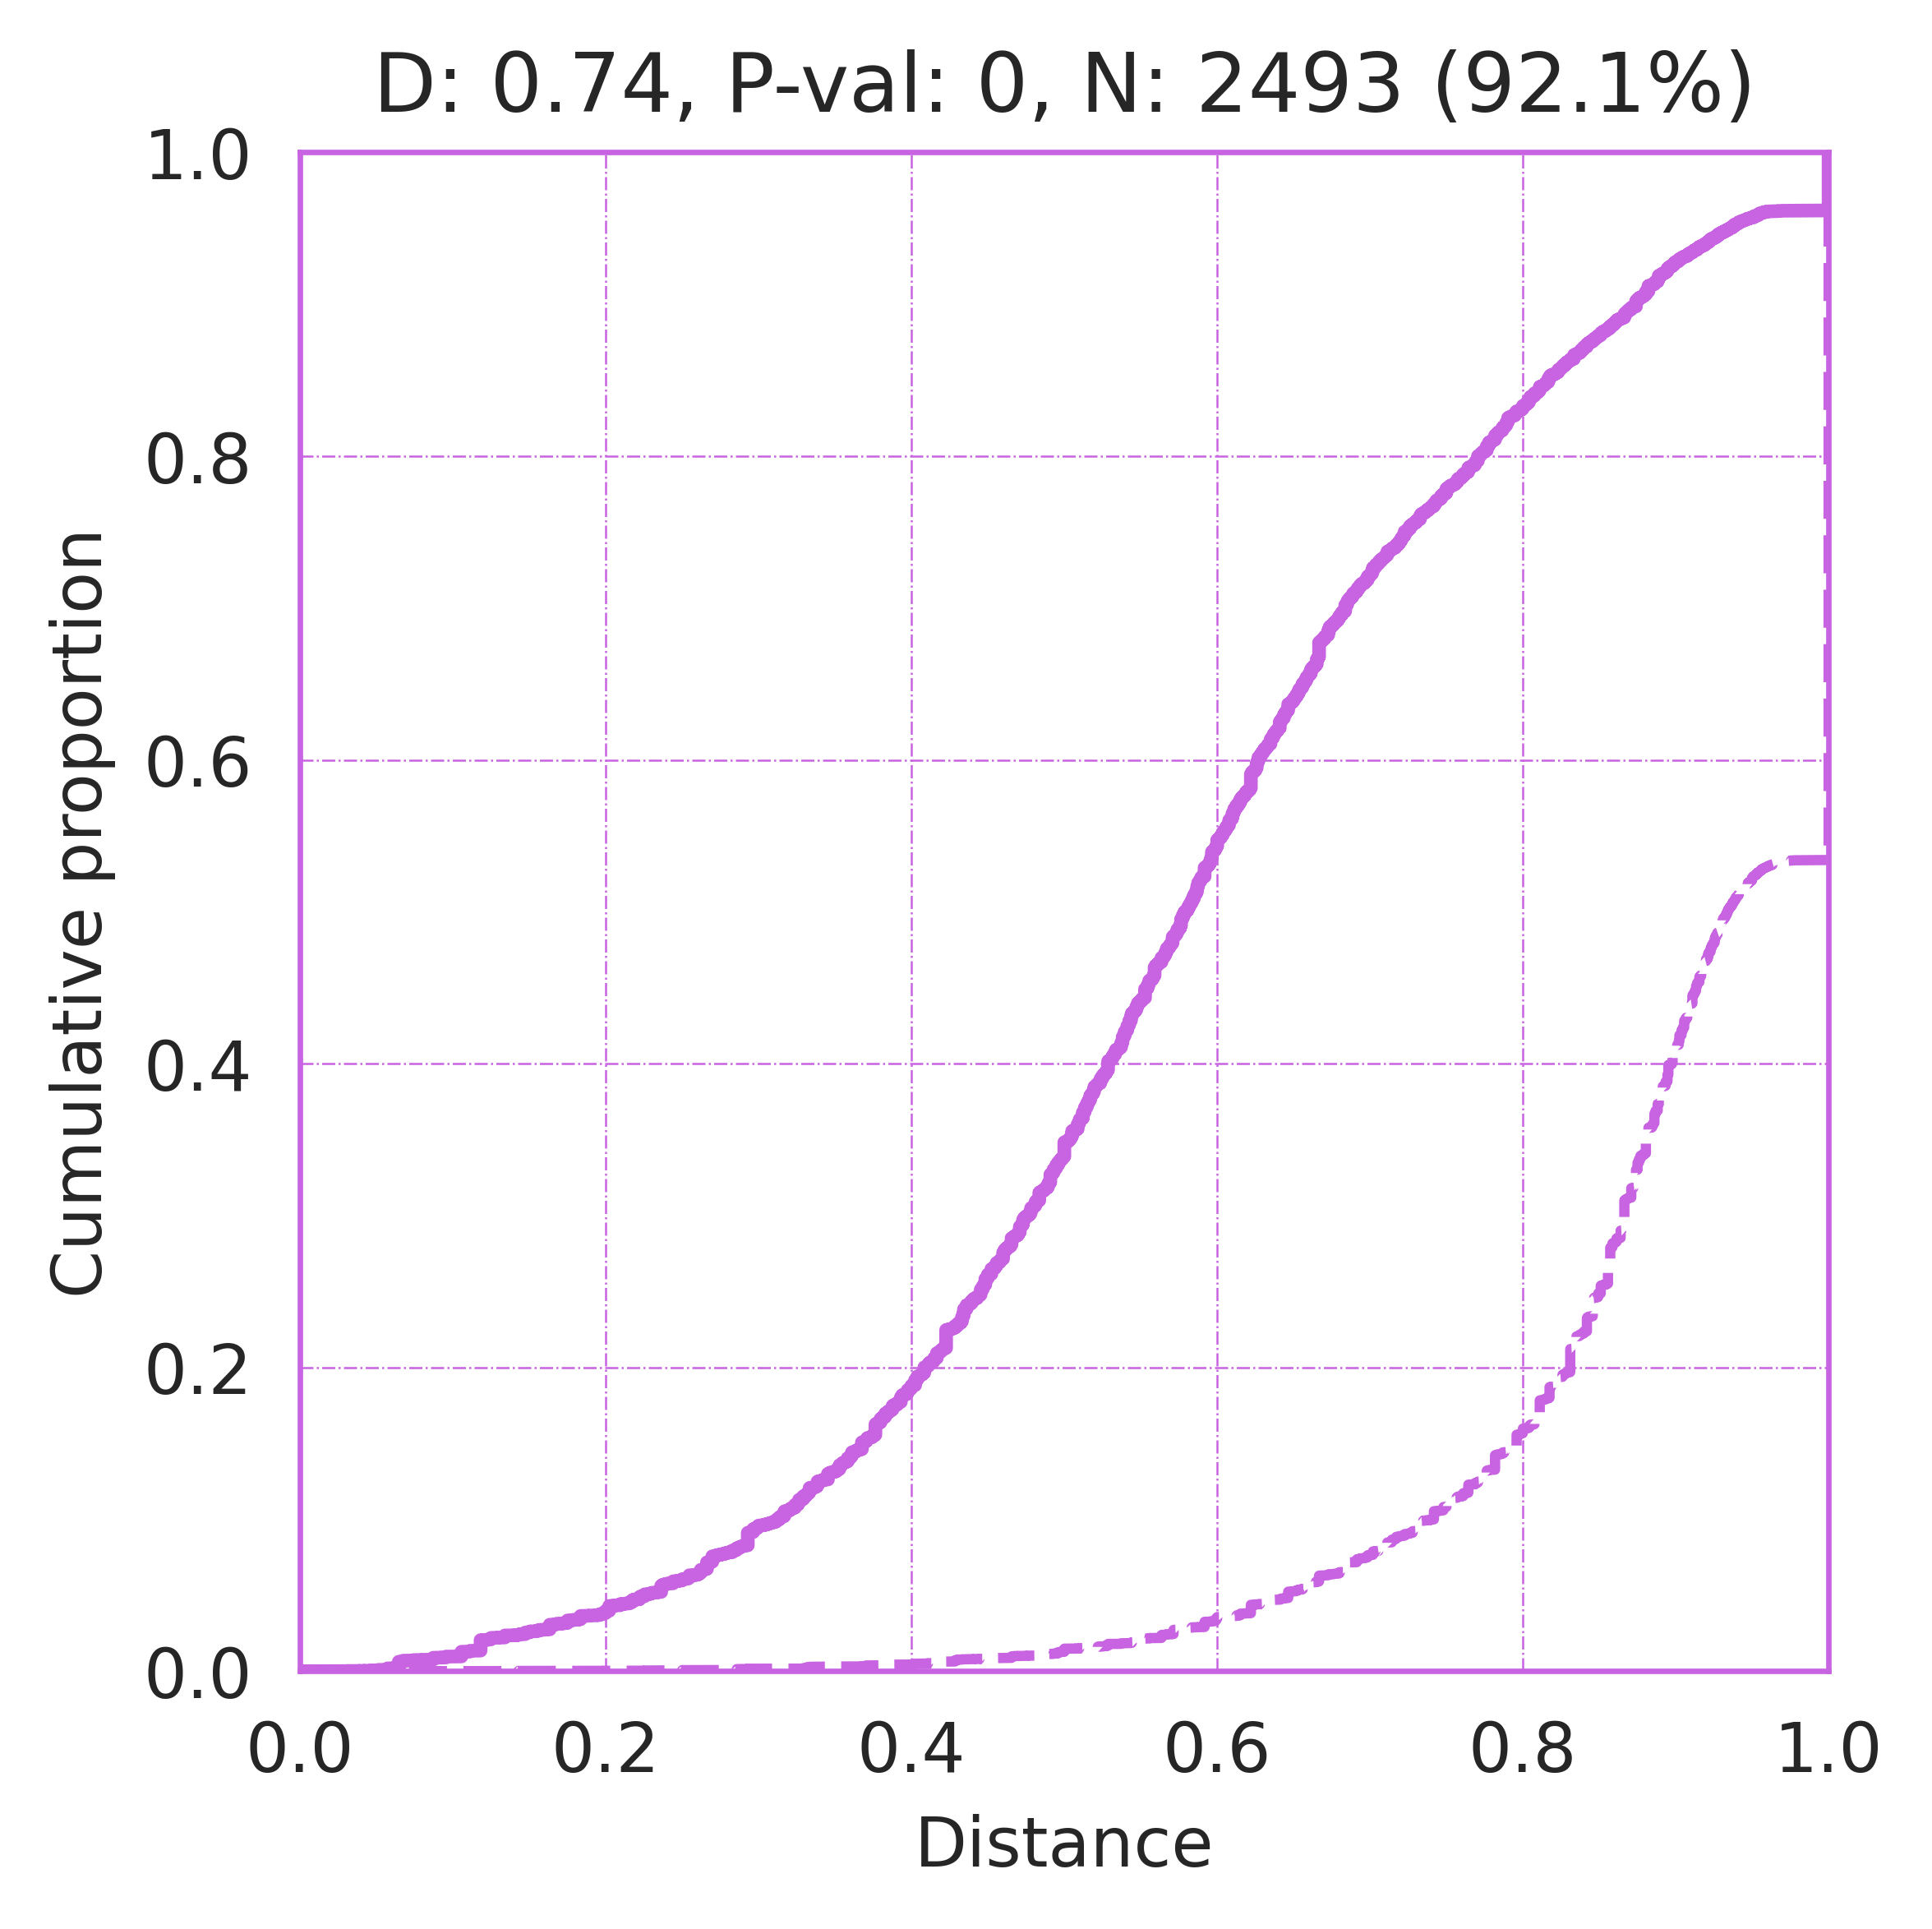

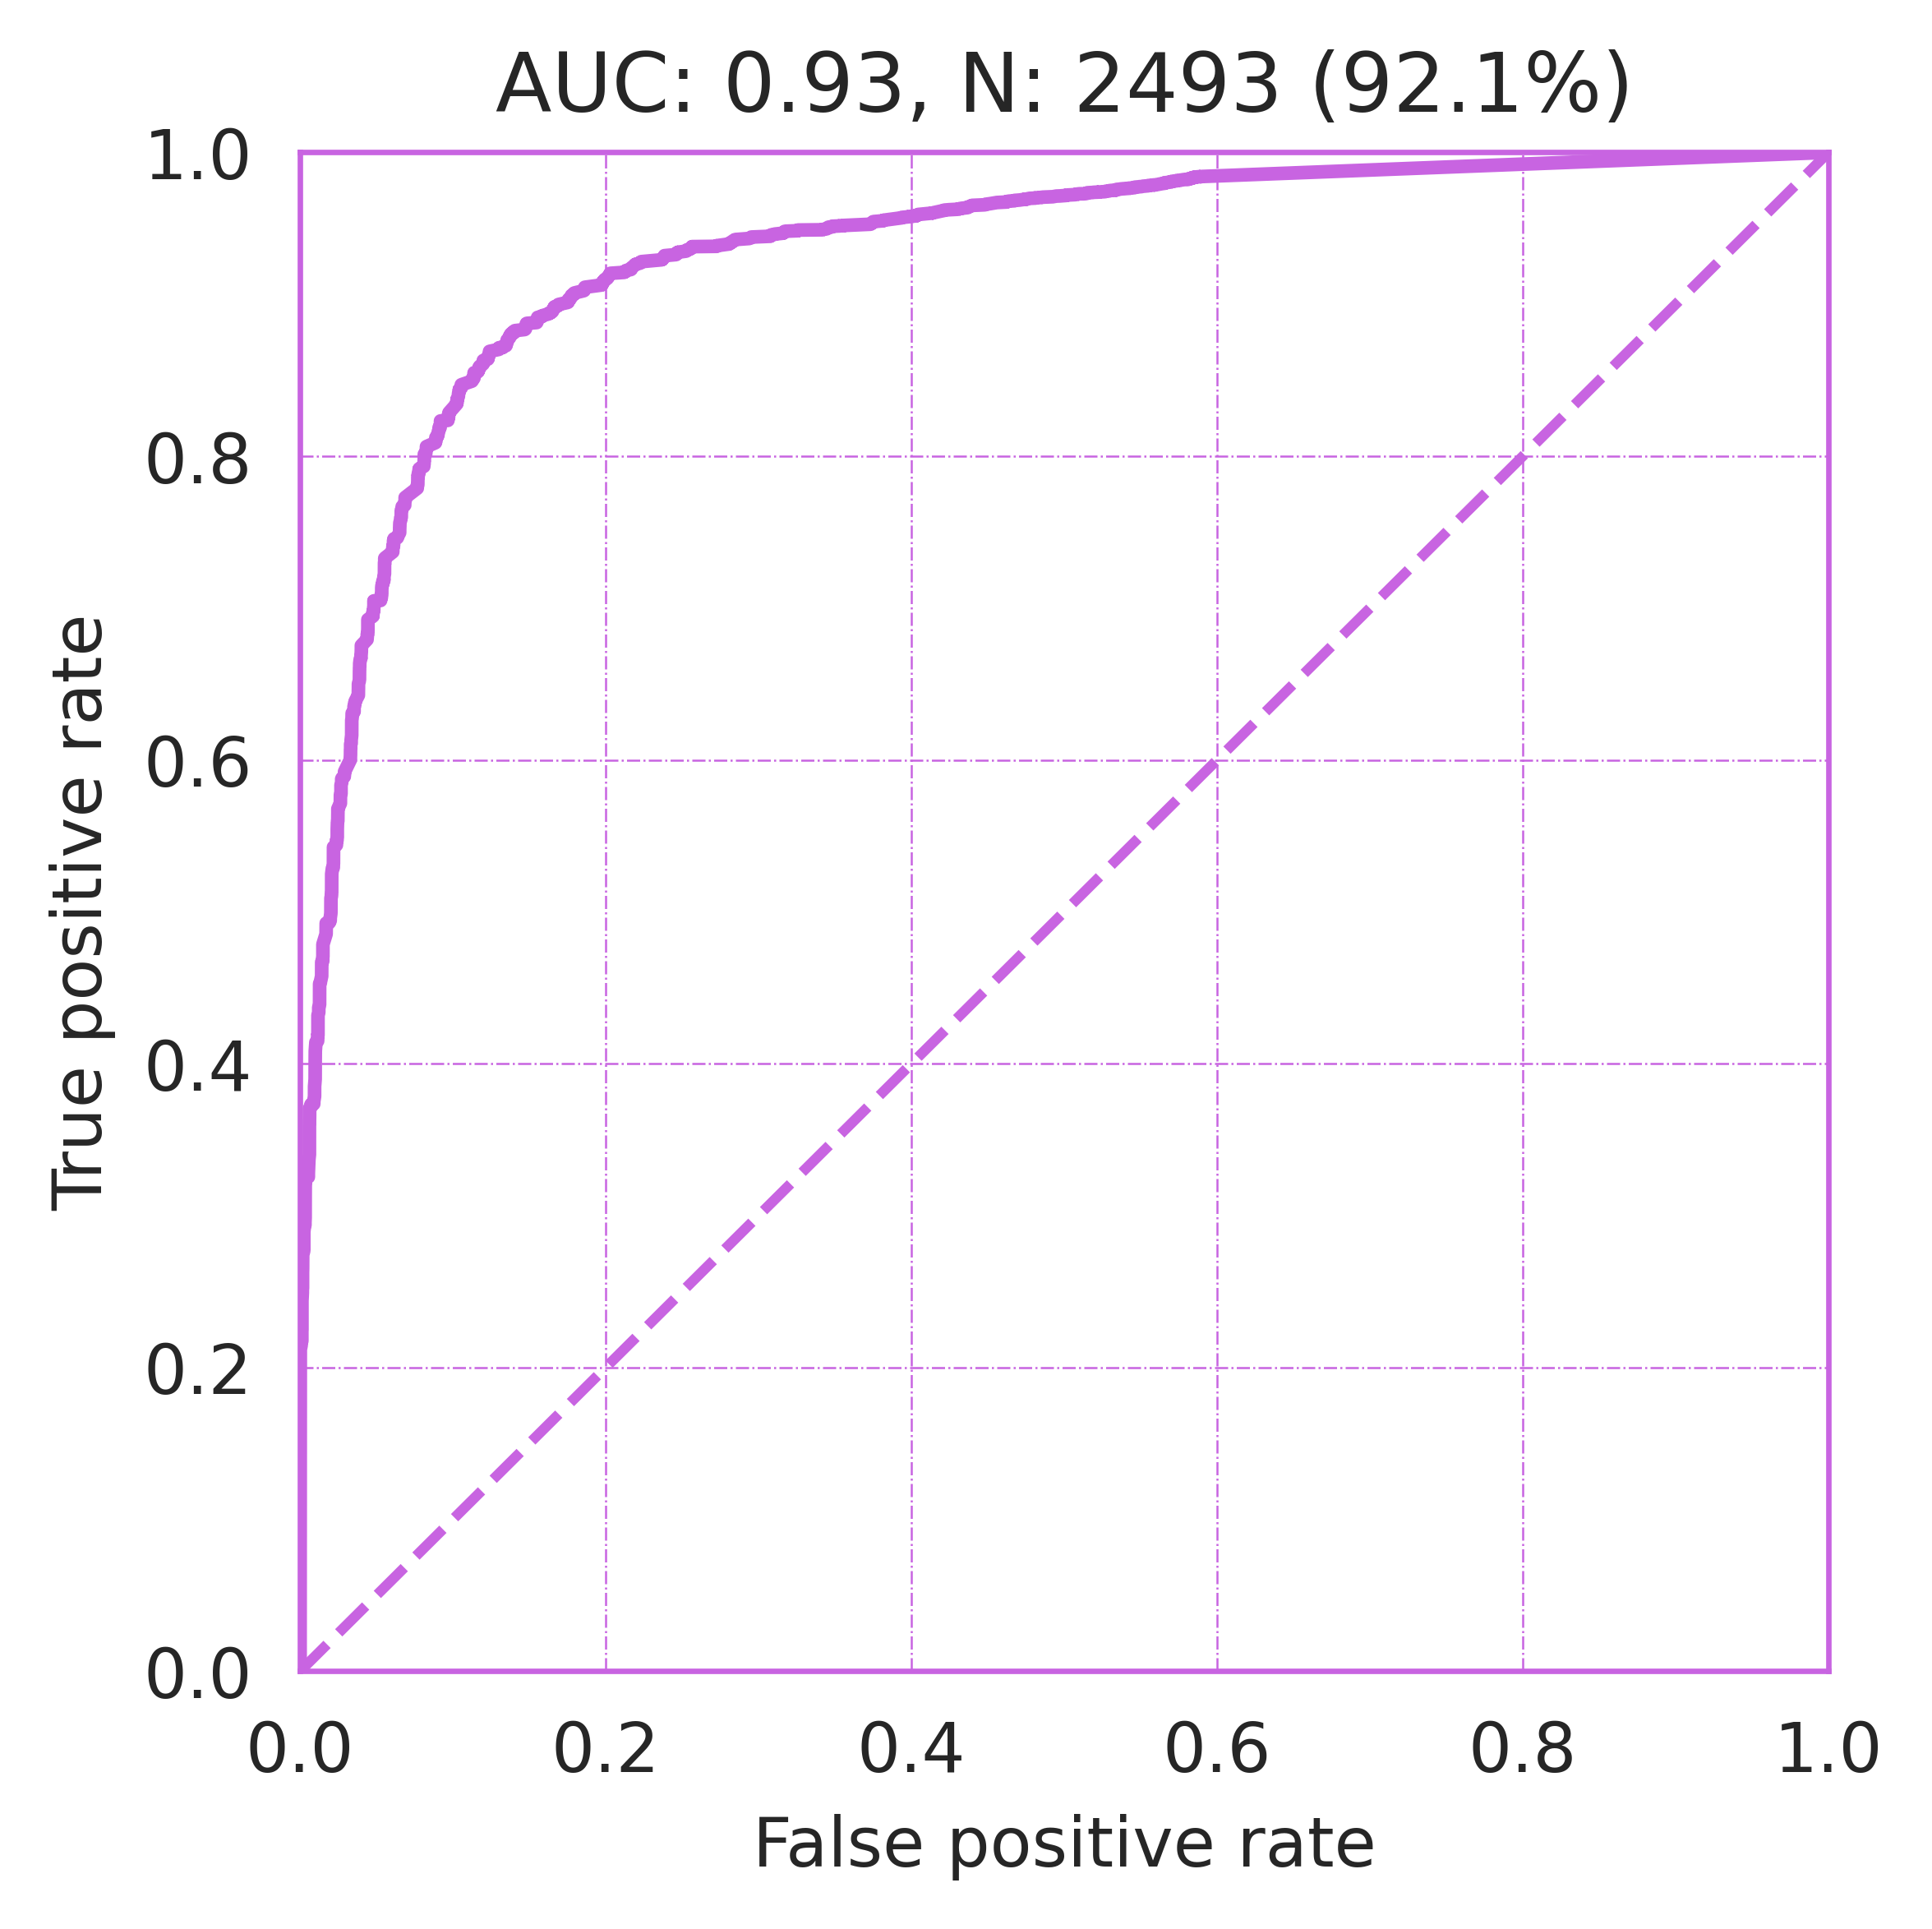

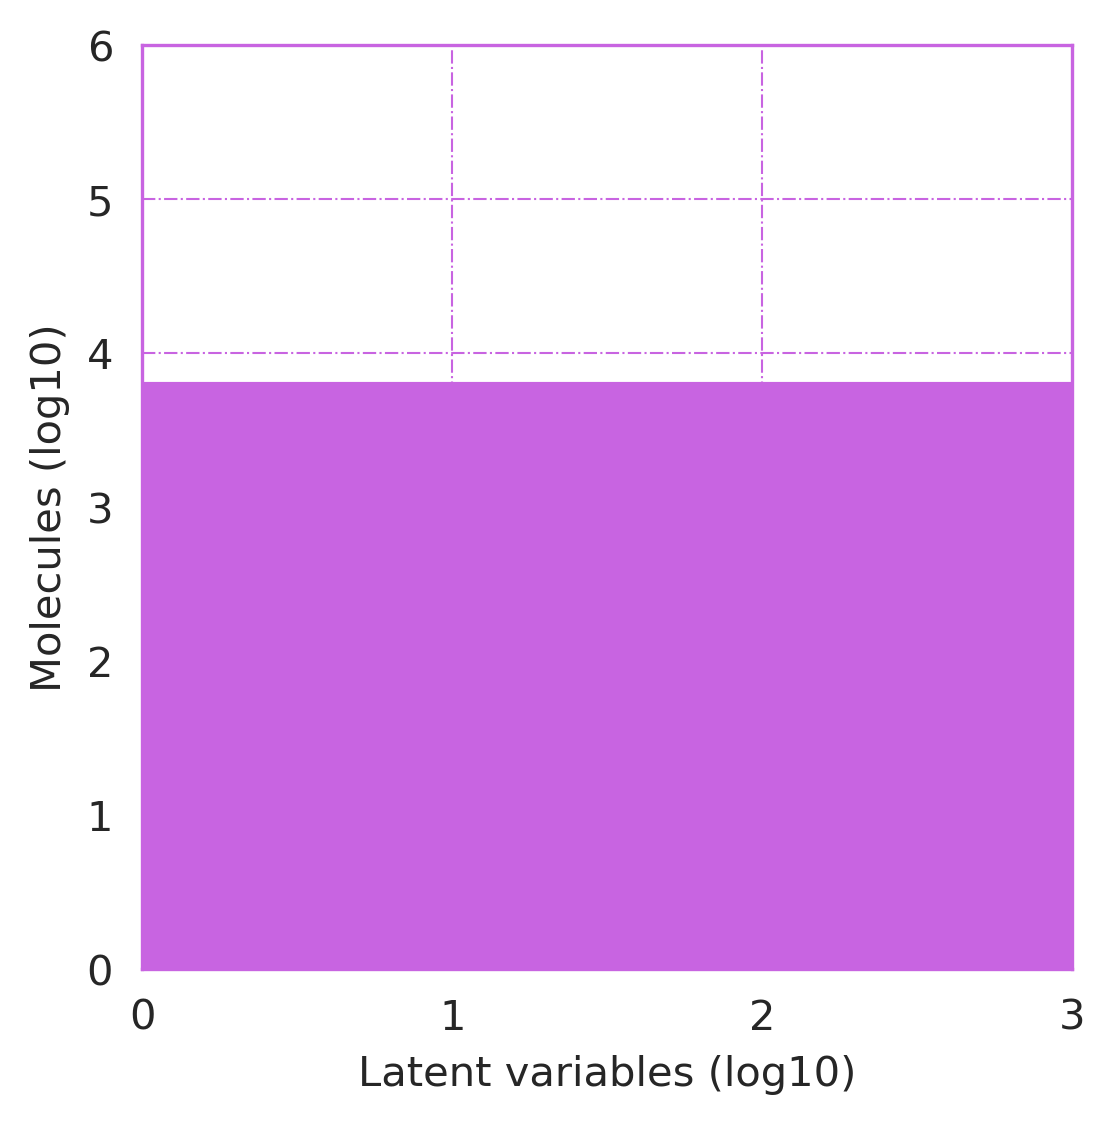

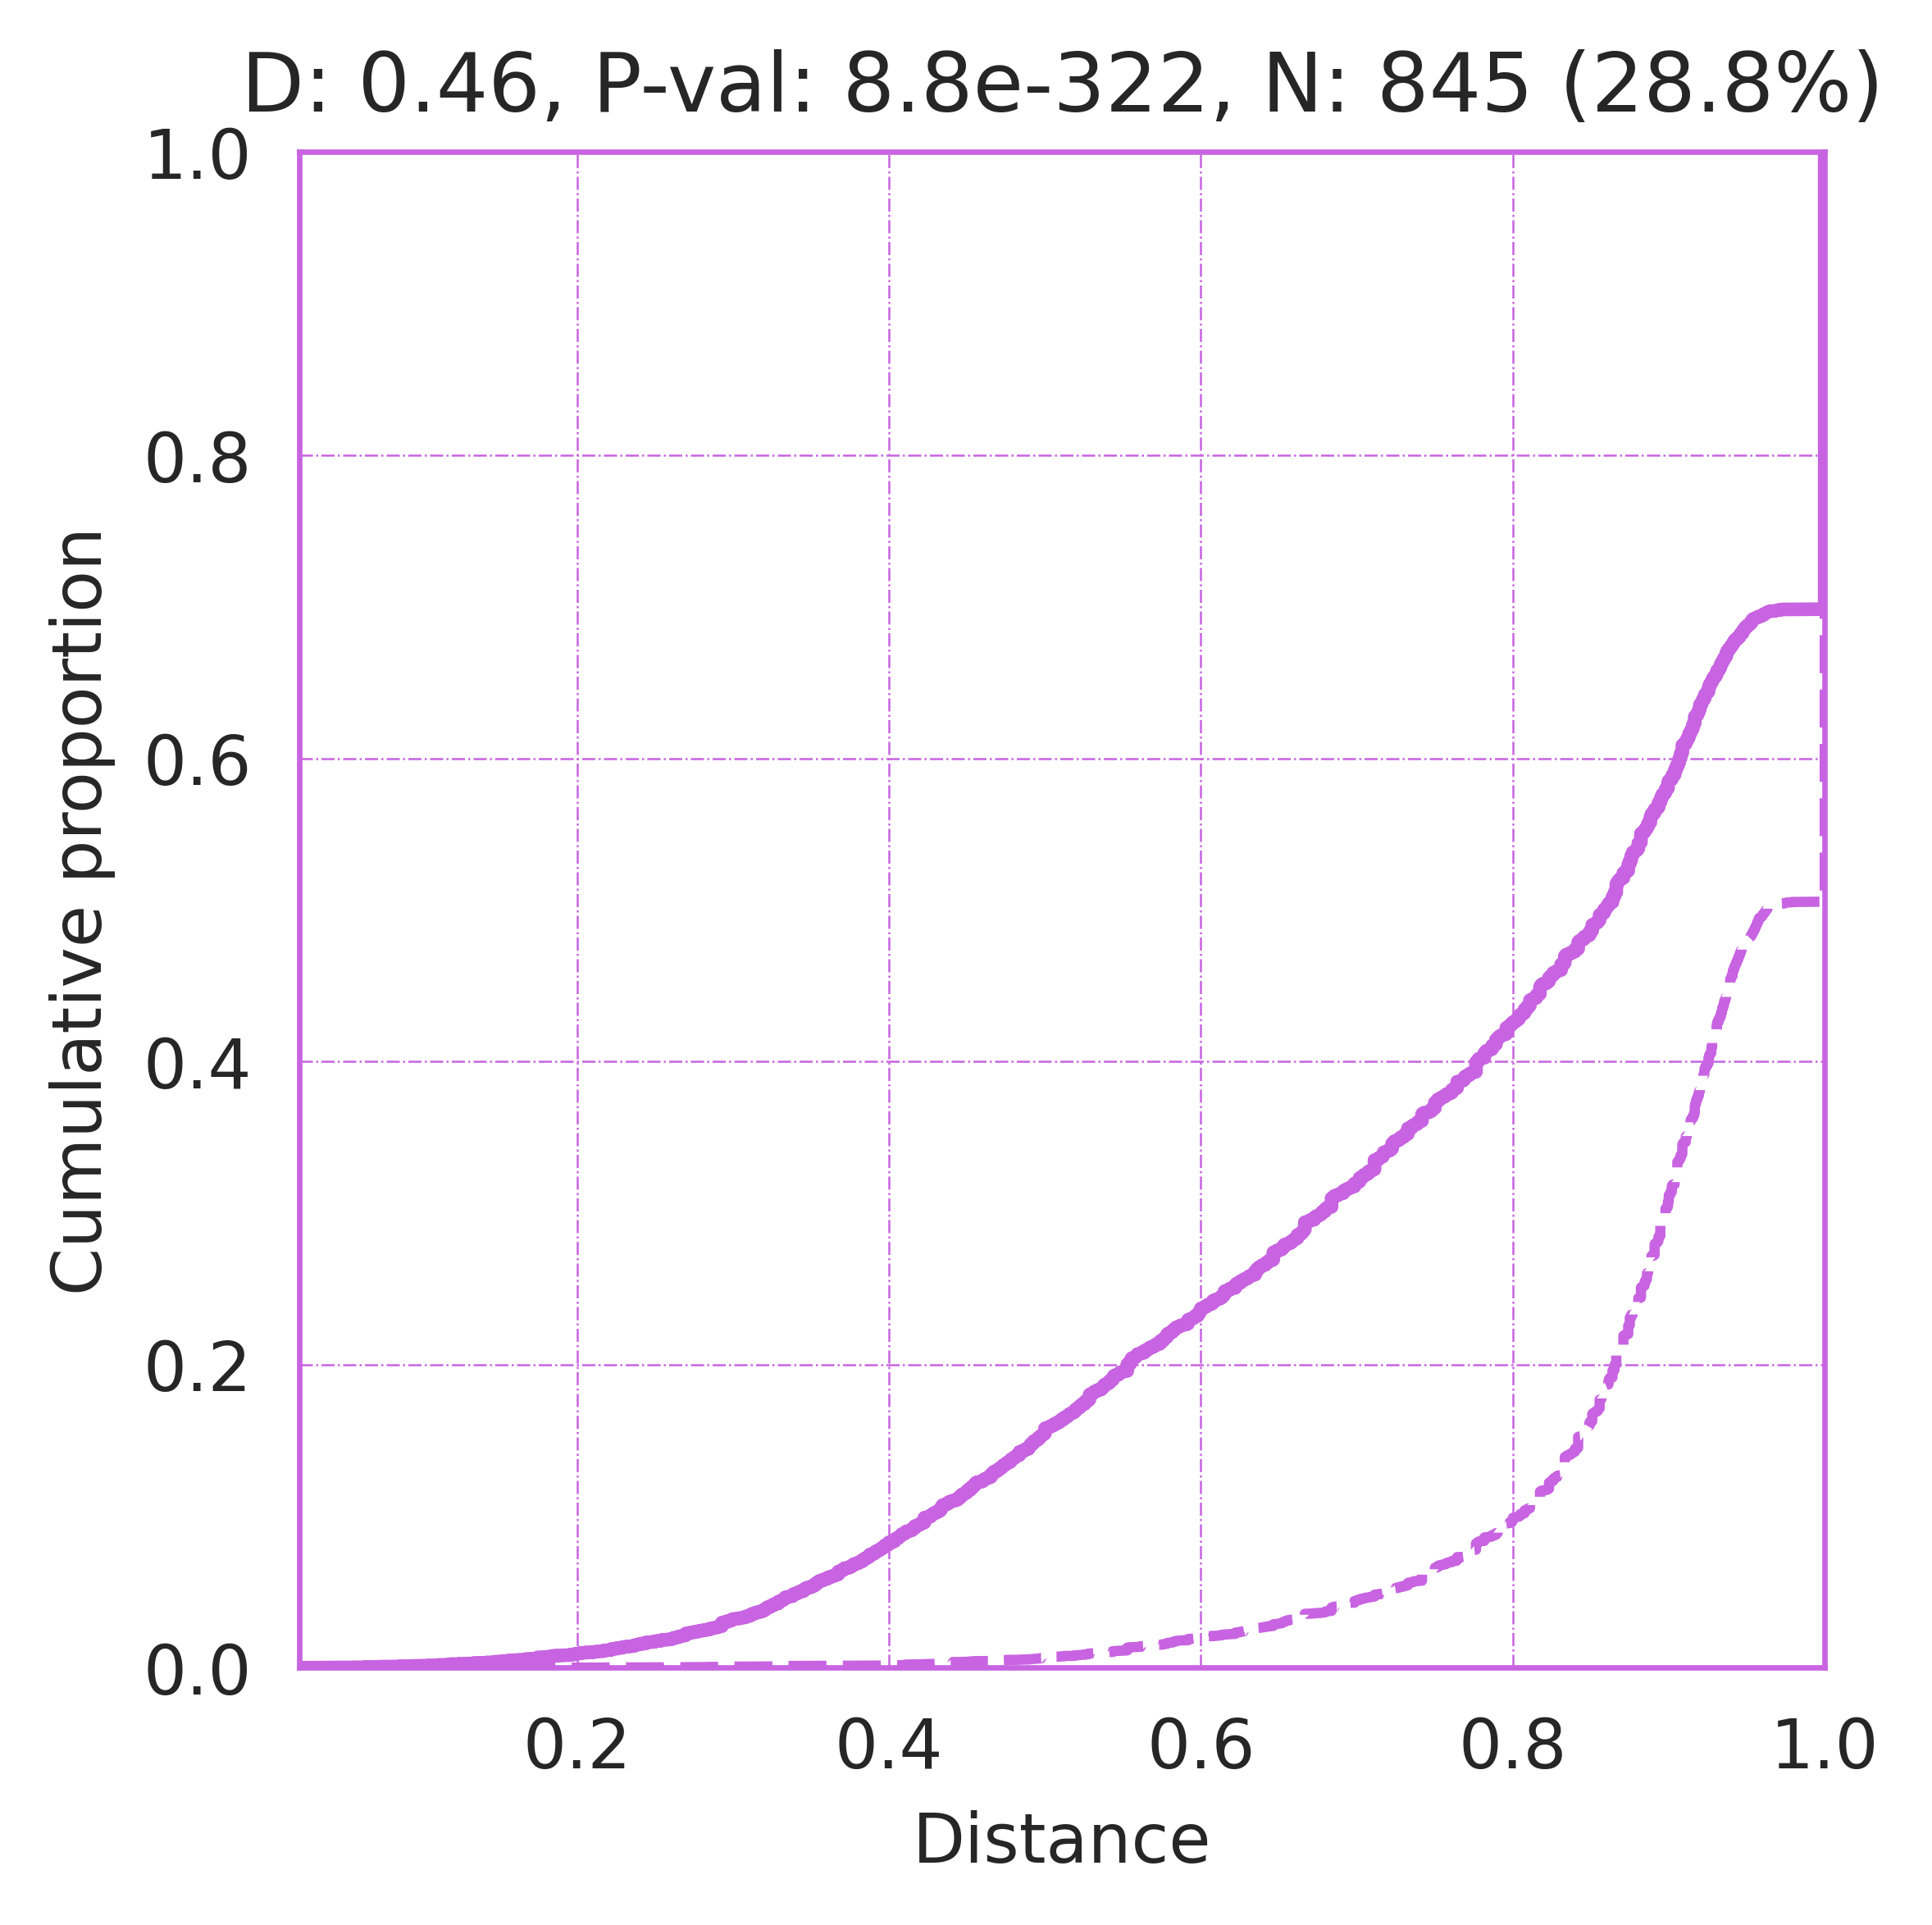

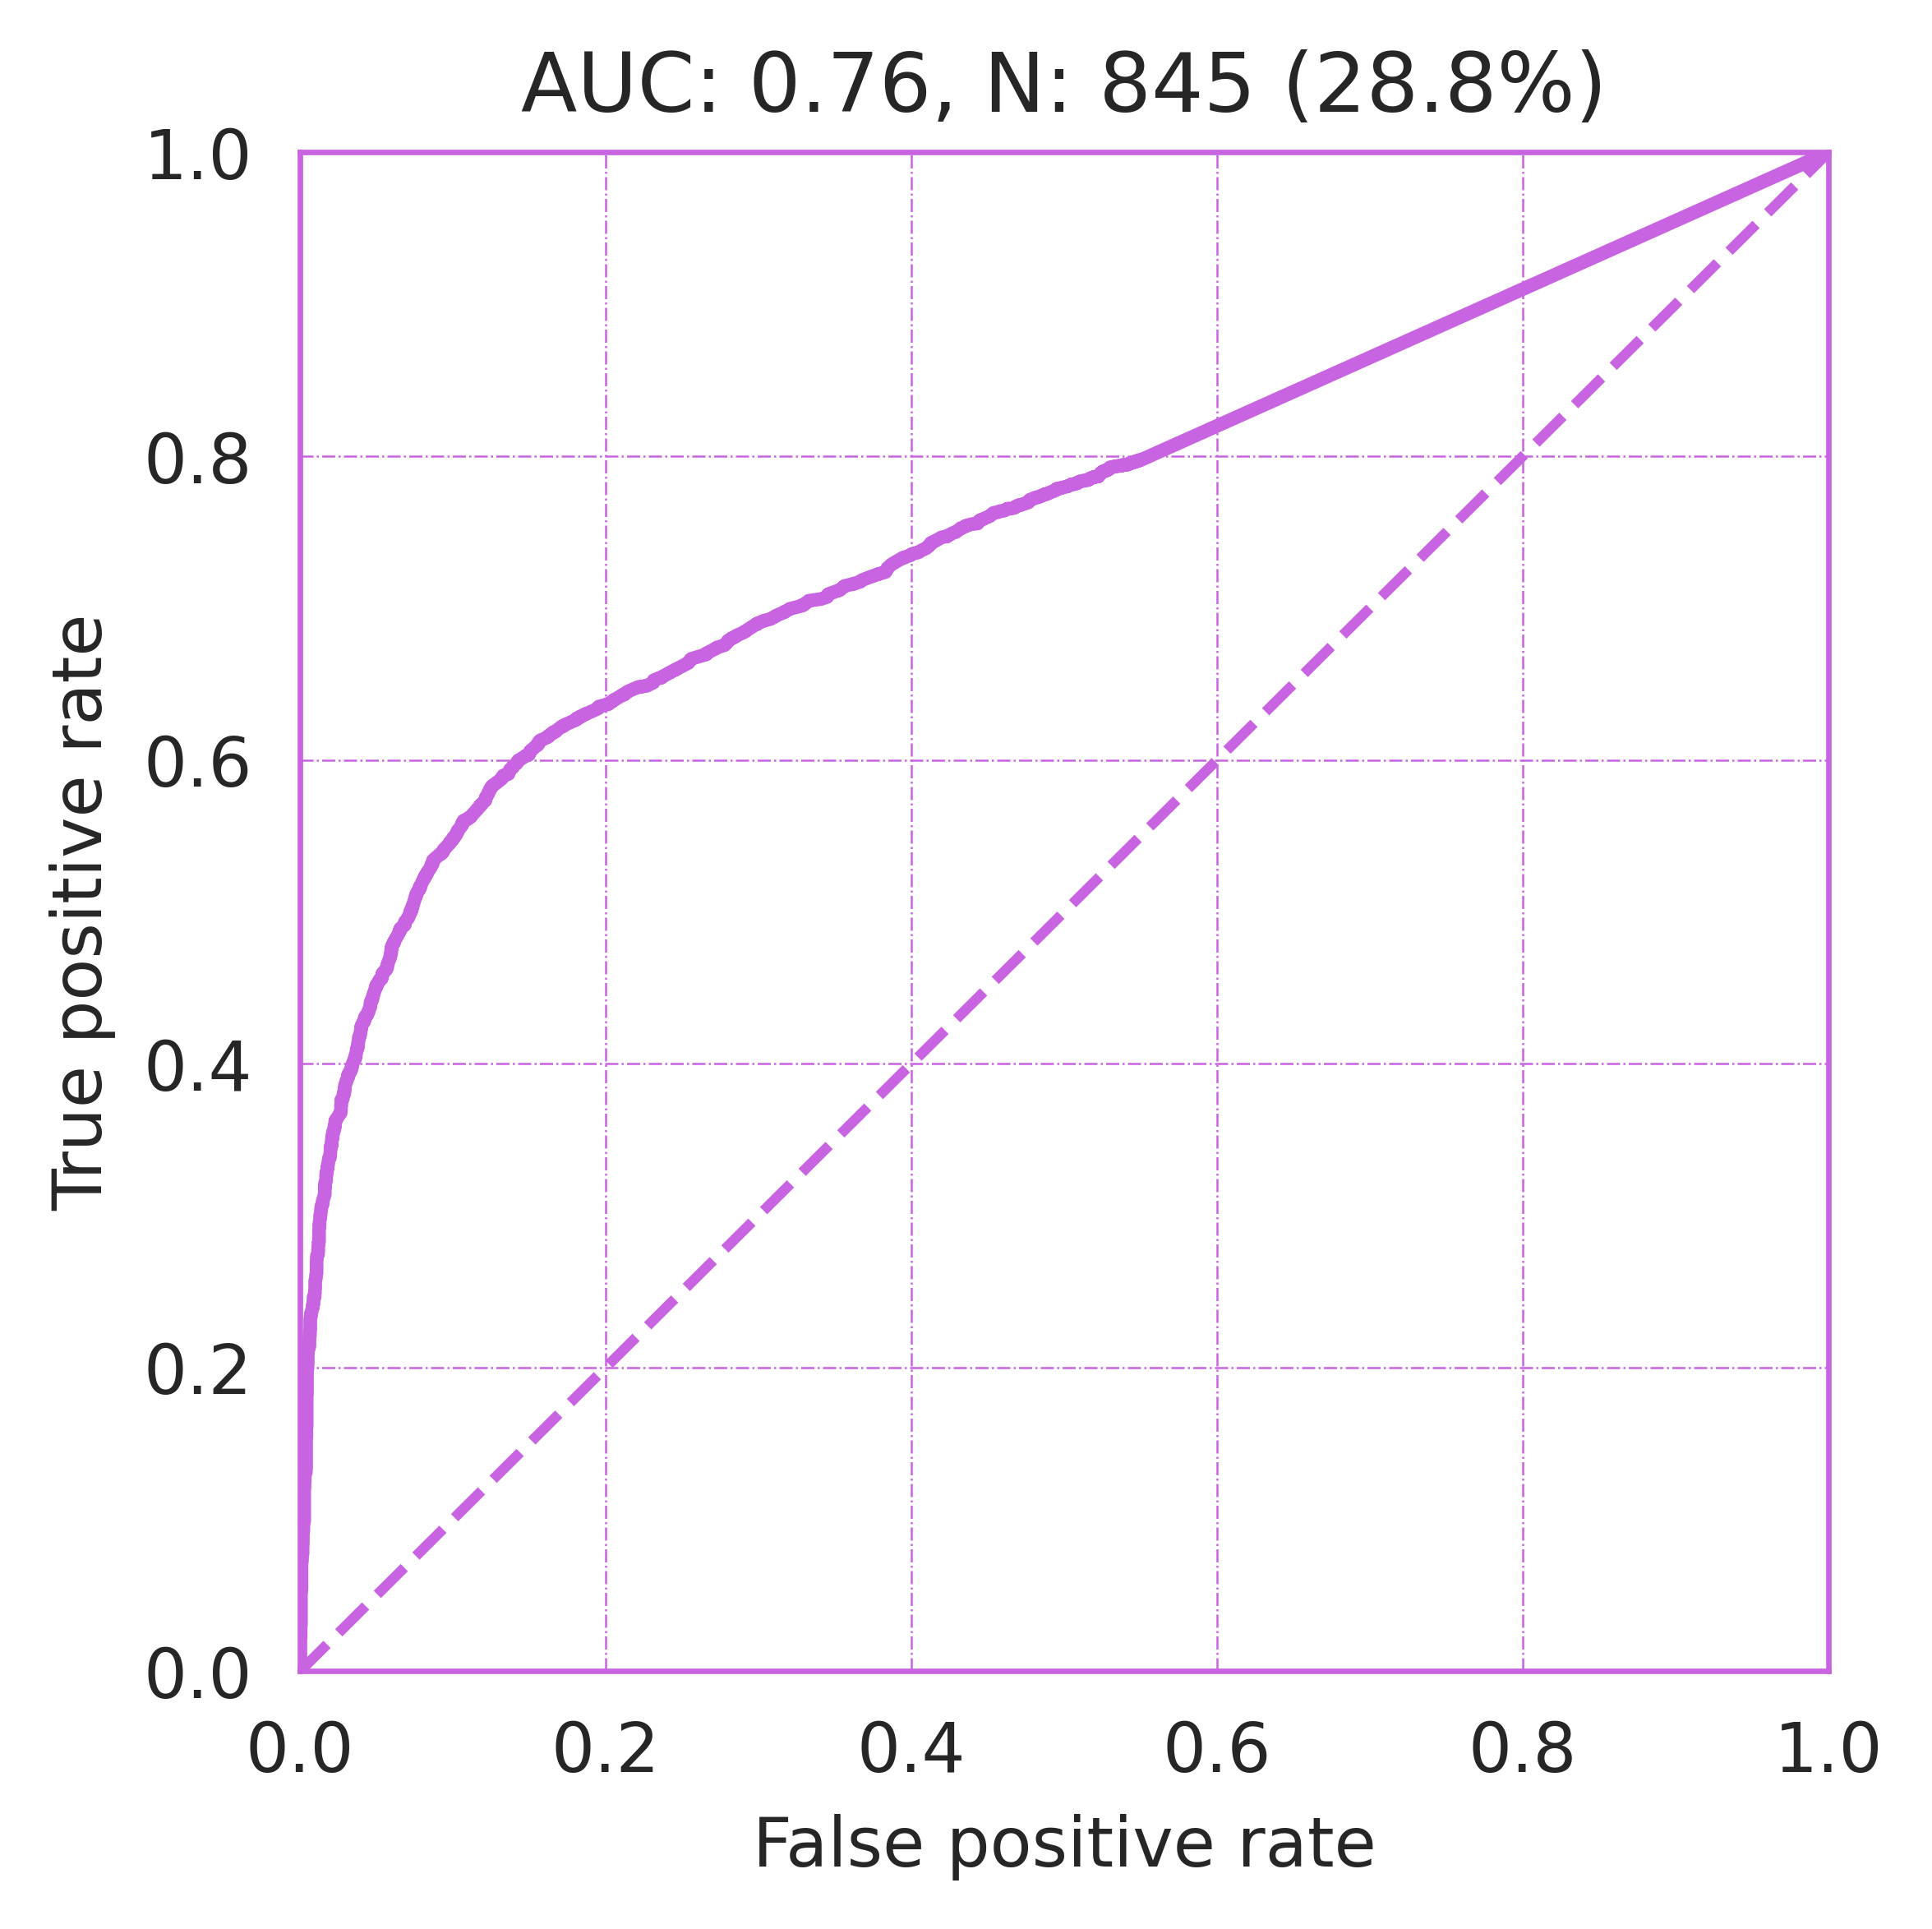

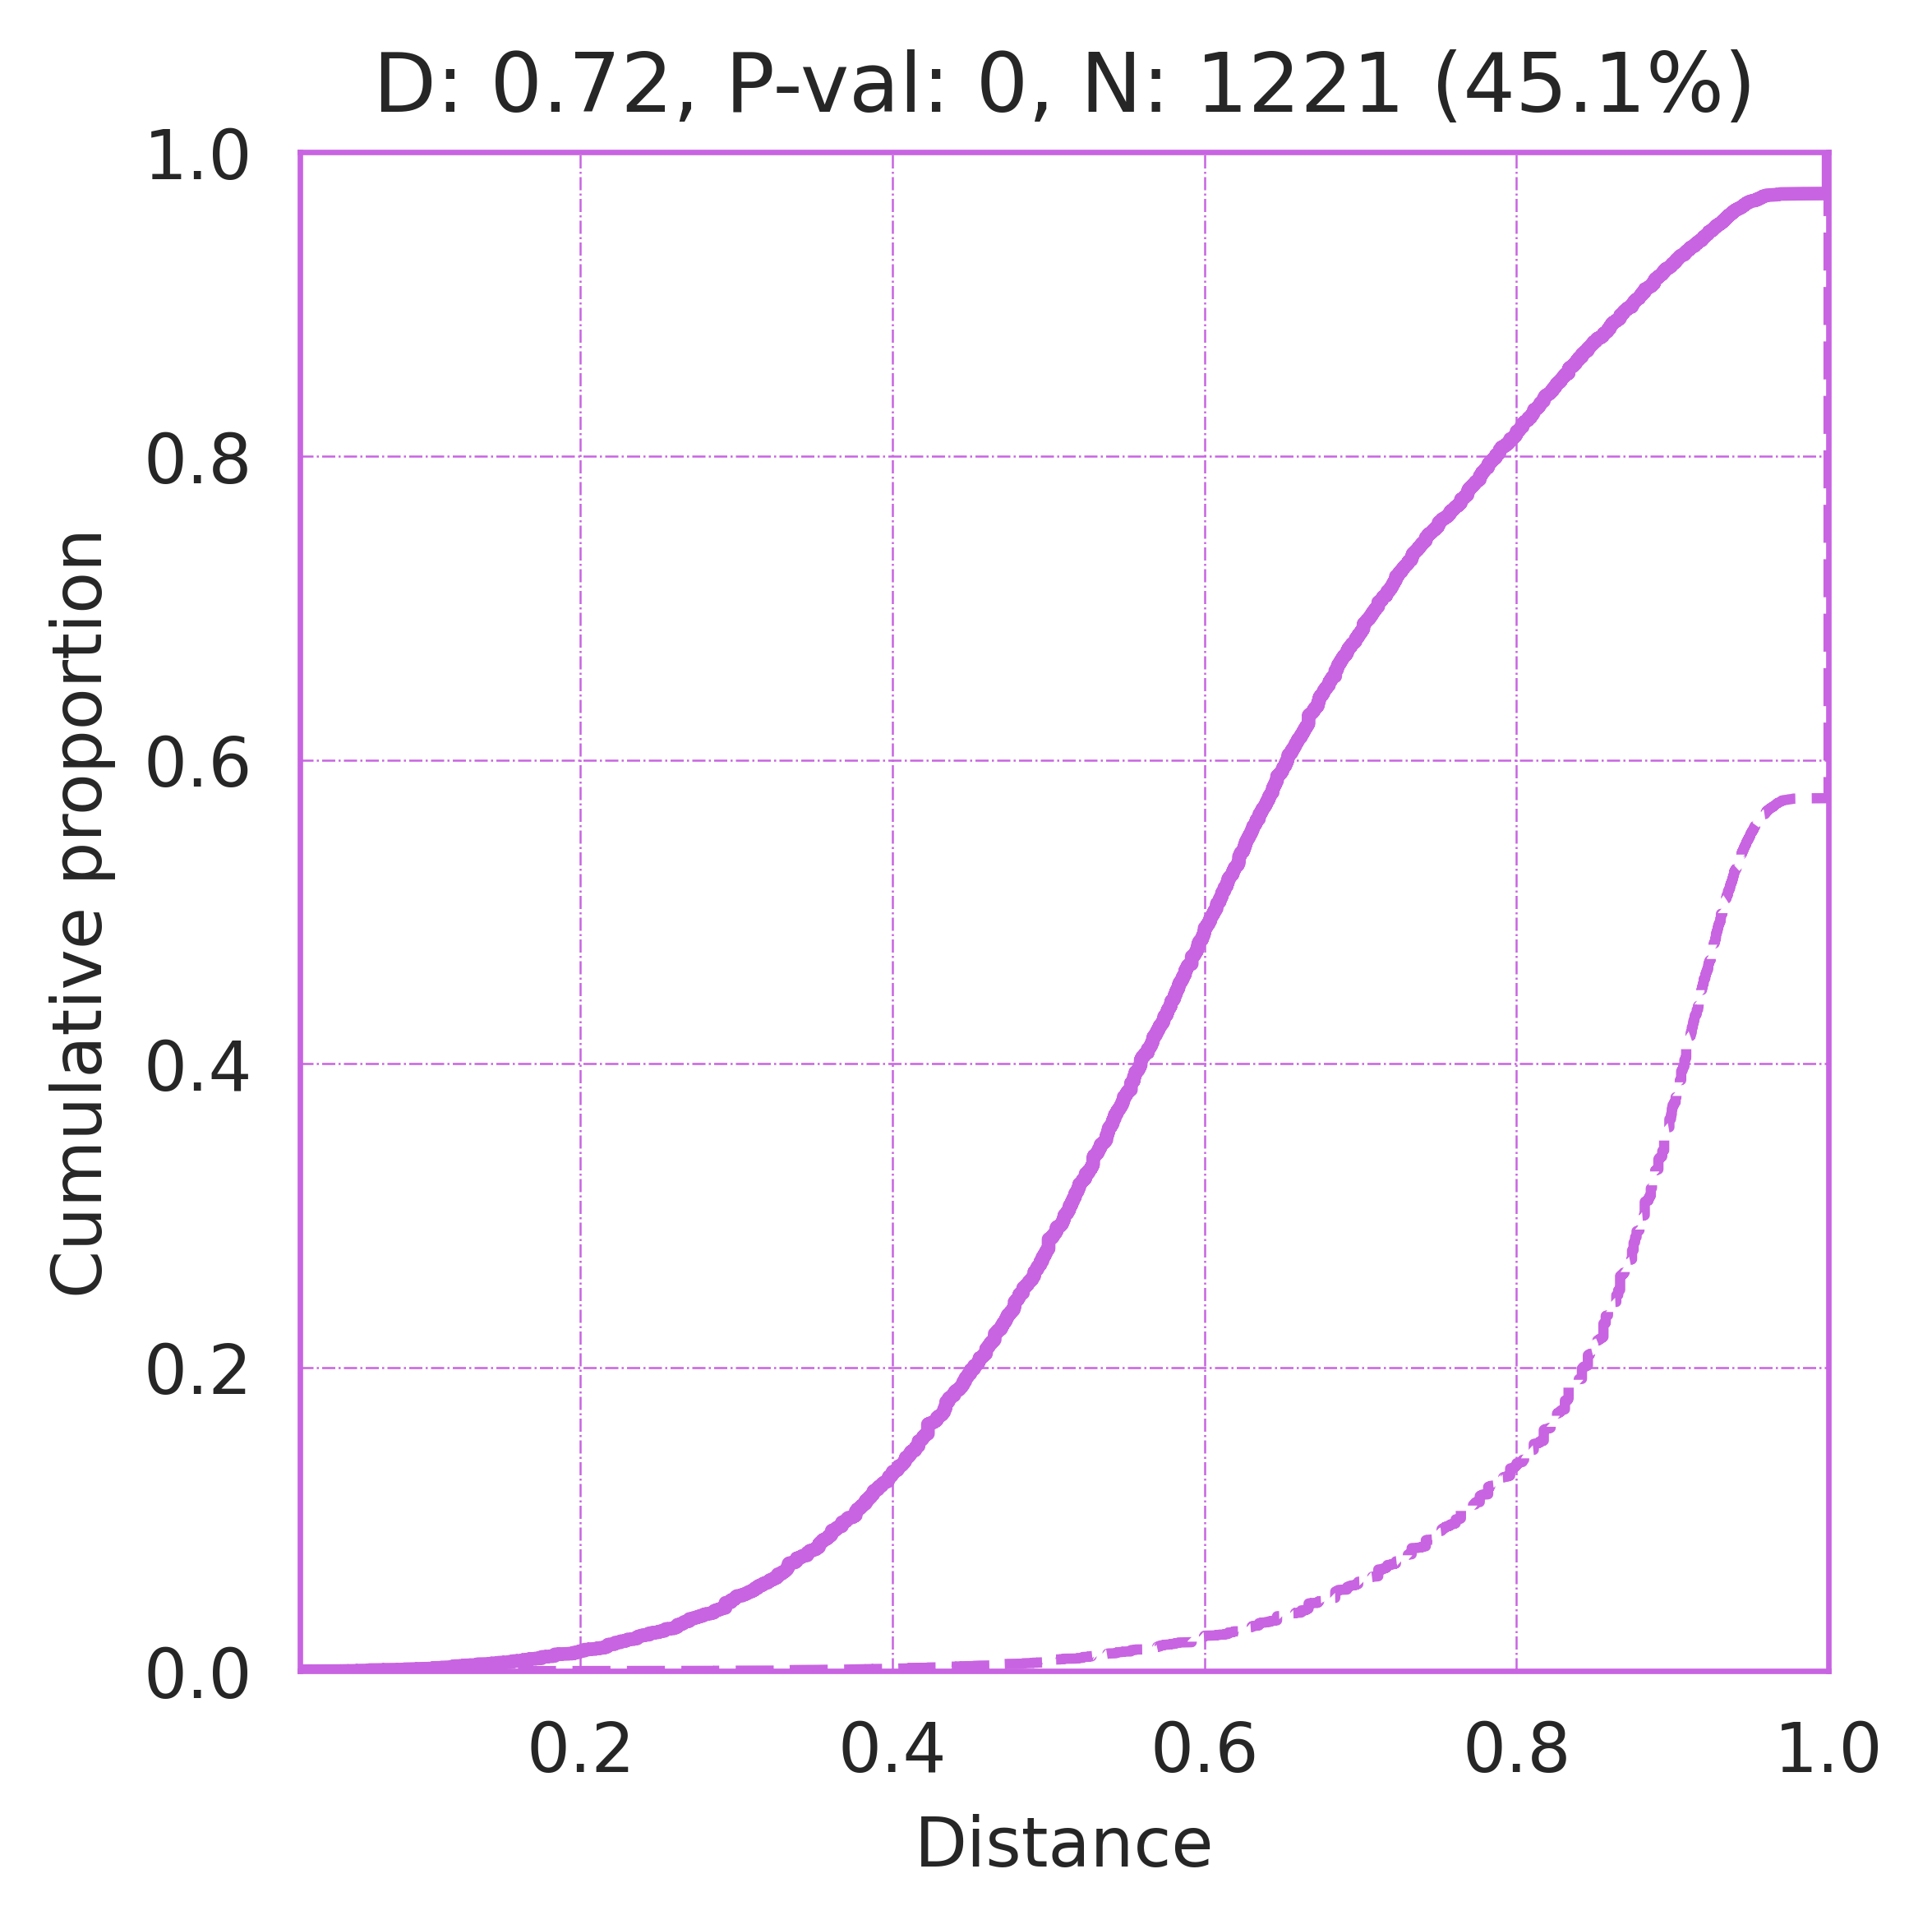

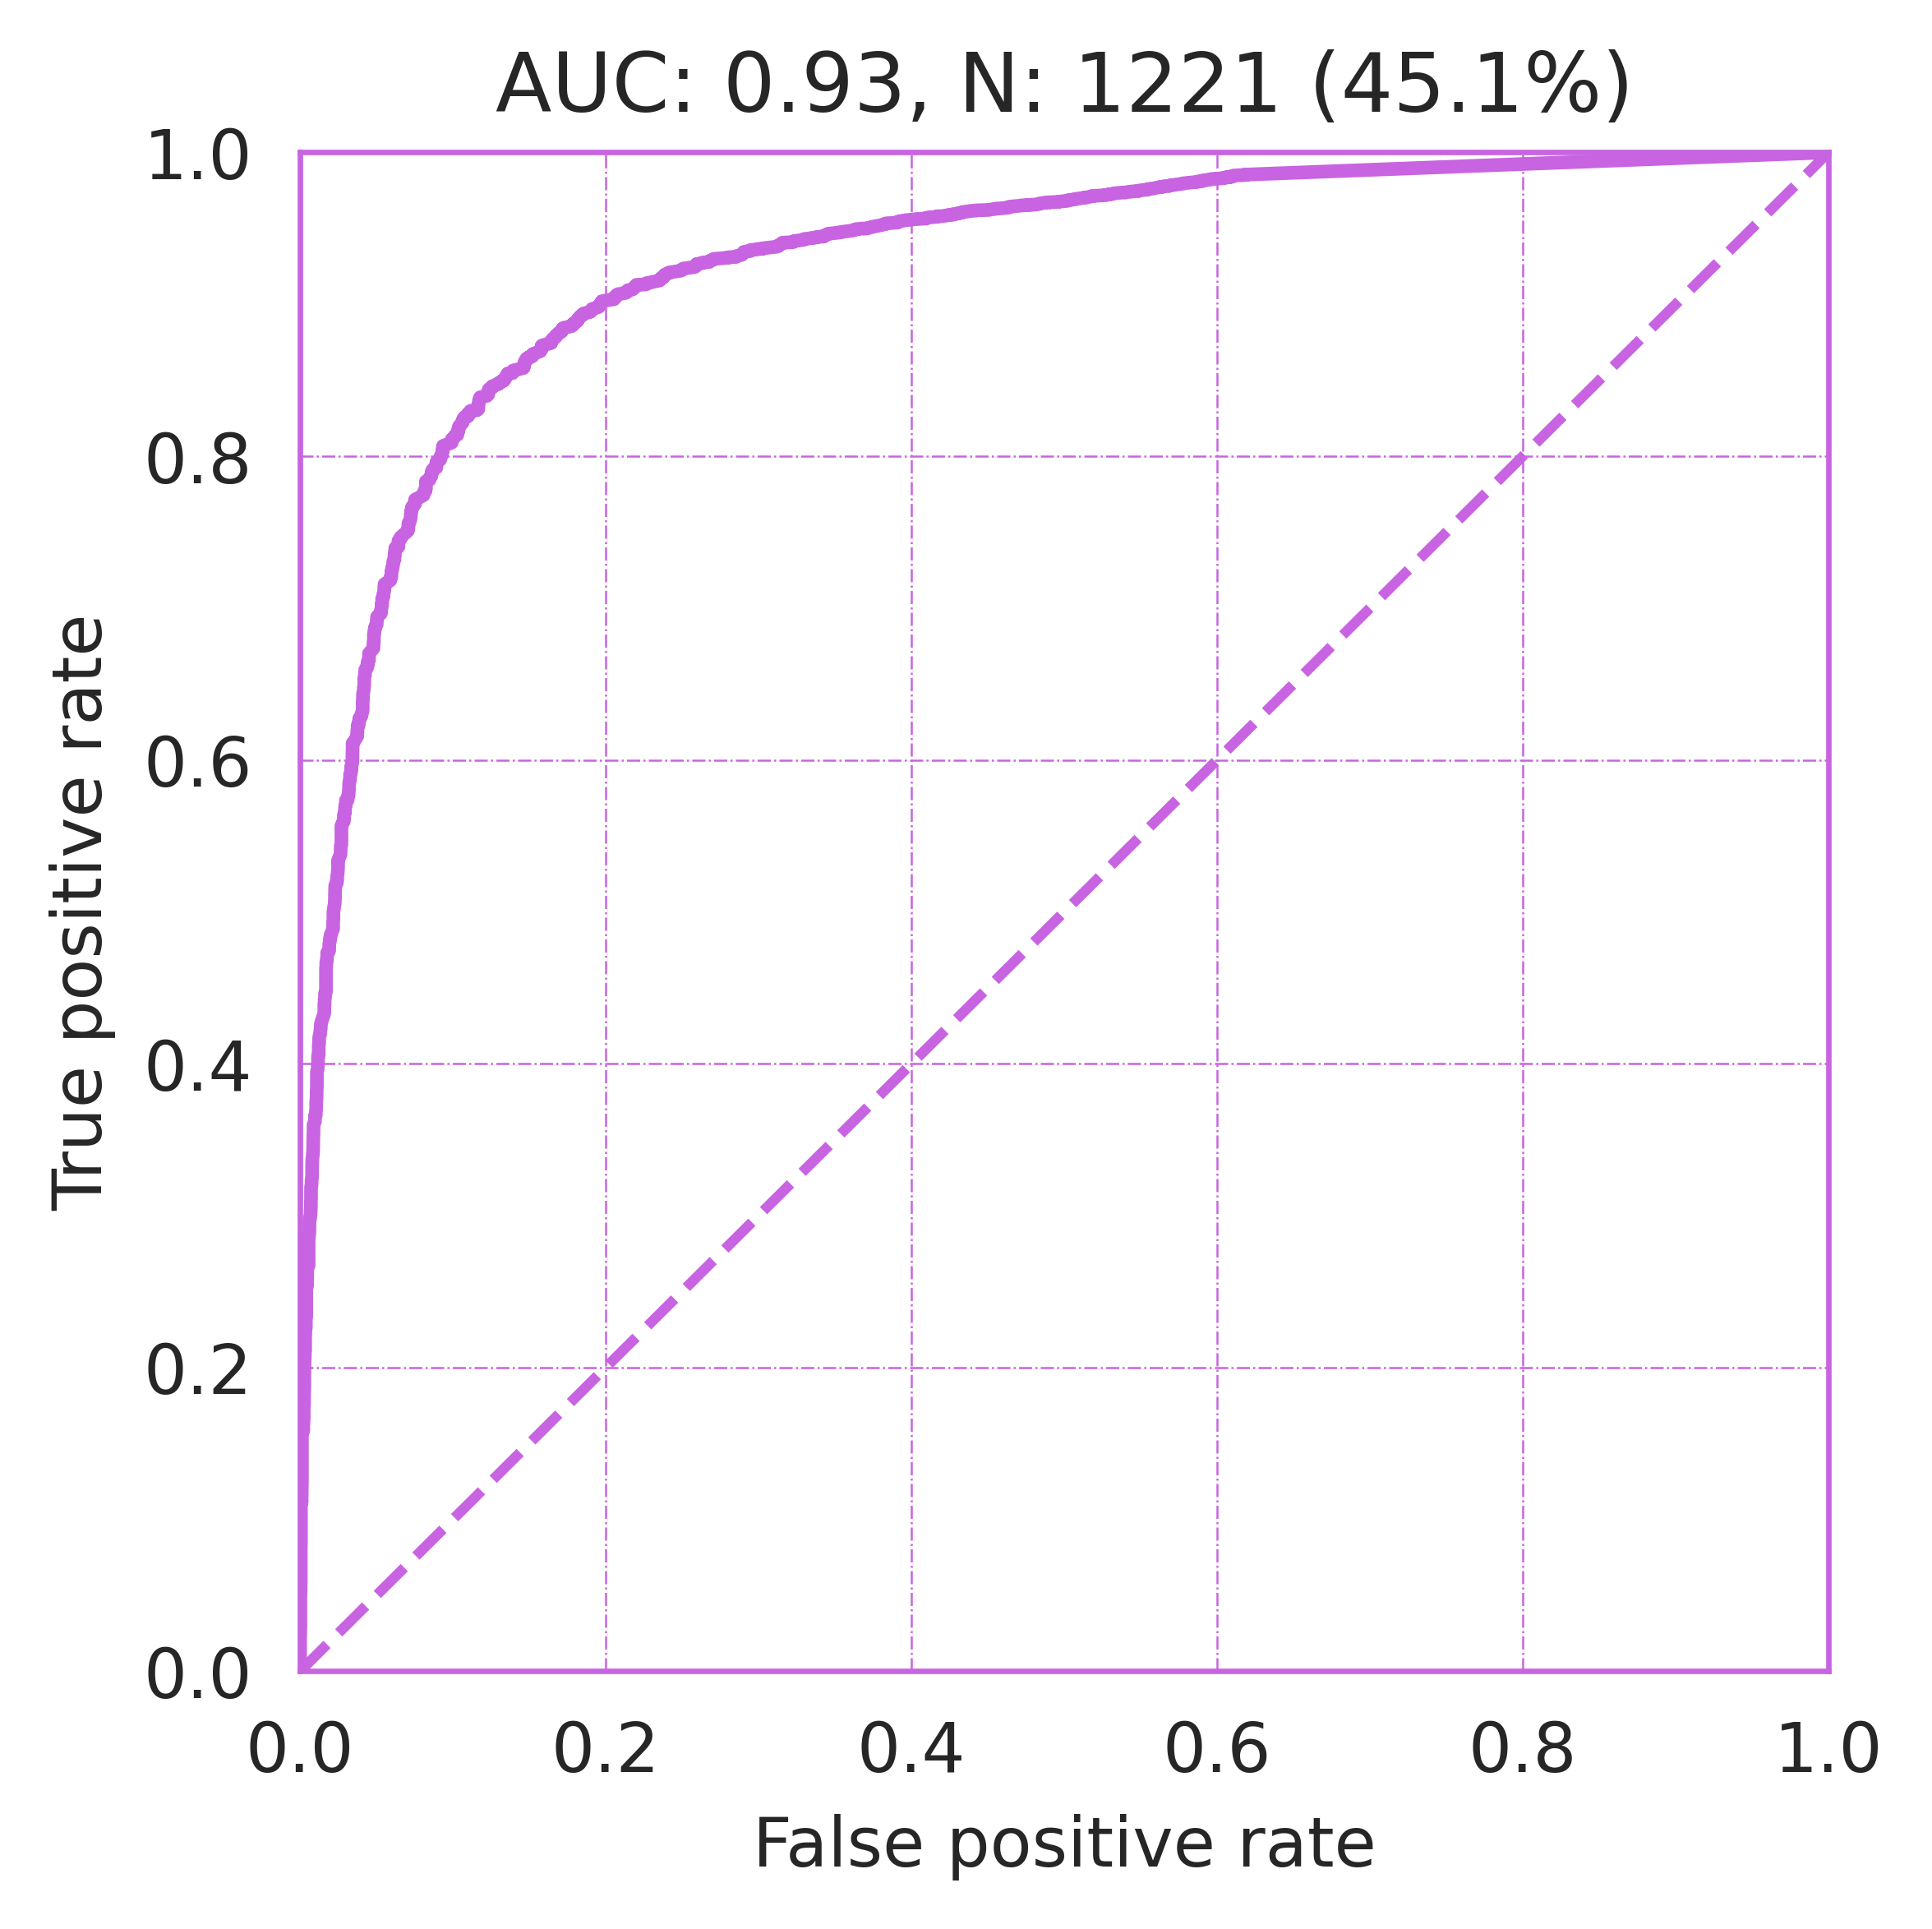

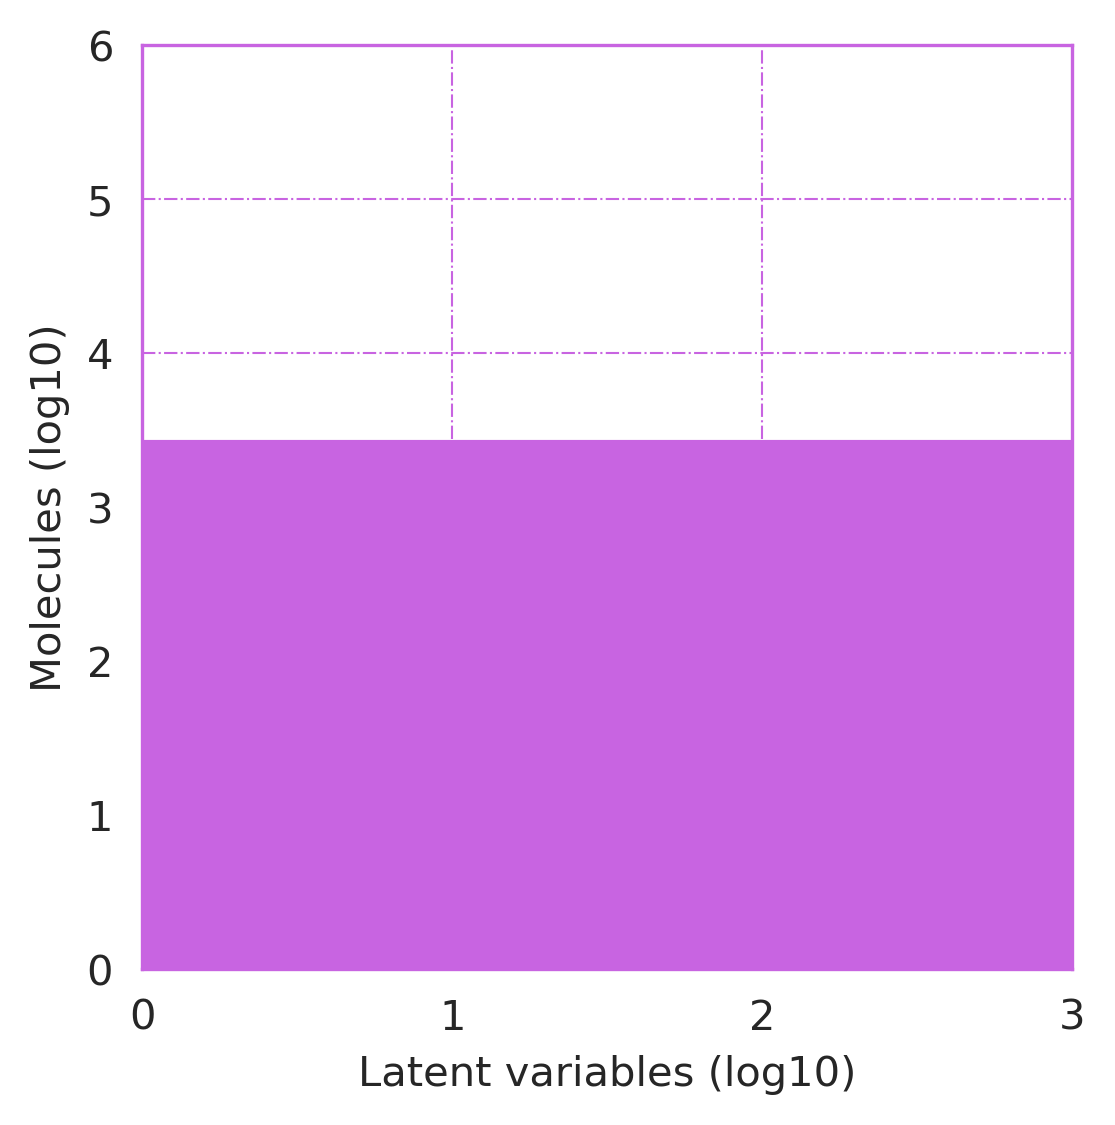

In [5]:
# Dataset Name
dataset = 'B1.002'

# Instantiation of sign0 data structures for the new space: full and reference
sign0 = cc_local.signature(dataset, 'sign0')

# Cleaning both full and reference datasets. This is crucial!
sign0.clear_all()

# Fit sign0
sign0.fit(pairs=np.array(merged_pairs))

In [6]:
sign0.shape

(6283, 1314)

2024-10-24 16:42:57,626 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/full/B/B1/B1.002/sign0
2024-10-24 16:42:57,638 chemicalchecker.core.chemcheck.ChemicalChecker [DEBUG   ] ChemicalChecker with root: /aloy/home/acomajuncosa/Protocols/local_CC_B1
2024-10-24 16:42:59,172 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Computing or retrieving data for canvas small.
2024-10-24 16:42:59,174 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Skipping the following plots: []
2024-10-24 16:42:59,177 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Cosine distances
2024-10-24 16:42:59,182 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Subsampling signature
2024-10-24 16:42:59,379 chemicalchecker.core.signature_data.DataSignature [DEBUG   ] Full dataset sampled (n=6283)
2024-10-24 16:42:59,381 chemicalchecker.core.signature_data.DataSignature [DEBUG   ] Fetching dataset V
2024-10-24 16:43:05,50

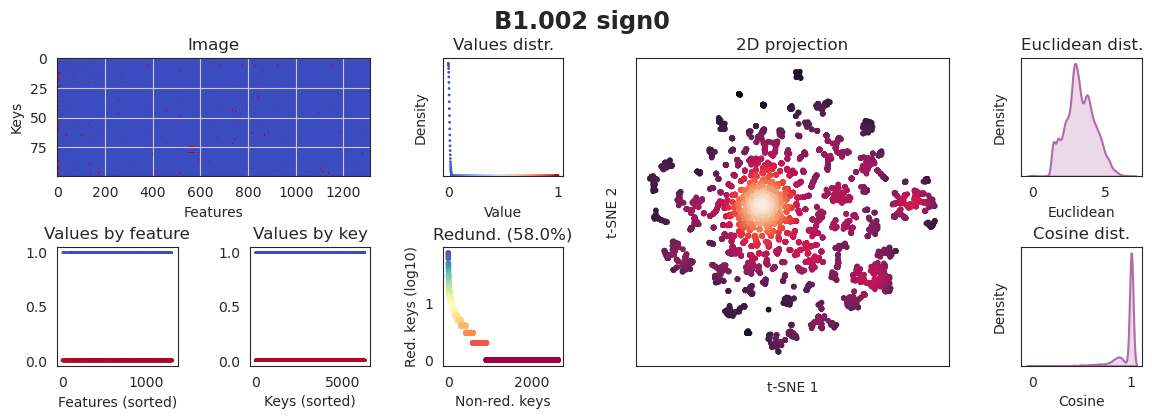

In [7]:
# Instantiation of sign0
sign0 = cc_local.signature(dataset, 'sign0')

# Instantiation of diag0 (diagnosis plots)
diag0 = sign0.diagnosis()

# Plot small diagnosis plots
diag0.canvas(size='small', savefig=True, savefig_kwargs={'dpi': 300})

In [8]:
np.min(np.array(sign0).flatten()), np.max(np.array(sign0).flatten())

(0.0, 1.0)

## sign1 ##

2024-10-24 16:50:13,823 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/full/B/B1/B1.002/sign0
2024-10-24 16:50:13,826 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] New signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/full/B/B1/B1.002/sign1
2024-10-24 16:50:13,835 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] New signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/reference/B/B1/B1.002/sign1
2024-10-24 16:50:13,841 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Clearing signature /aloy/home/acomajuncosa/Protocols/local_CC_B1/reference/B/B1/B1.002/sign1
2024-10-24 16:50:13,853 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/full/B/B1/B1.002/sign1
2024-10-24 16:50:13,854 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Clearing signature /aloy/home/acomajuncosa/Proto

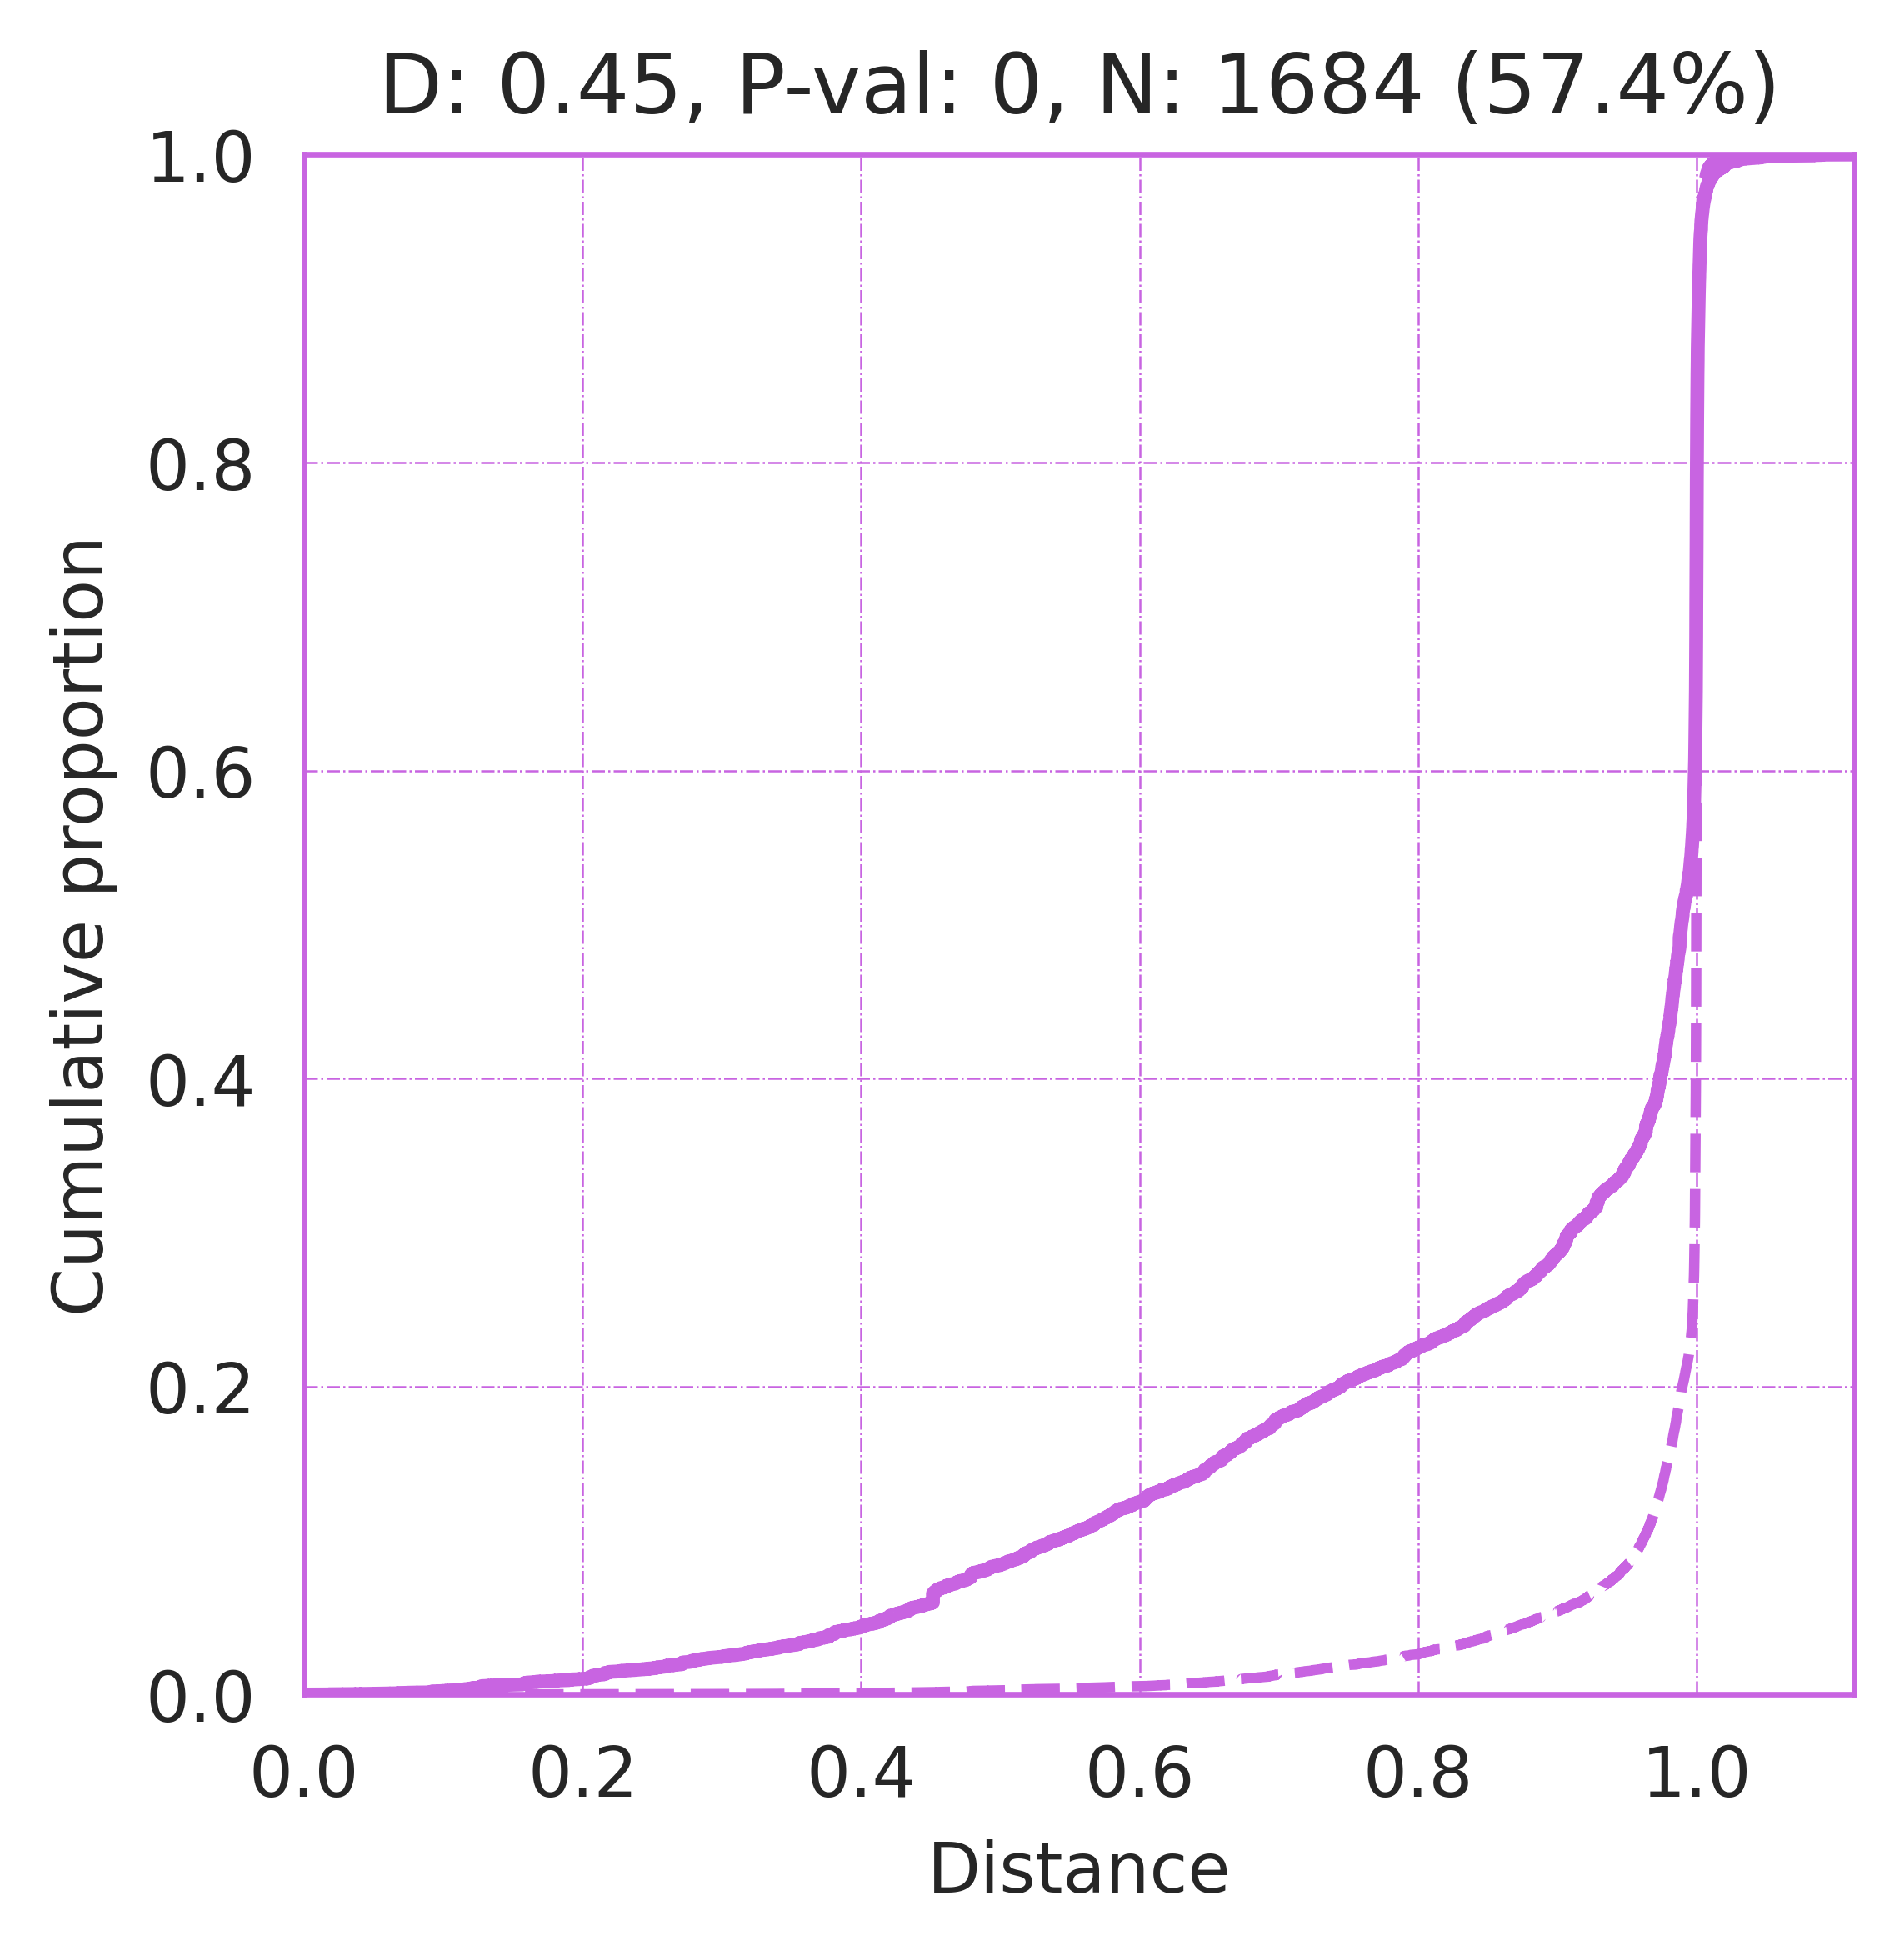

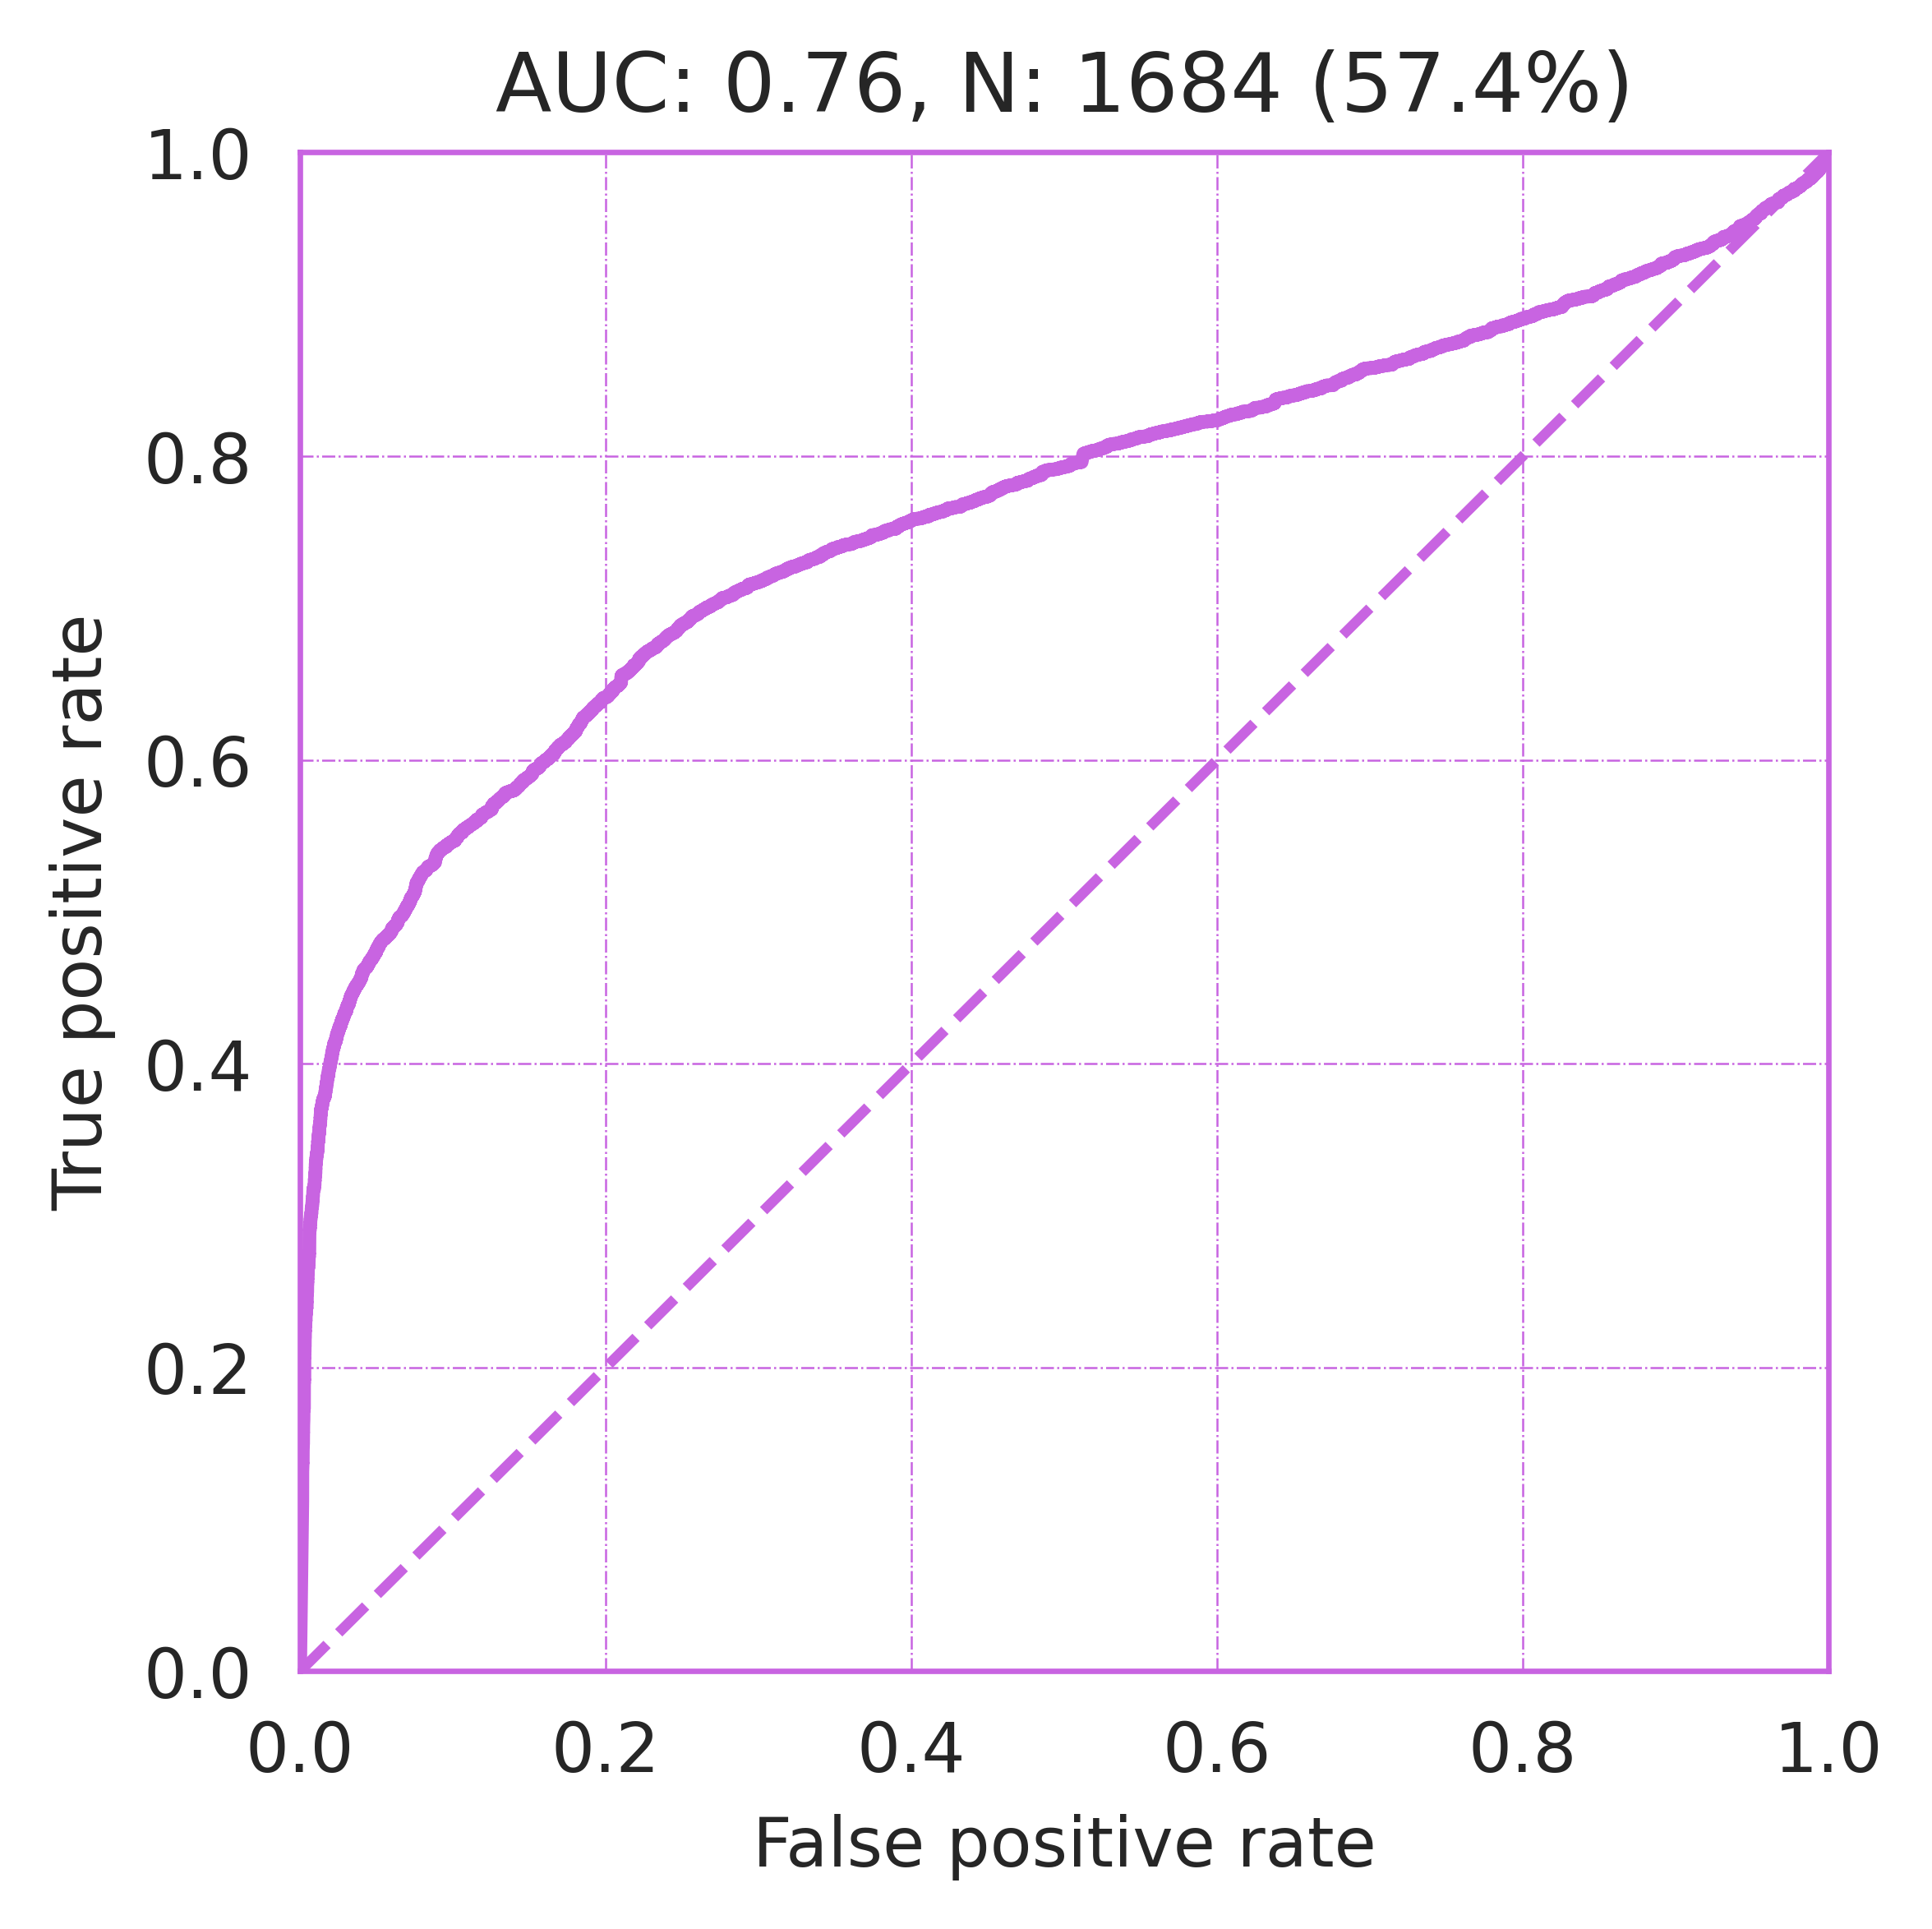

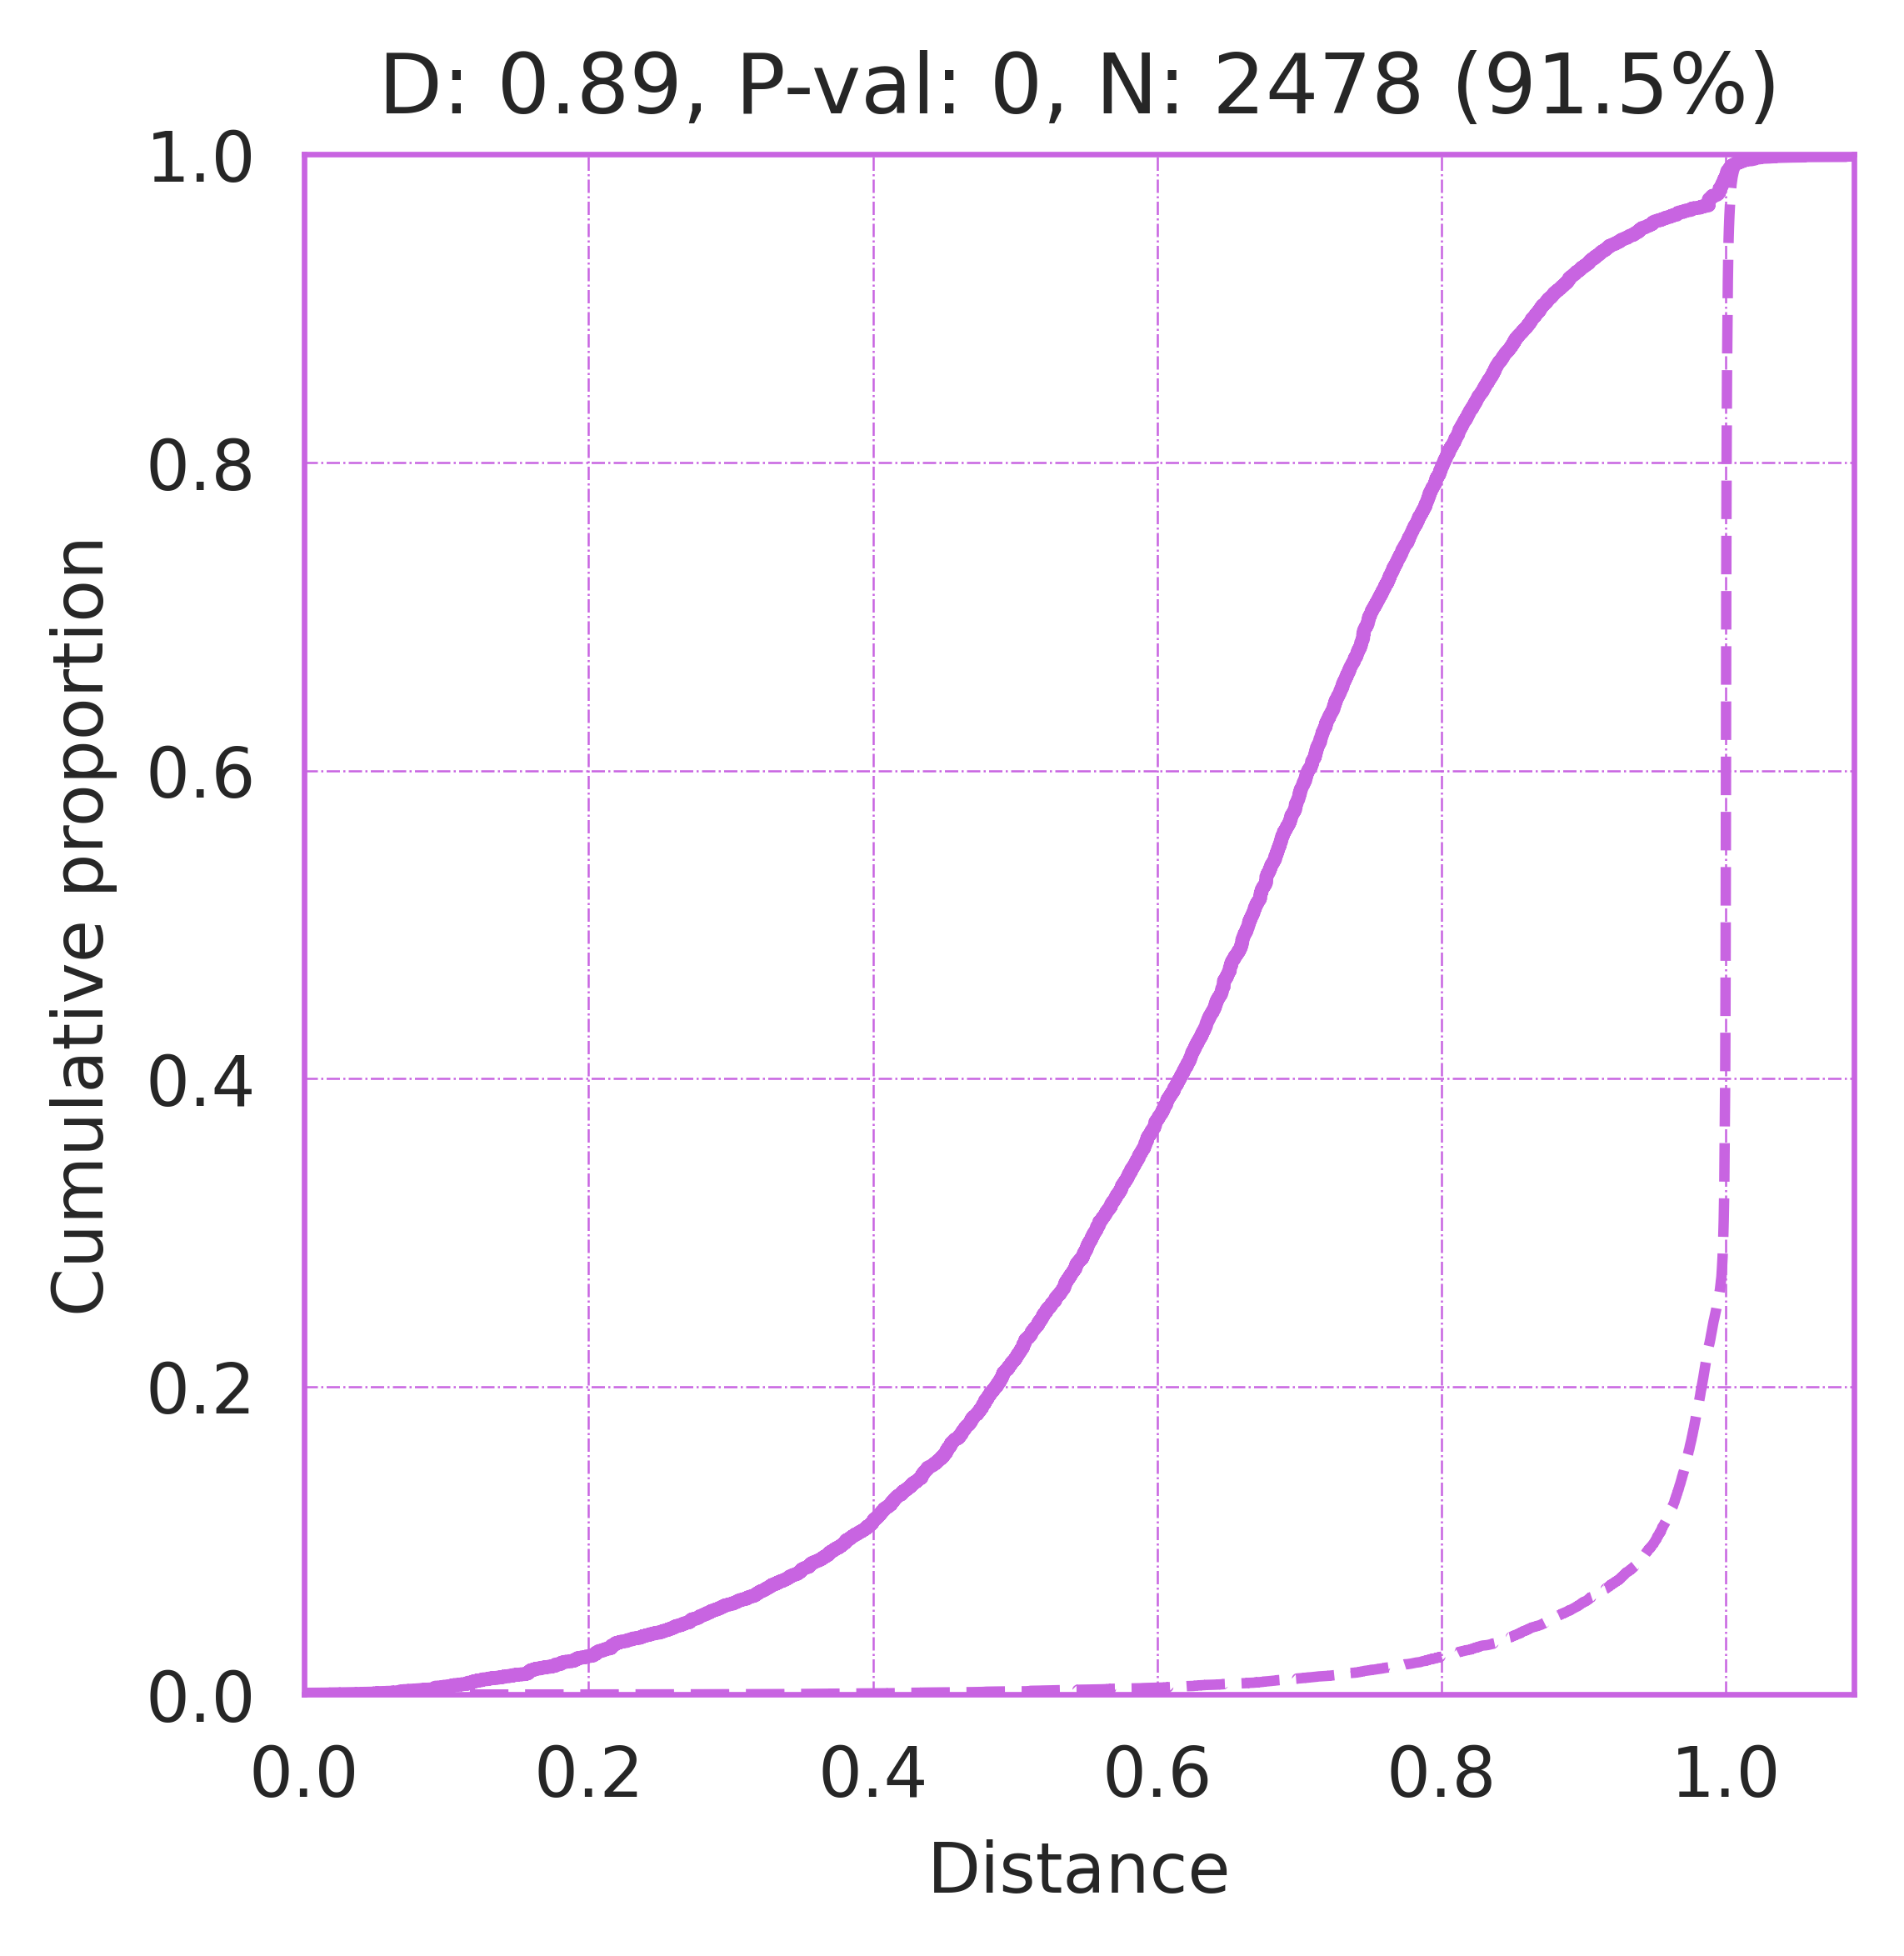

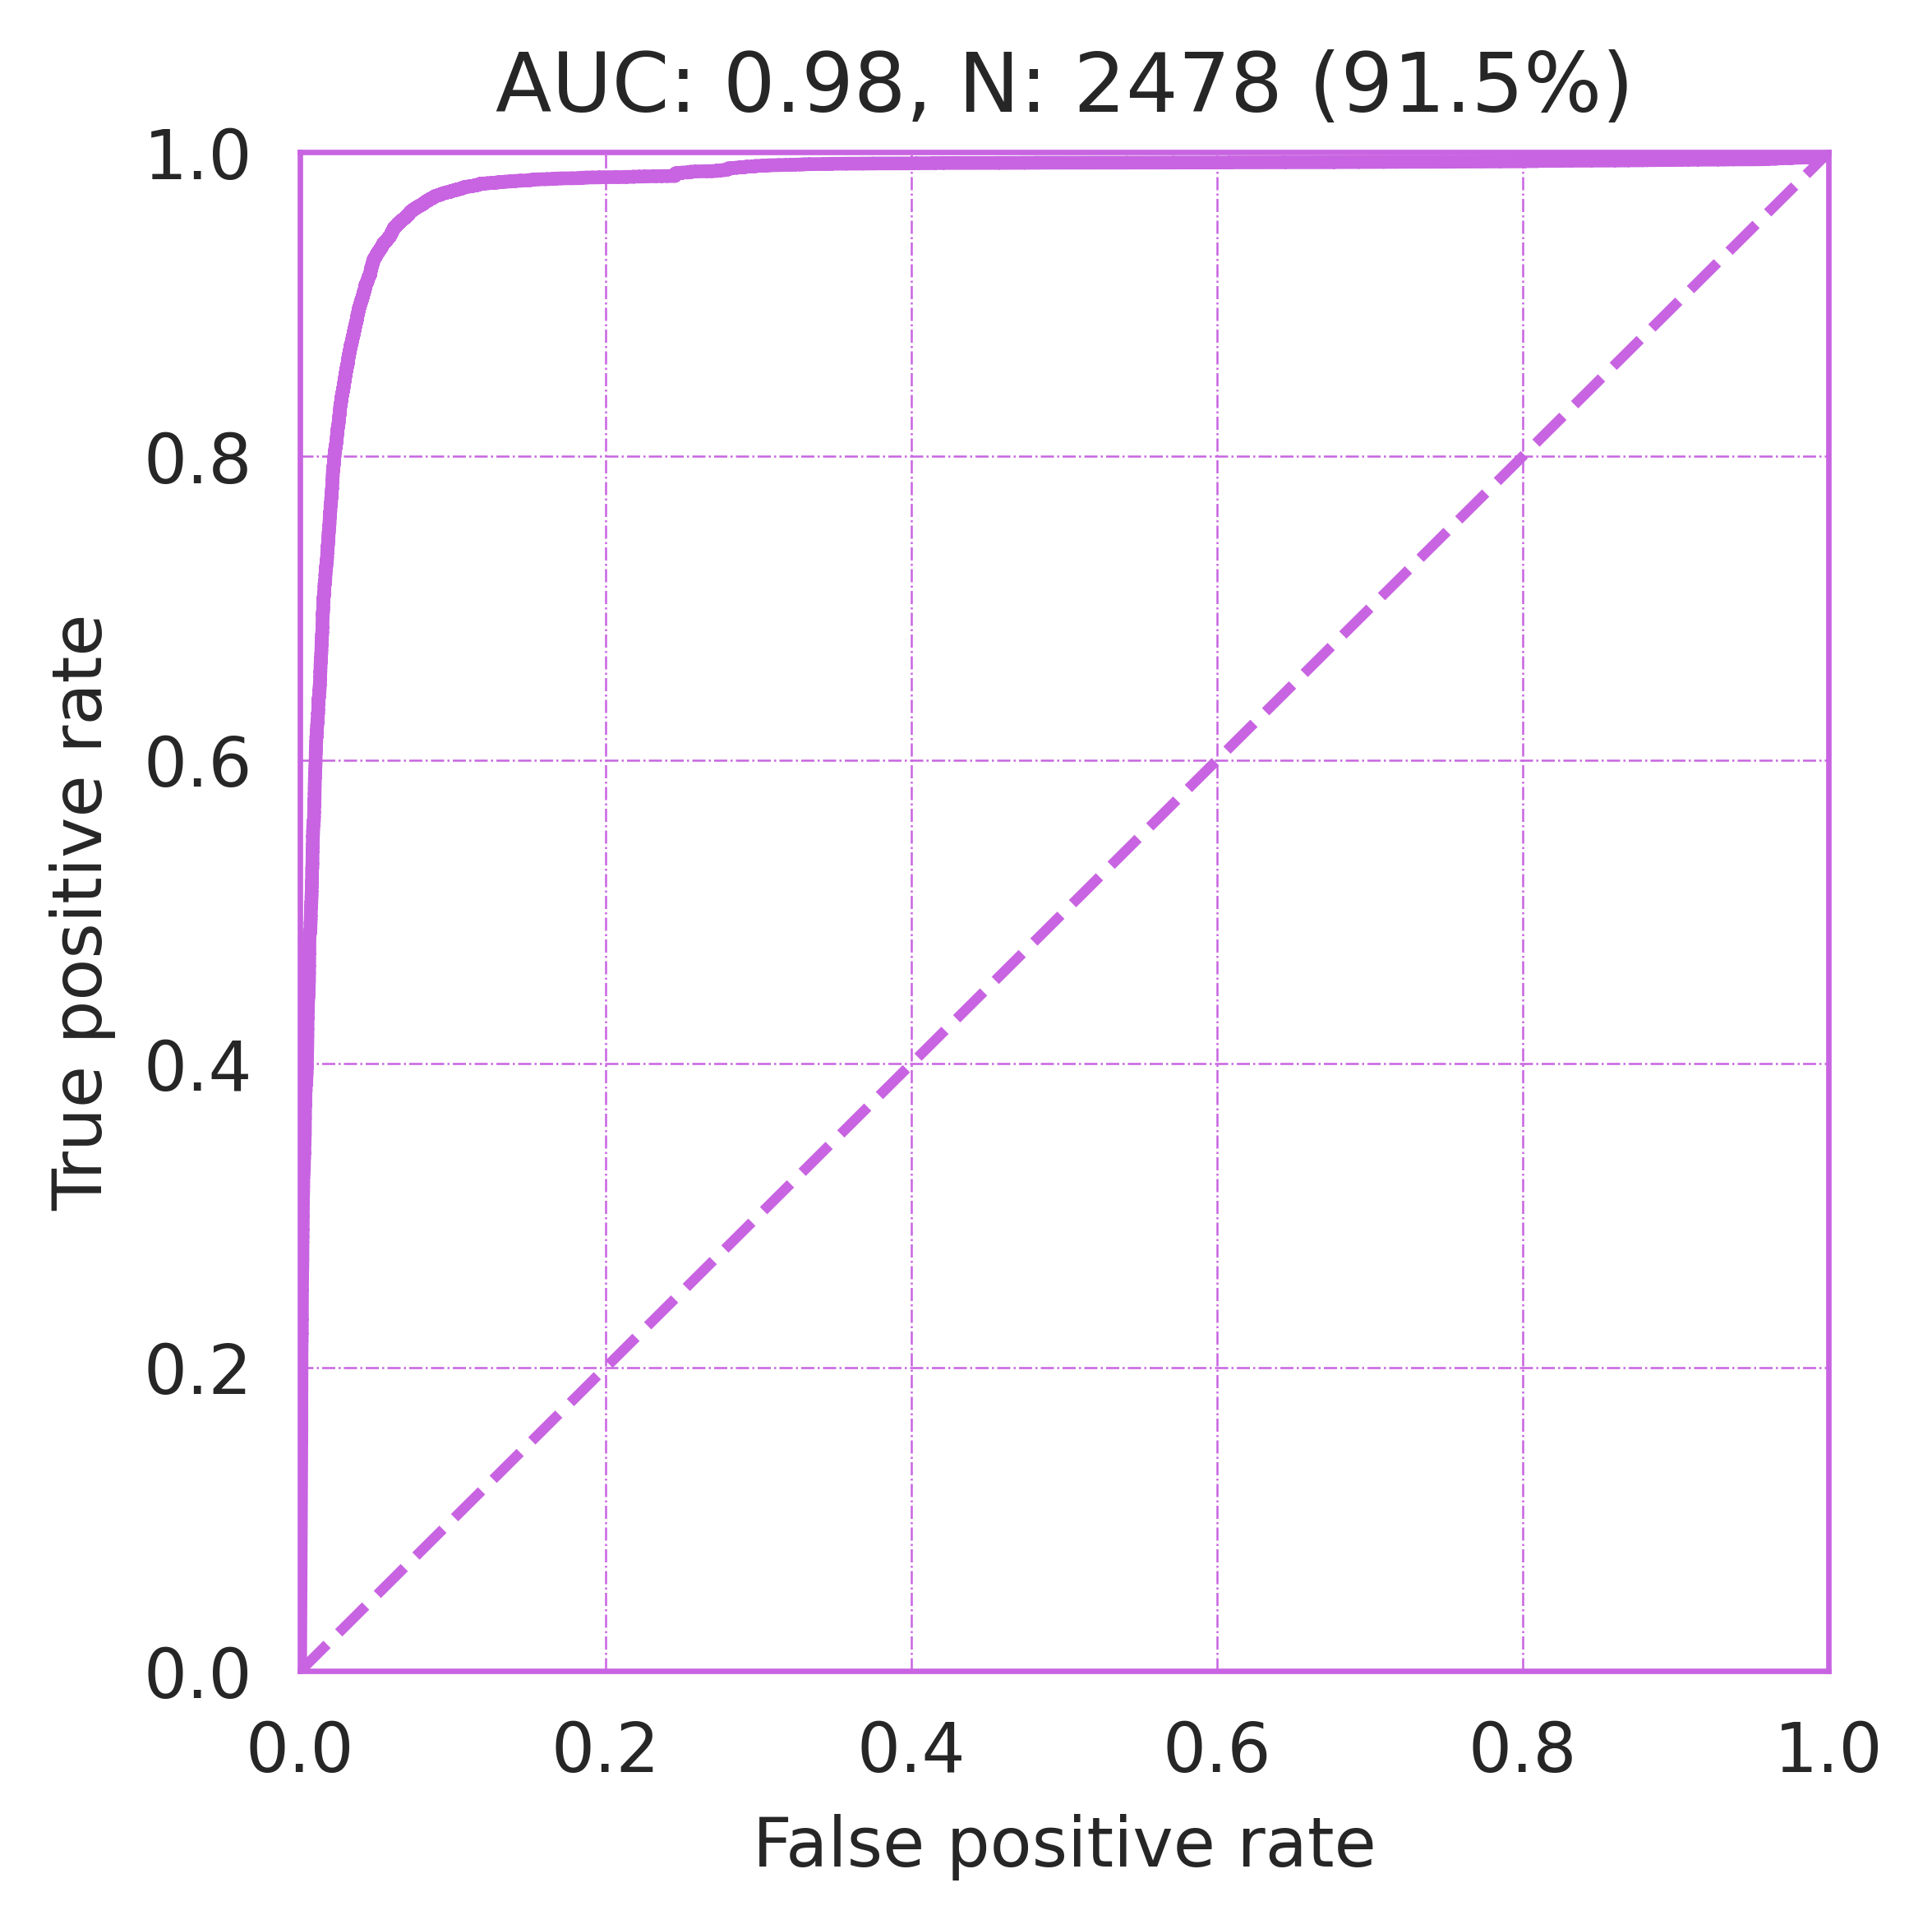

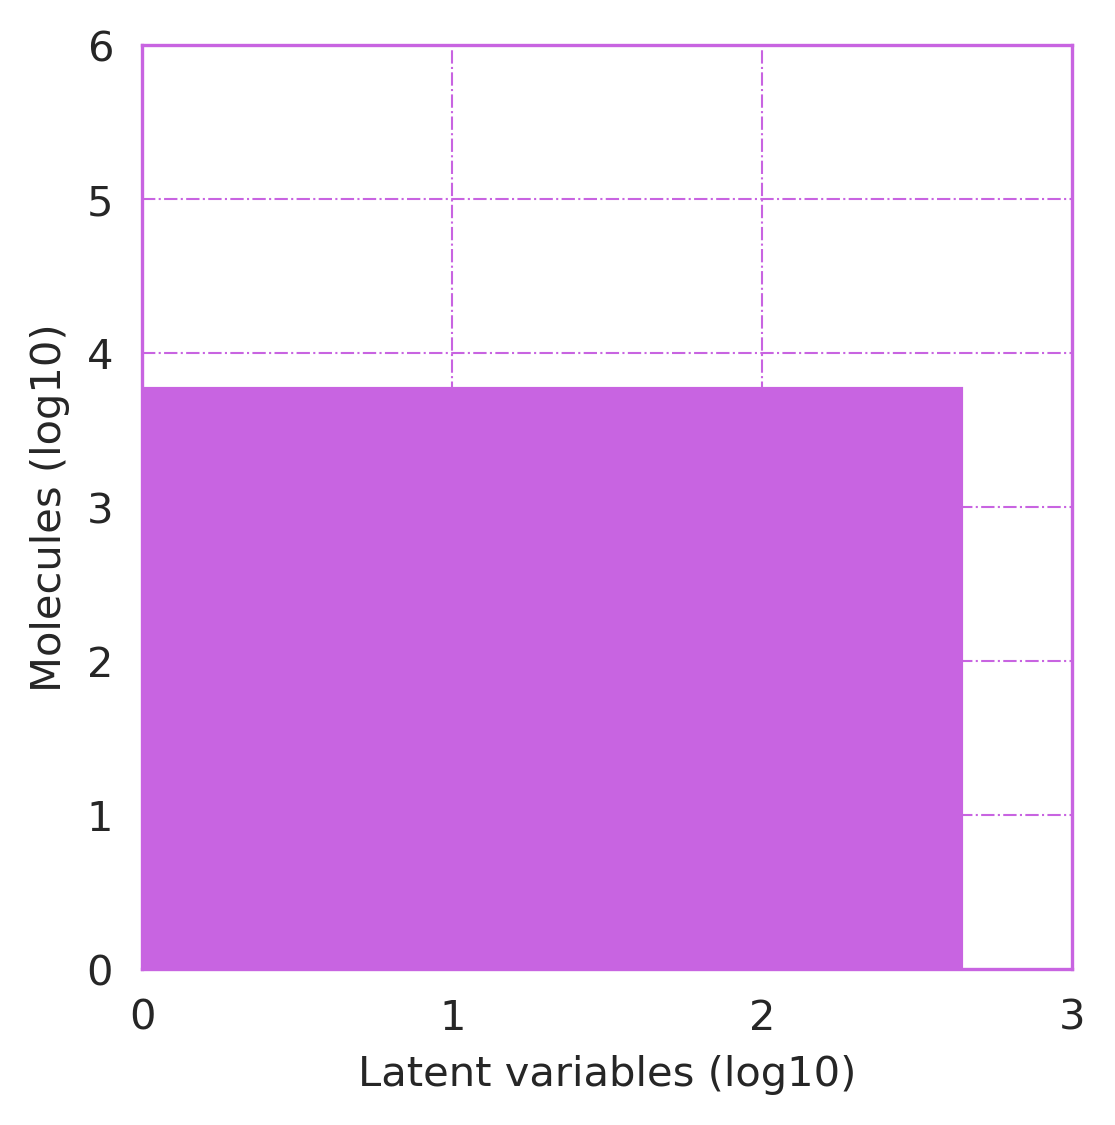

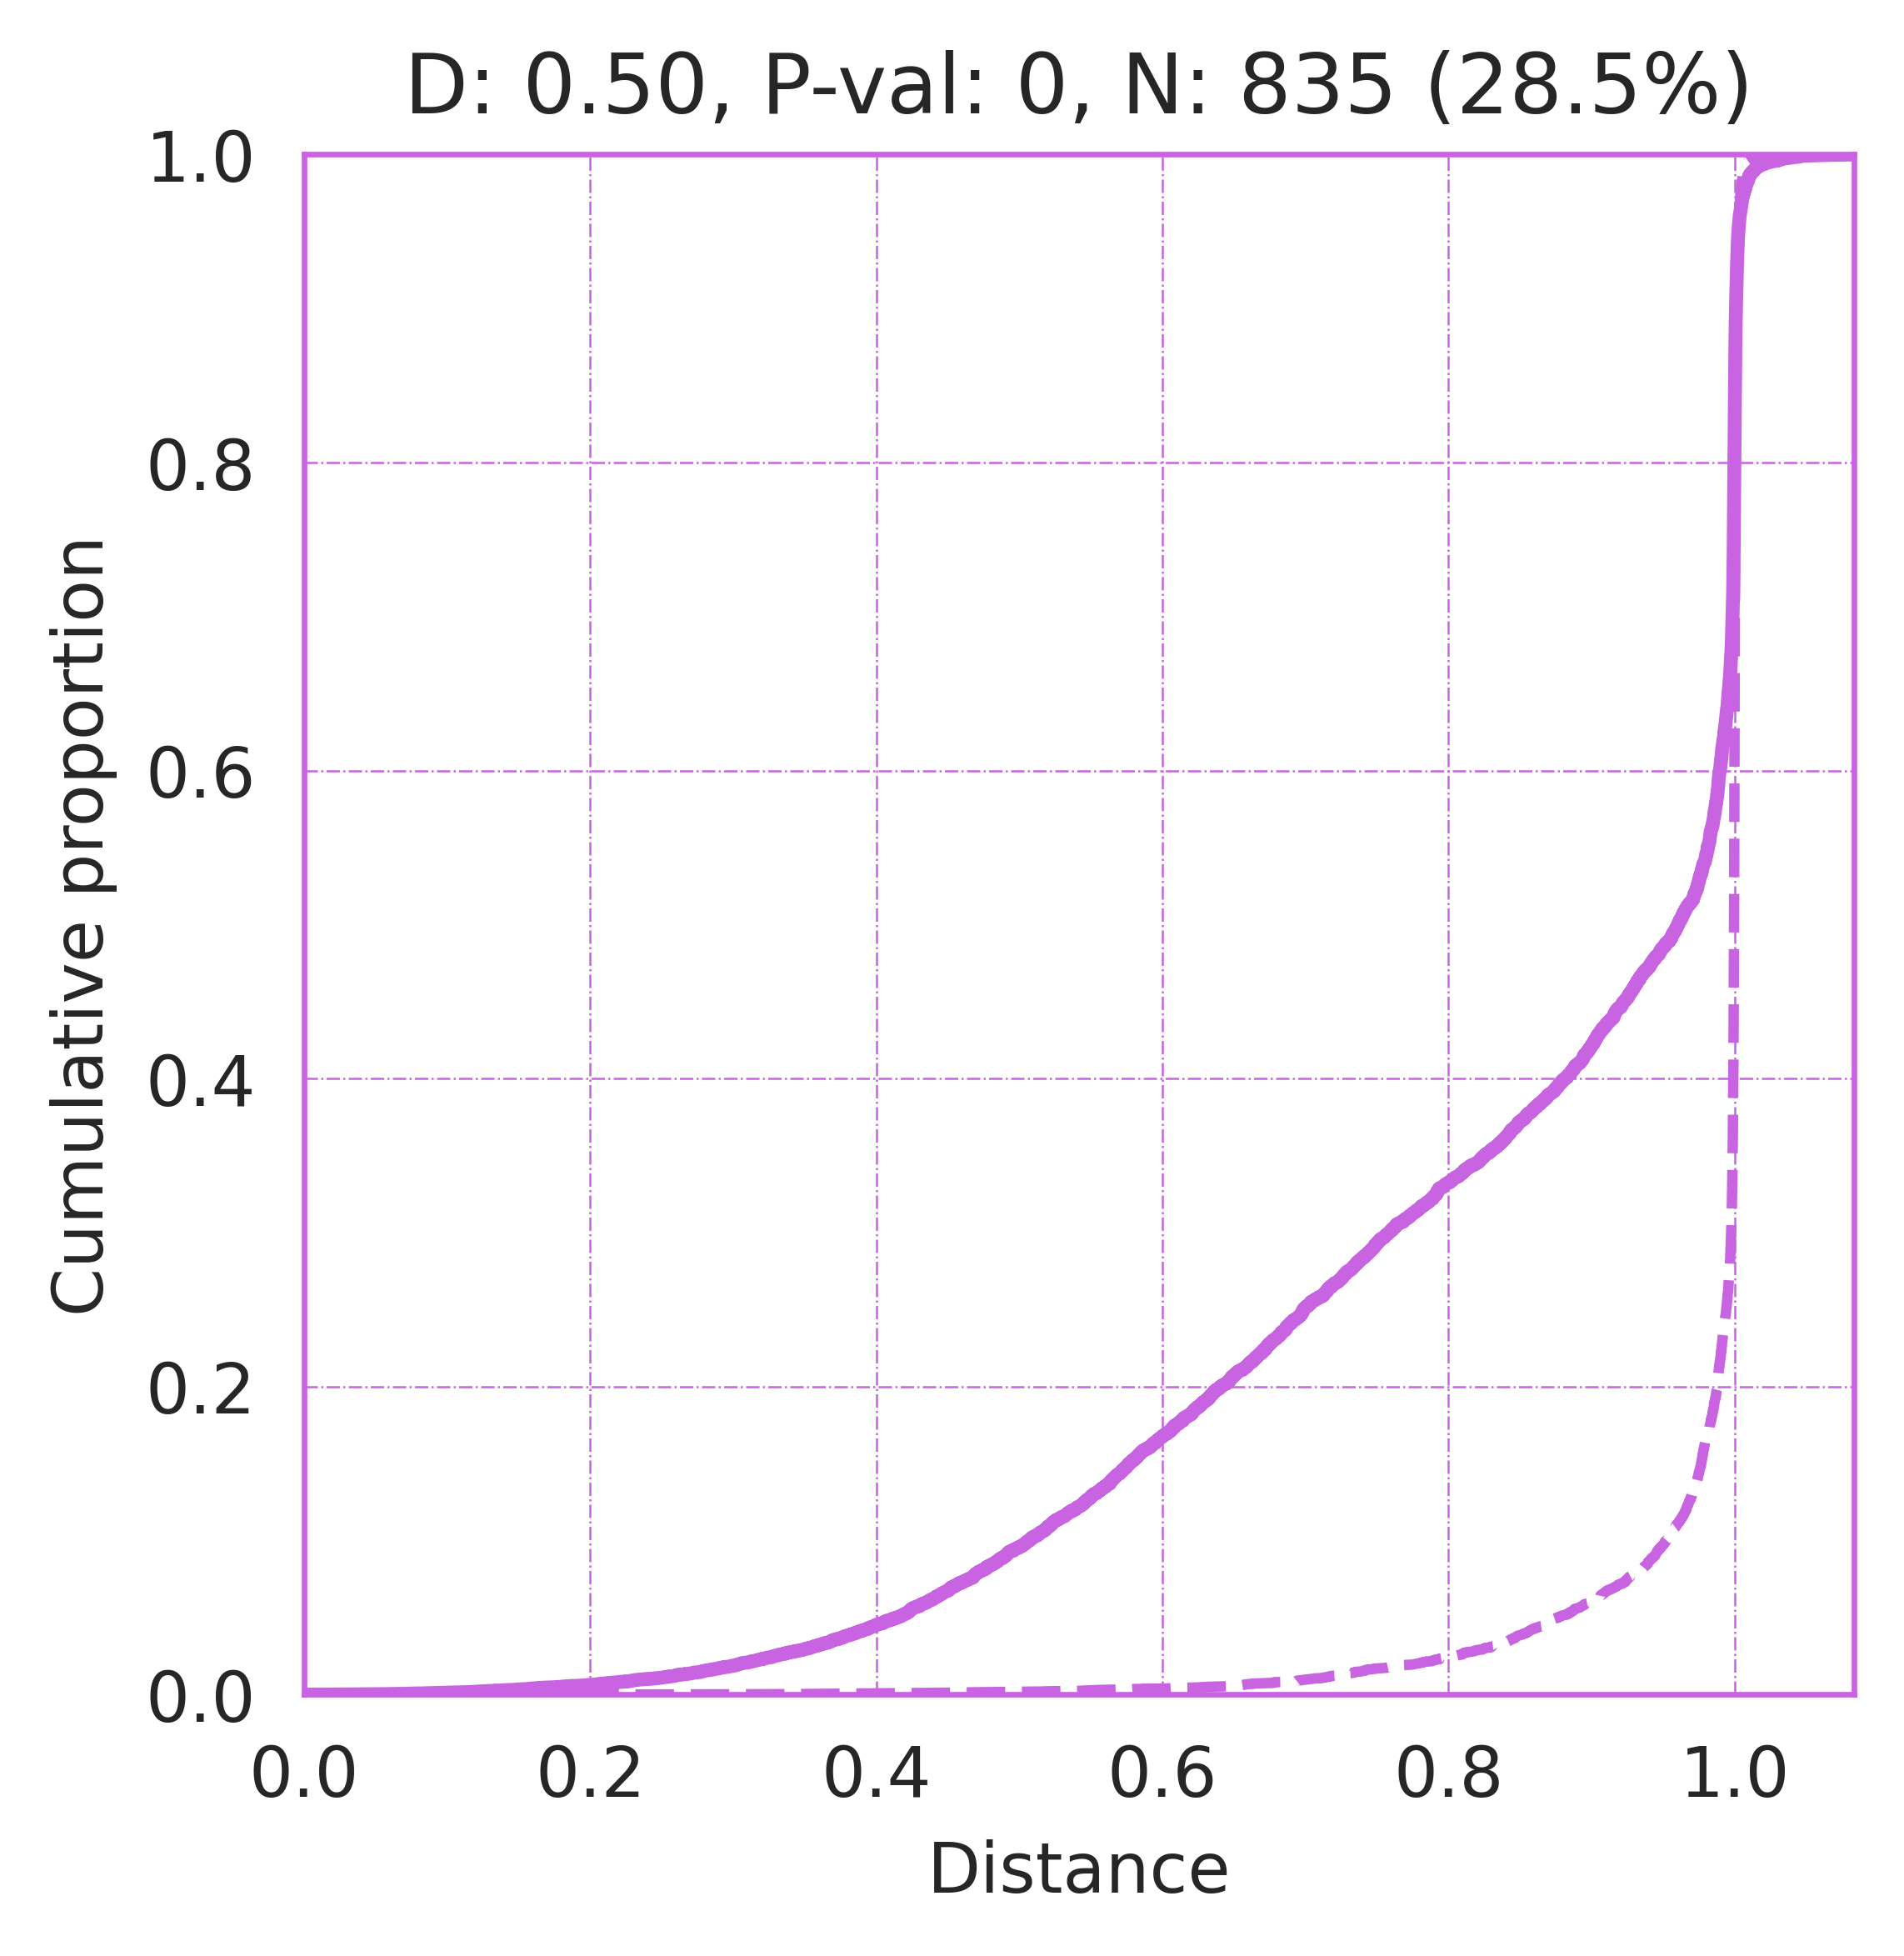

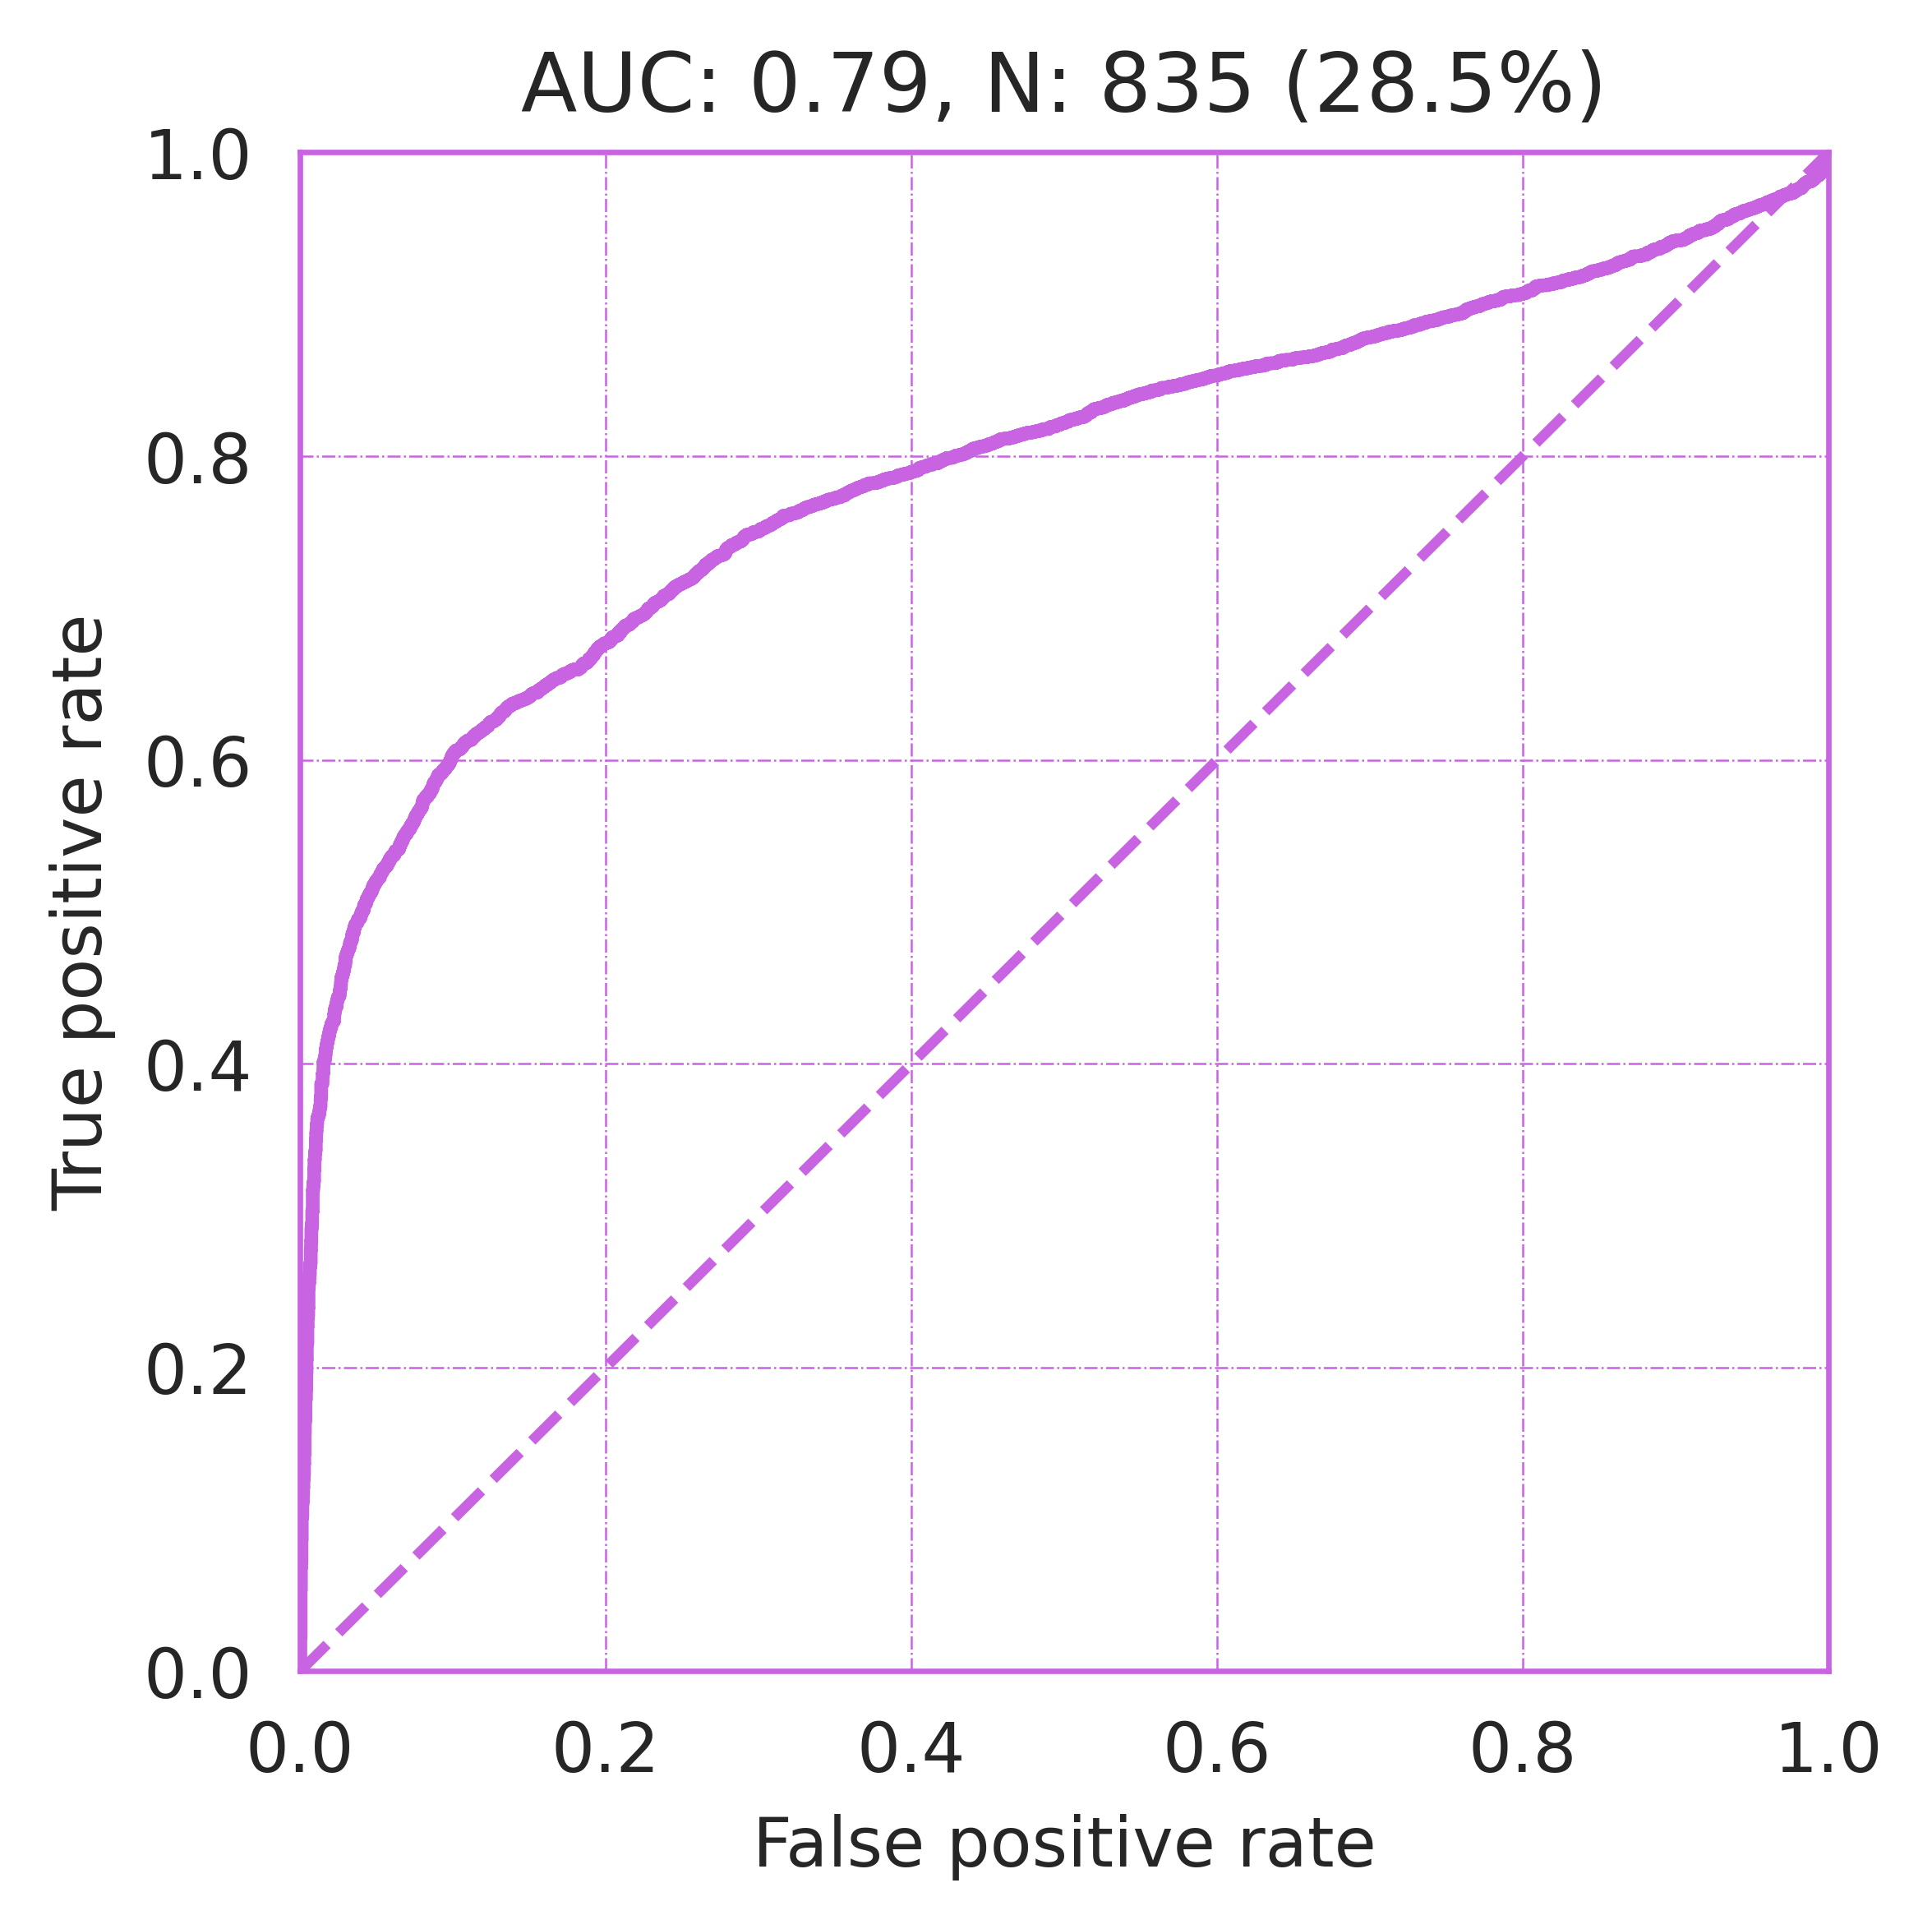

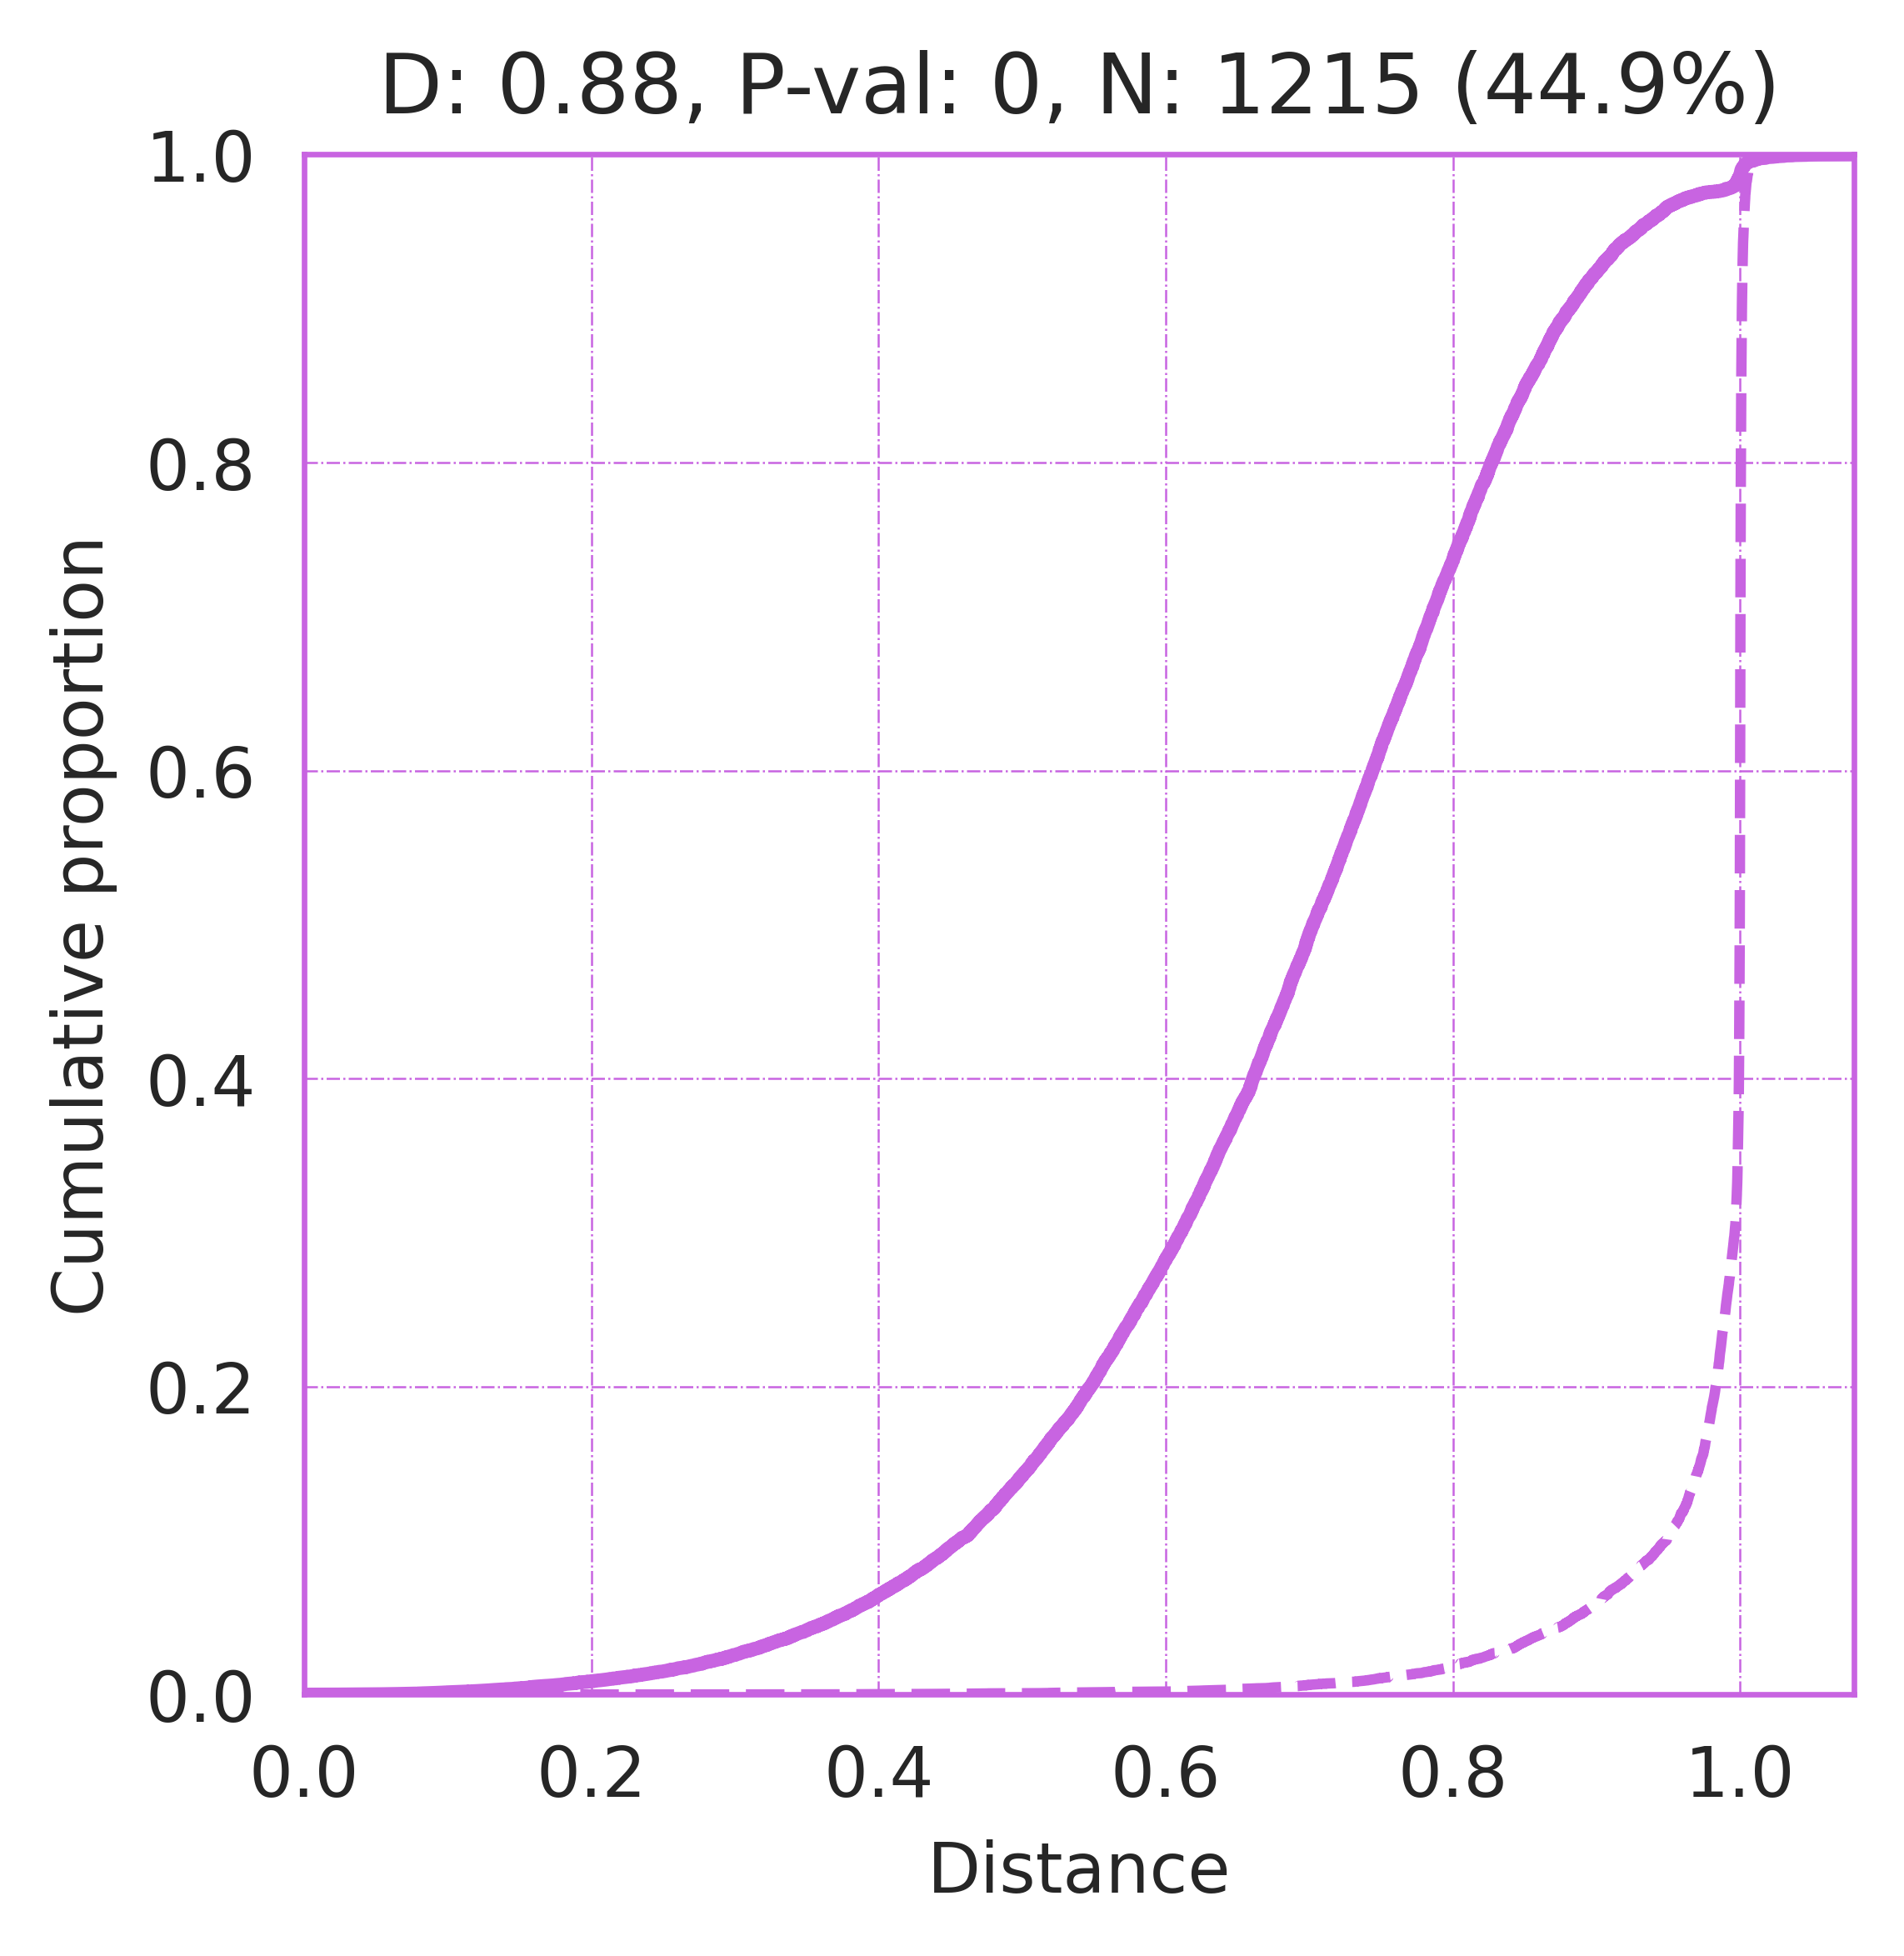

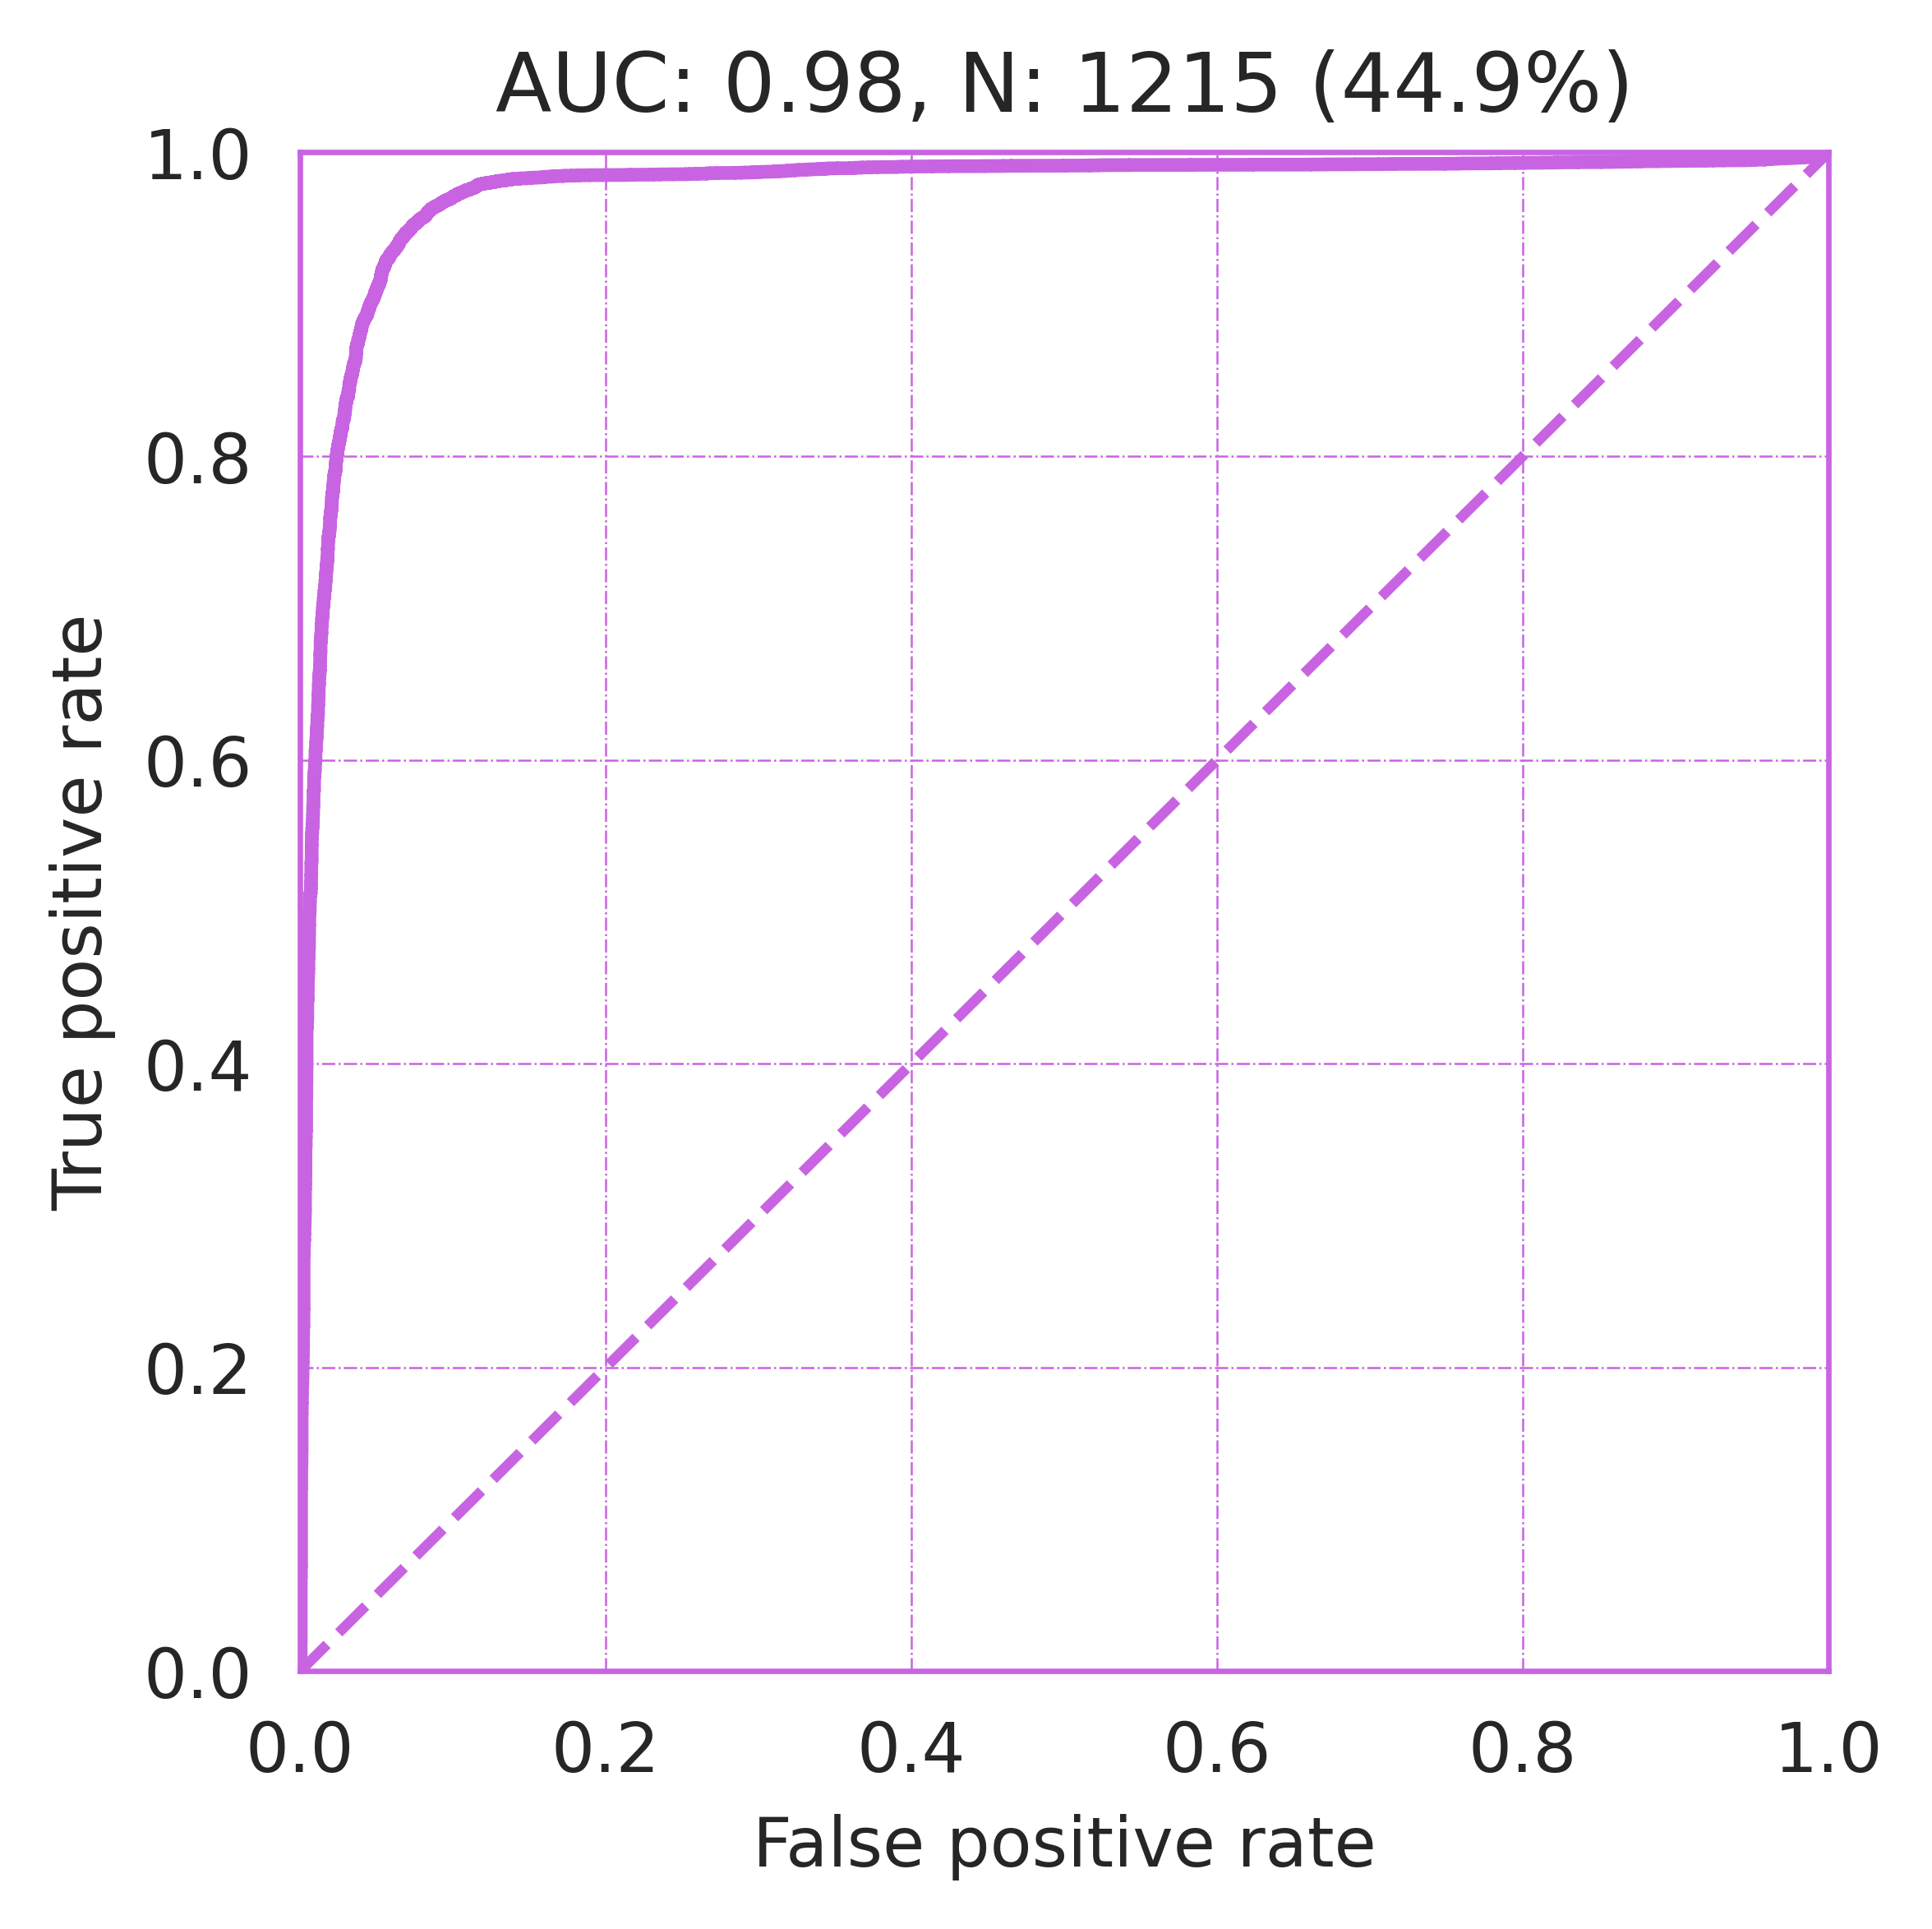

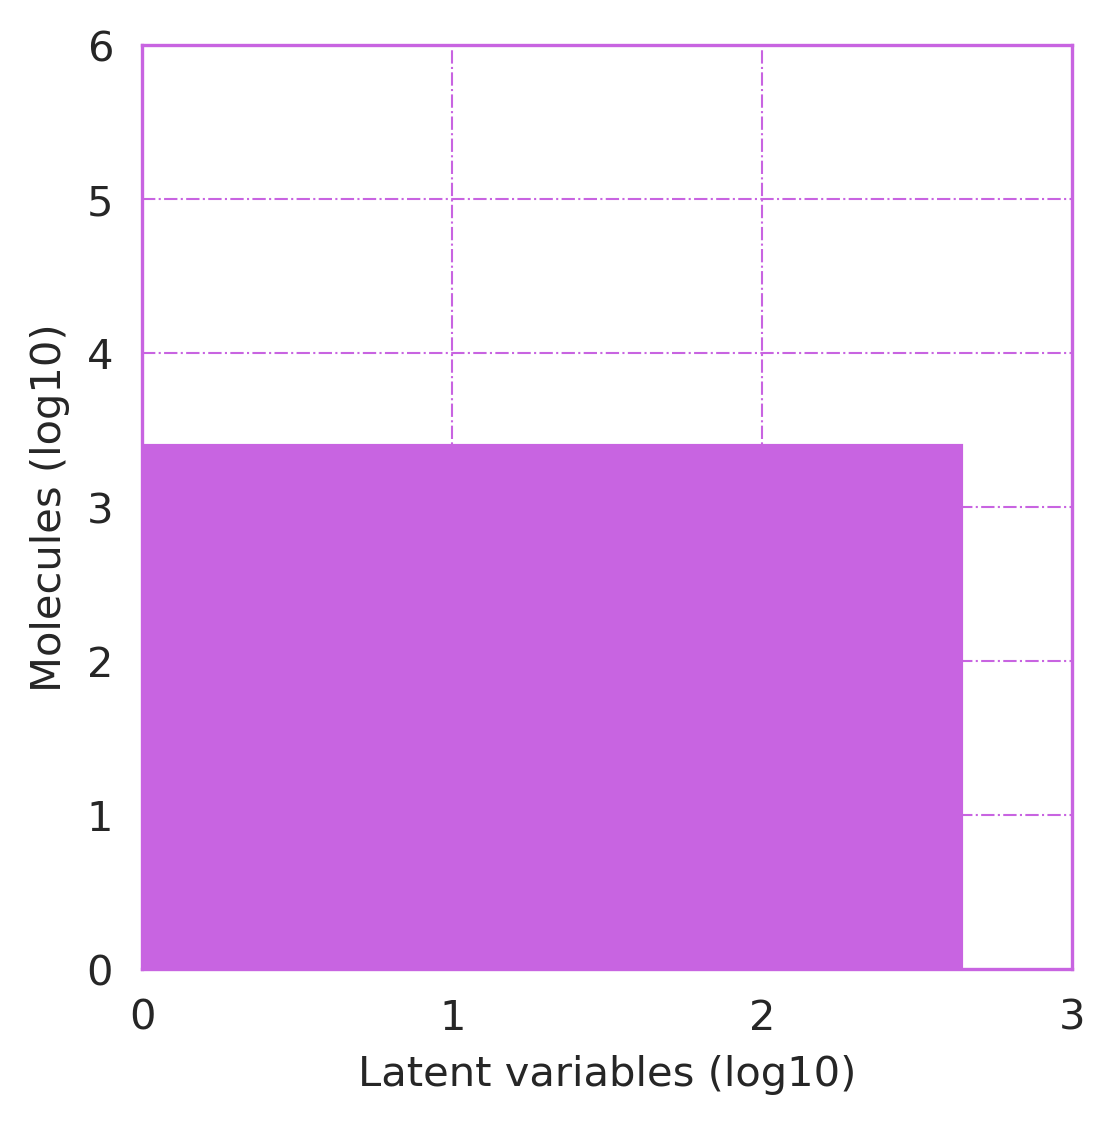

In [9]:
# Dataset Name
dataset = 'B1.002'

# Instantiation of sign0
sign0 = cc_local.signature(dataset, 'sign0')

# Instantiation of sign1
sign1 = cc_local.signature(dataset, 'sign1')

# Cleaning both full and reference datasets. This is crucial!
sign1.clear_all()

# Fitting sign1
sign1.fit(sign0)

In [15]:
sign1.shape

(5826, 438)

2024-10-24 16:56:41,568 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/full/B/B1/B1.002/sign1
2024-10-24 16:56:41,570 chemicalchecker.core.chemcheck.ChemicalChecker [DEBUG   ] ChemicalChecker with root: /aloy/home/acomajuncosa/Protocols/local_CC_B1
2024-10-24 16:56:41,705 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Computing or retrieving data for canvas small.
2024-10-24 16:56:41,707 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Skipping the following plots: []
2024-10-24 16:56:41,708 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Cosine distances
2024-10-24 16:56:41,711 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Subsampling signature
2024-10-24 16:56:41,738 chemicalchecker.core.signature_data.DataSignature [DEBUG   ] Full dataset sampled (n=5826)
2024-10-24 16:56:41,739 chemicalchecker.core.signature_data.DataSignature [DEBUG   ] Fetching dataset V
2024-10-24 16:56:42,46

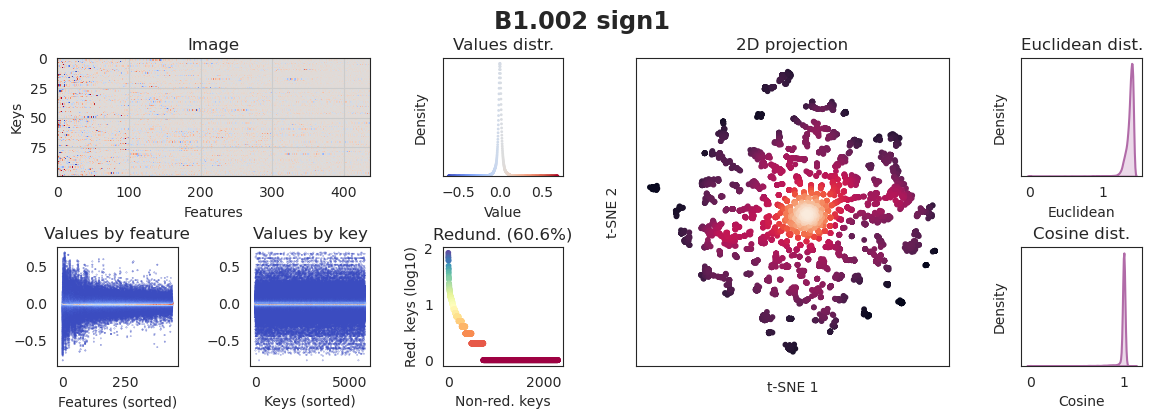

In [11]:
# Instantiation of sign1
sign1 = cc_local.signature(dataset, 'sign1')

# Instantiation of diag1 (diagnosis plots)
diag1 = sign1.diagnosis()

# Plot medium & small diagnosis plots
diag1.canvas(size='small', savefig=True, savefig_kwargs={'dpi': 300})

In [12]:
# Instantiation of sign1
sign1 = cc_local.signature(dataset, 'sign1')

# Instantiation of neig1
neig1 = cc_local.get_signature("neig1", "full", dataset)  # It will take the reference anyway...

# Cleaning both full and reference. This is crucial!
neig1.clear_all()

# Fitting neig1
neig1.fit(sign1)

2024-10-24 16:57:35,745 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/full/B/B1/B1.002/sign1
2024-10-24 16:57:35,747 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] New signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/full/B/B1/B1.002/neig1
2024-10-24 16:57:35,752 chemicalchecker.core.neig.neig [DEBUG   ] signature path is: /aloy/home/acomajuncosa/Protocols/local_CC_B1/full/B/B1/B1.002/neig1
2024-10-24 16:57:35,753 chemicalchecker.core.neig.neig [DEBUG   ] data_path: /aloy/home/acomajuncosa/Protocols/local_CC_B1/full/B/B1/B1.002/neig1/neig.h5
2024-10-24 16:57:35,756 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] New signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/reference/B/B1/B1.002/neig1
2024-10-24 16:57:35,767 chemicalchecker.core.neig.neig [DEBUG   ] signature path is: /aloy/home/acomajuncosa/Protocols/local_CC_B1/reference/B/B1/B1.002/neig1
2024-10-24 16:57:

In [13]:
neig1.shape

array([5826, 1000])

In [14]:
np.min(np.array(sign1).flatten()), np.max(np.array(sign1).flatten())

(-0.7788318466400815, 0.6927091436152755)

## sign2 ##

2024-10-24 17:15:17,998 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/full/B/B1/B1.002/sign1
2024-10-24 17:15:18,002 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/full/B/B1/B1.002/neig1
2024-10-24 17:15:18,004 chemicalchecker.core.neig.neig [DEBUG   ] signature path is: /aloy/home/acomajuncosa/Protocols/local_CC_B1/full/B/B1/B1.002/neig1
2024-10-24 17:15:18,005 chemicalchecker.core.neig.neig [DEBUG   ] data_path: /aloy/home/acomajuncosa/Protocols/local_CC_B1/full/B/B1/B1.002/neig1/neig.h5
2024-10-24 17:15:18,006 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] New signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/full/B/B1/B1.002/sign2
2024-10-24 17:15:18,013 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] New signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/reference/B/B1/B1.002/sign2
202

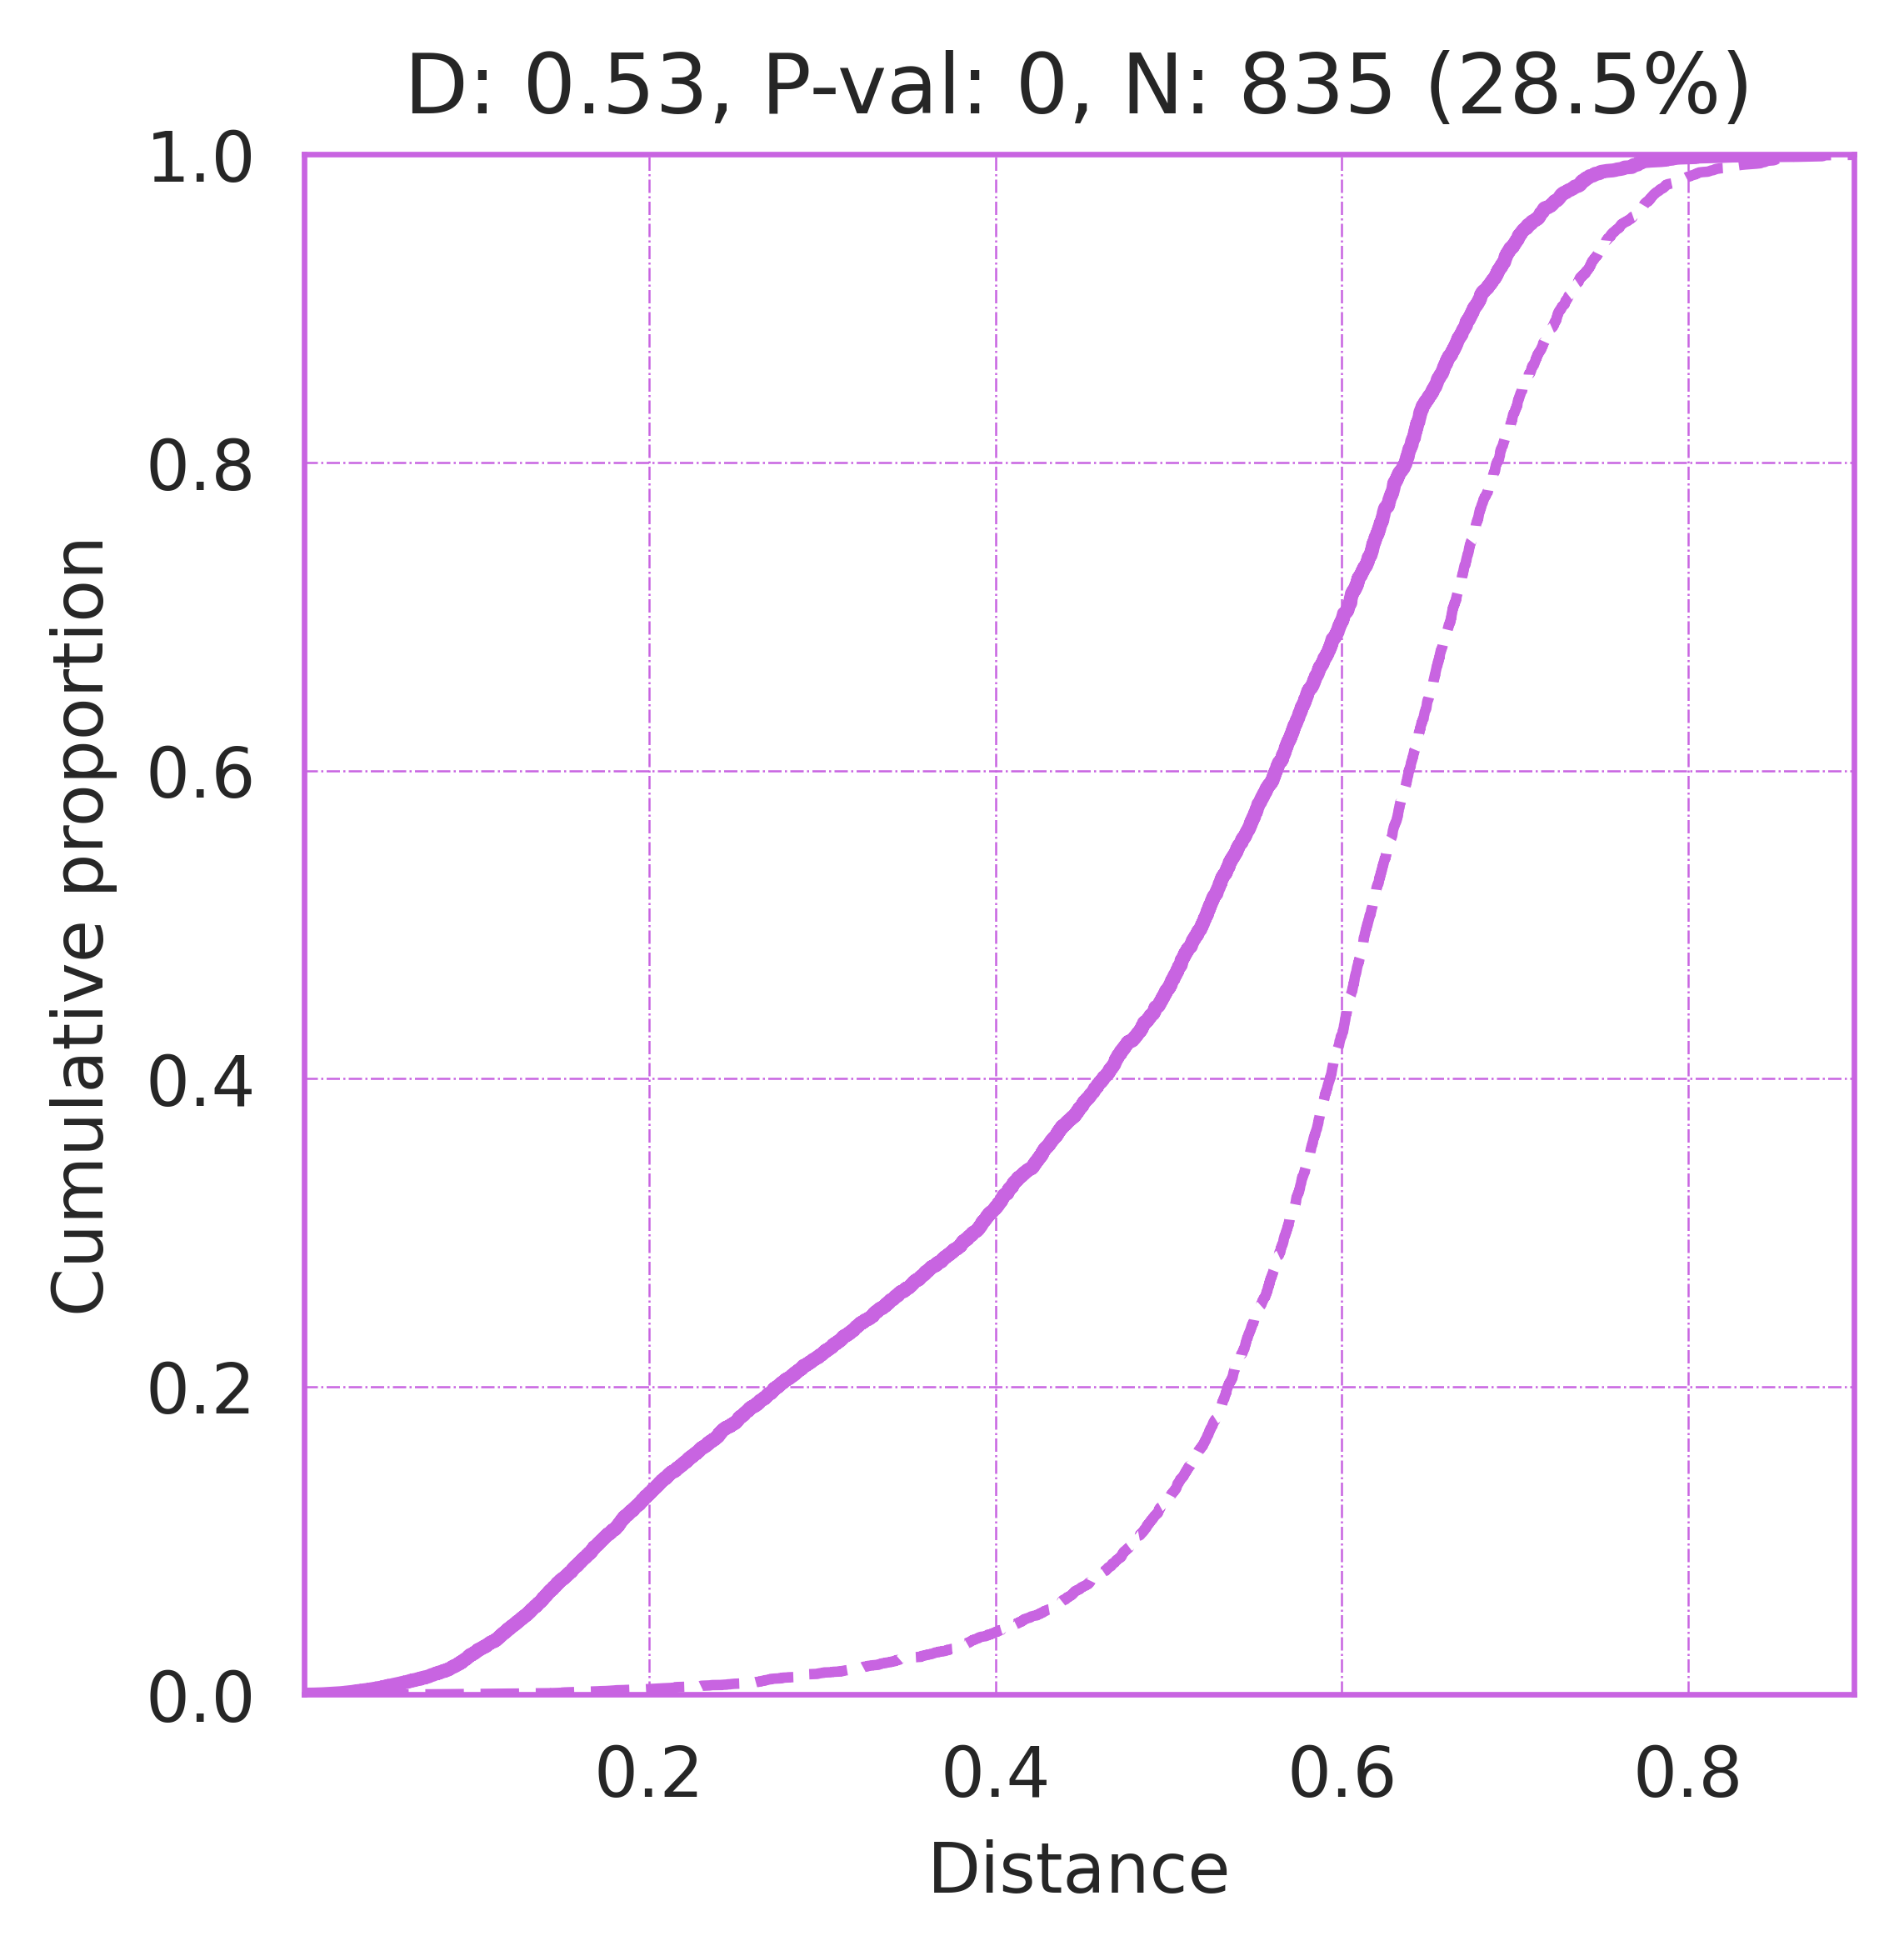

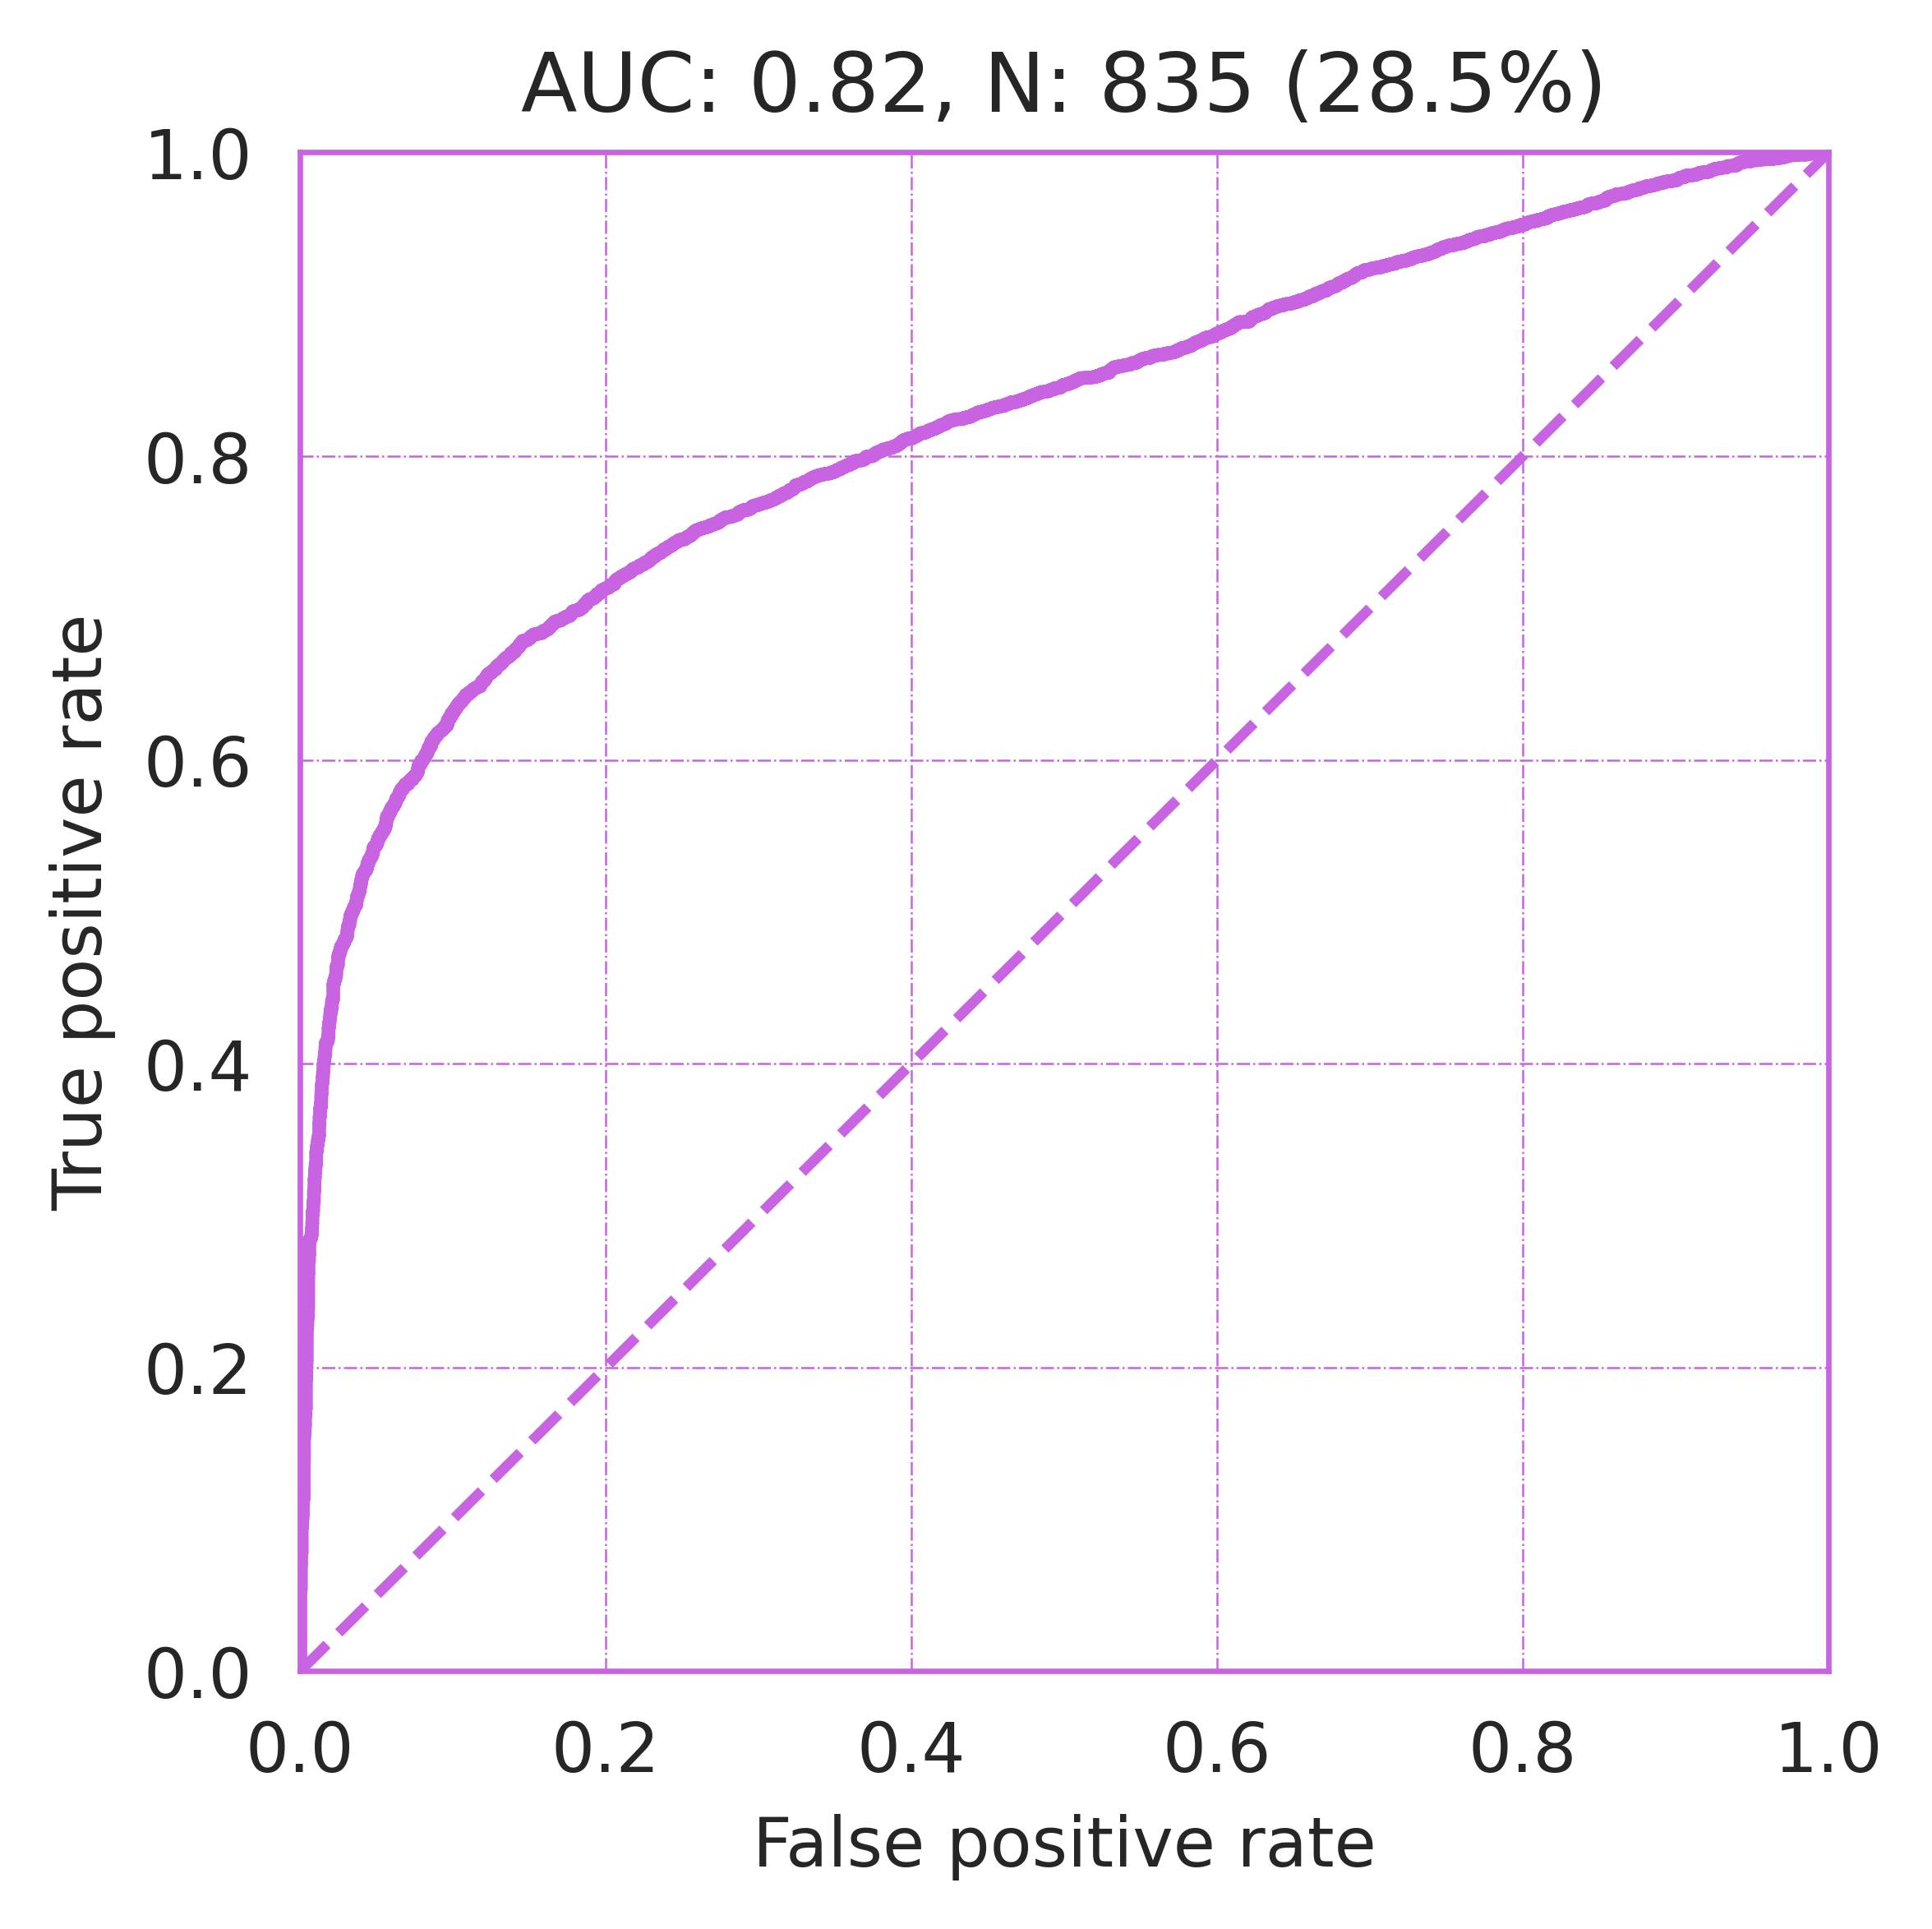

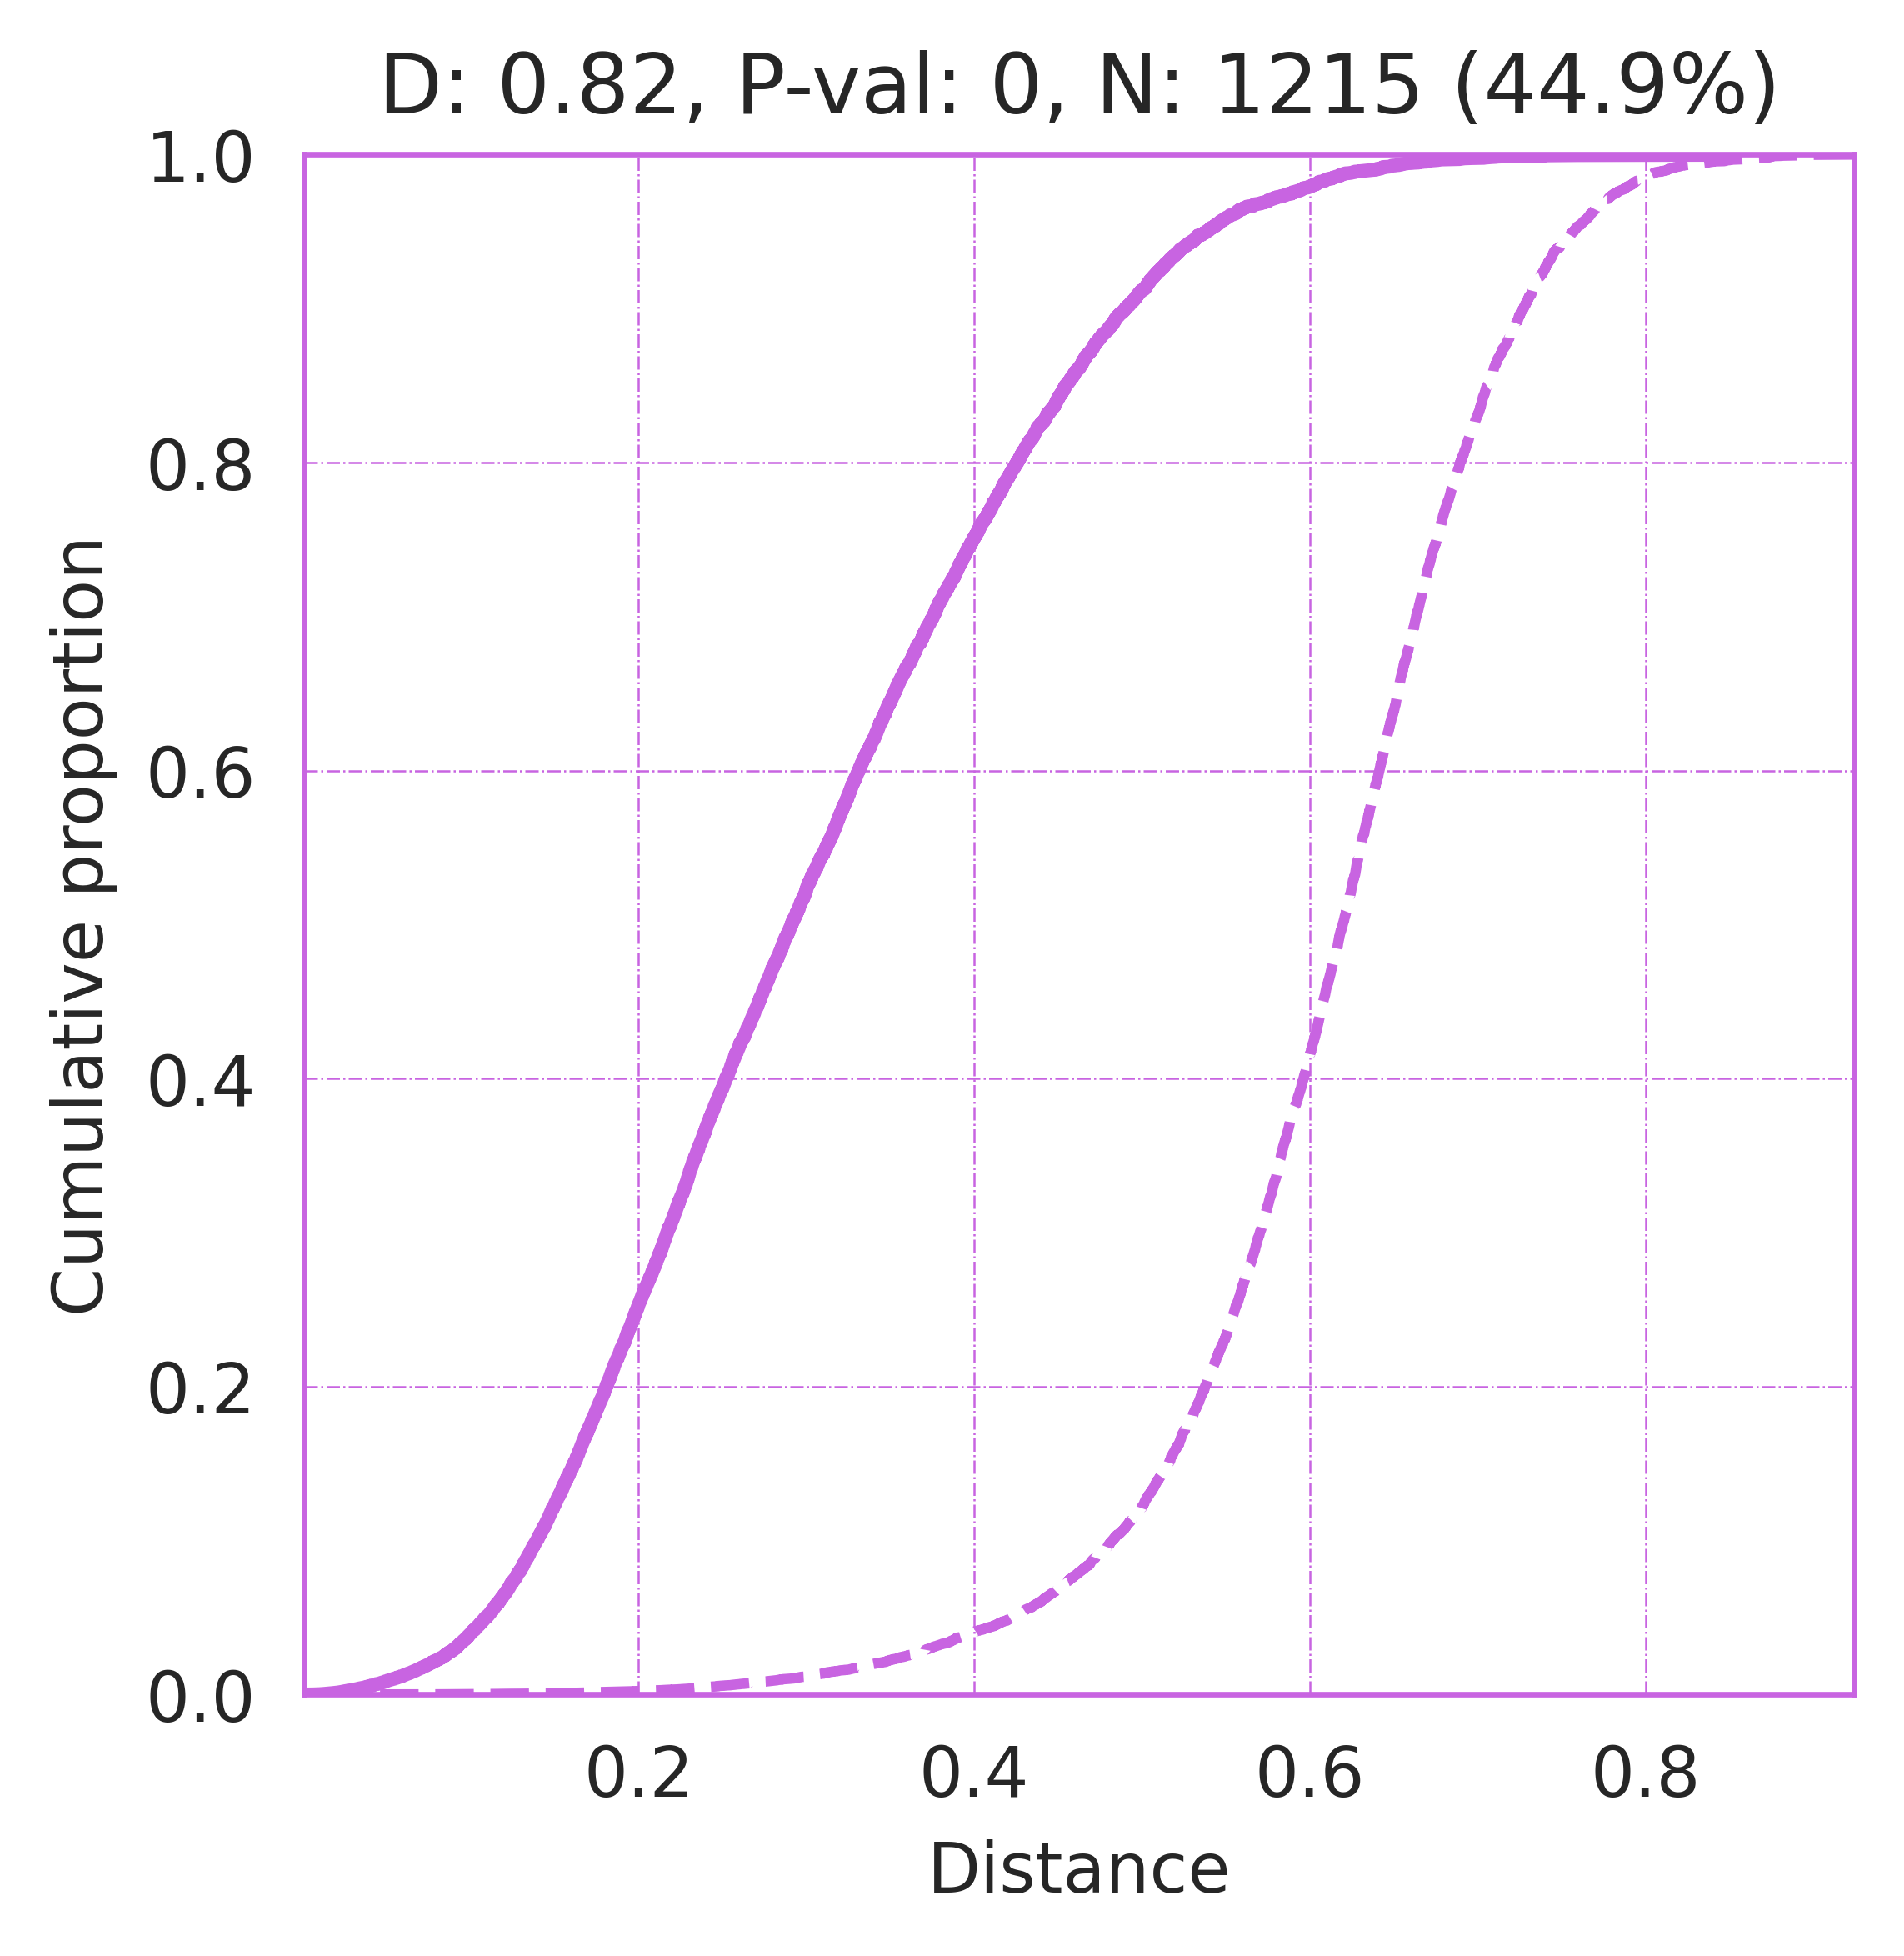

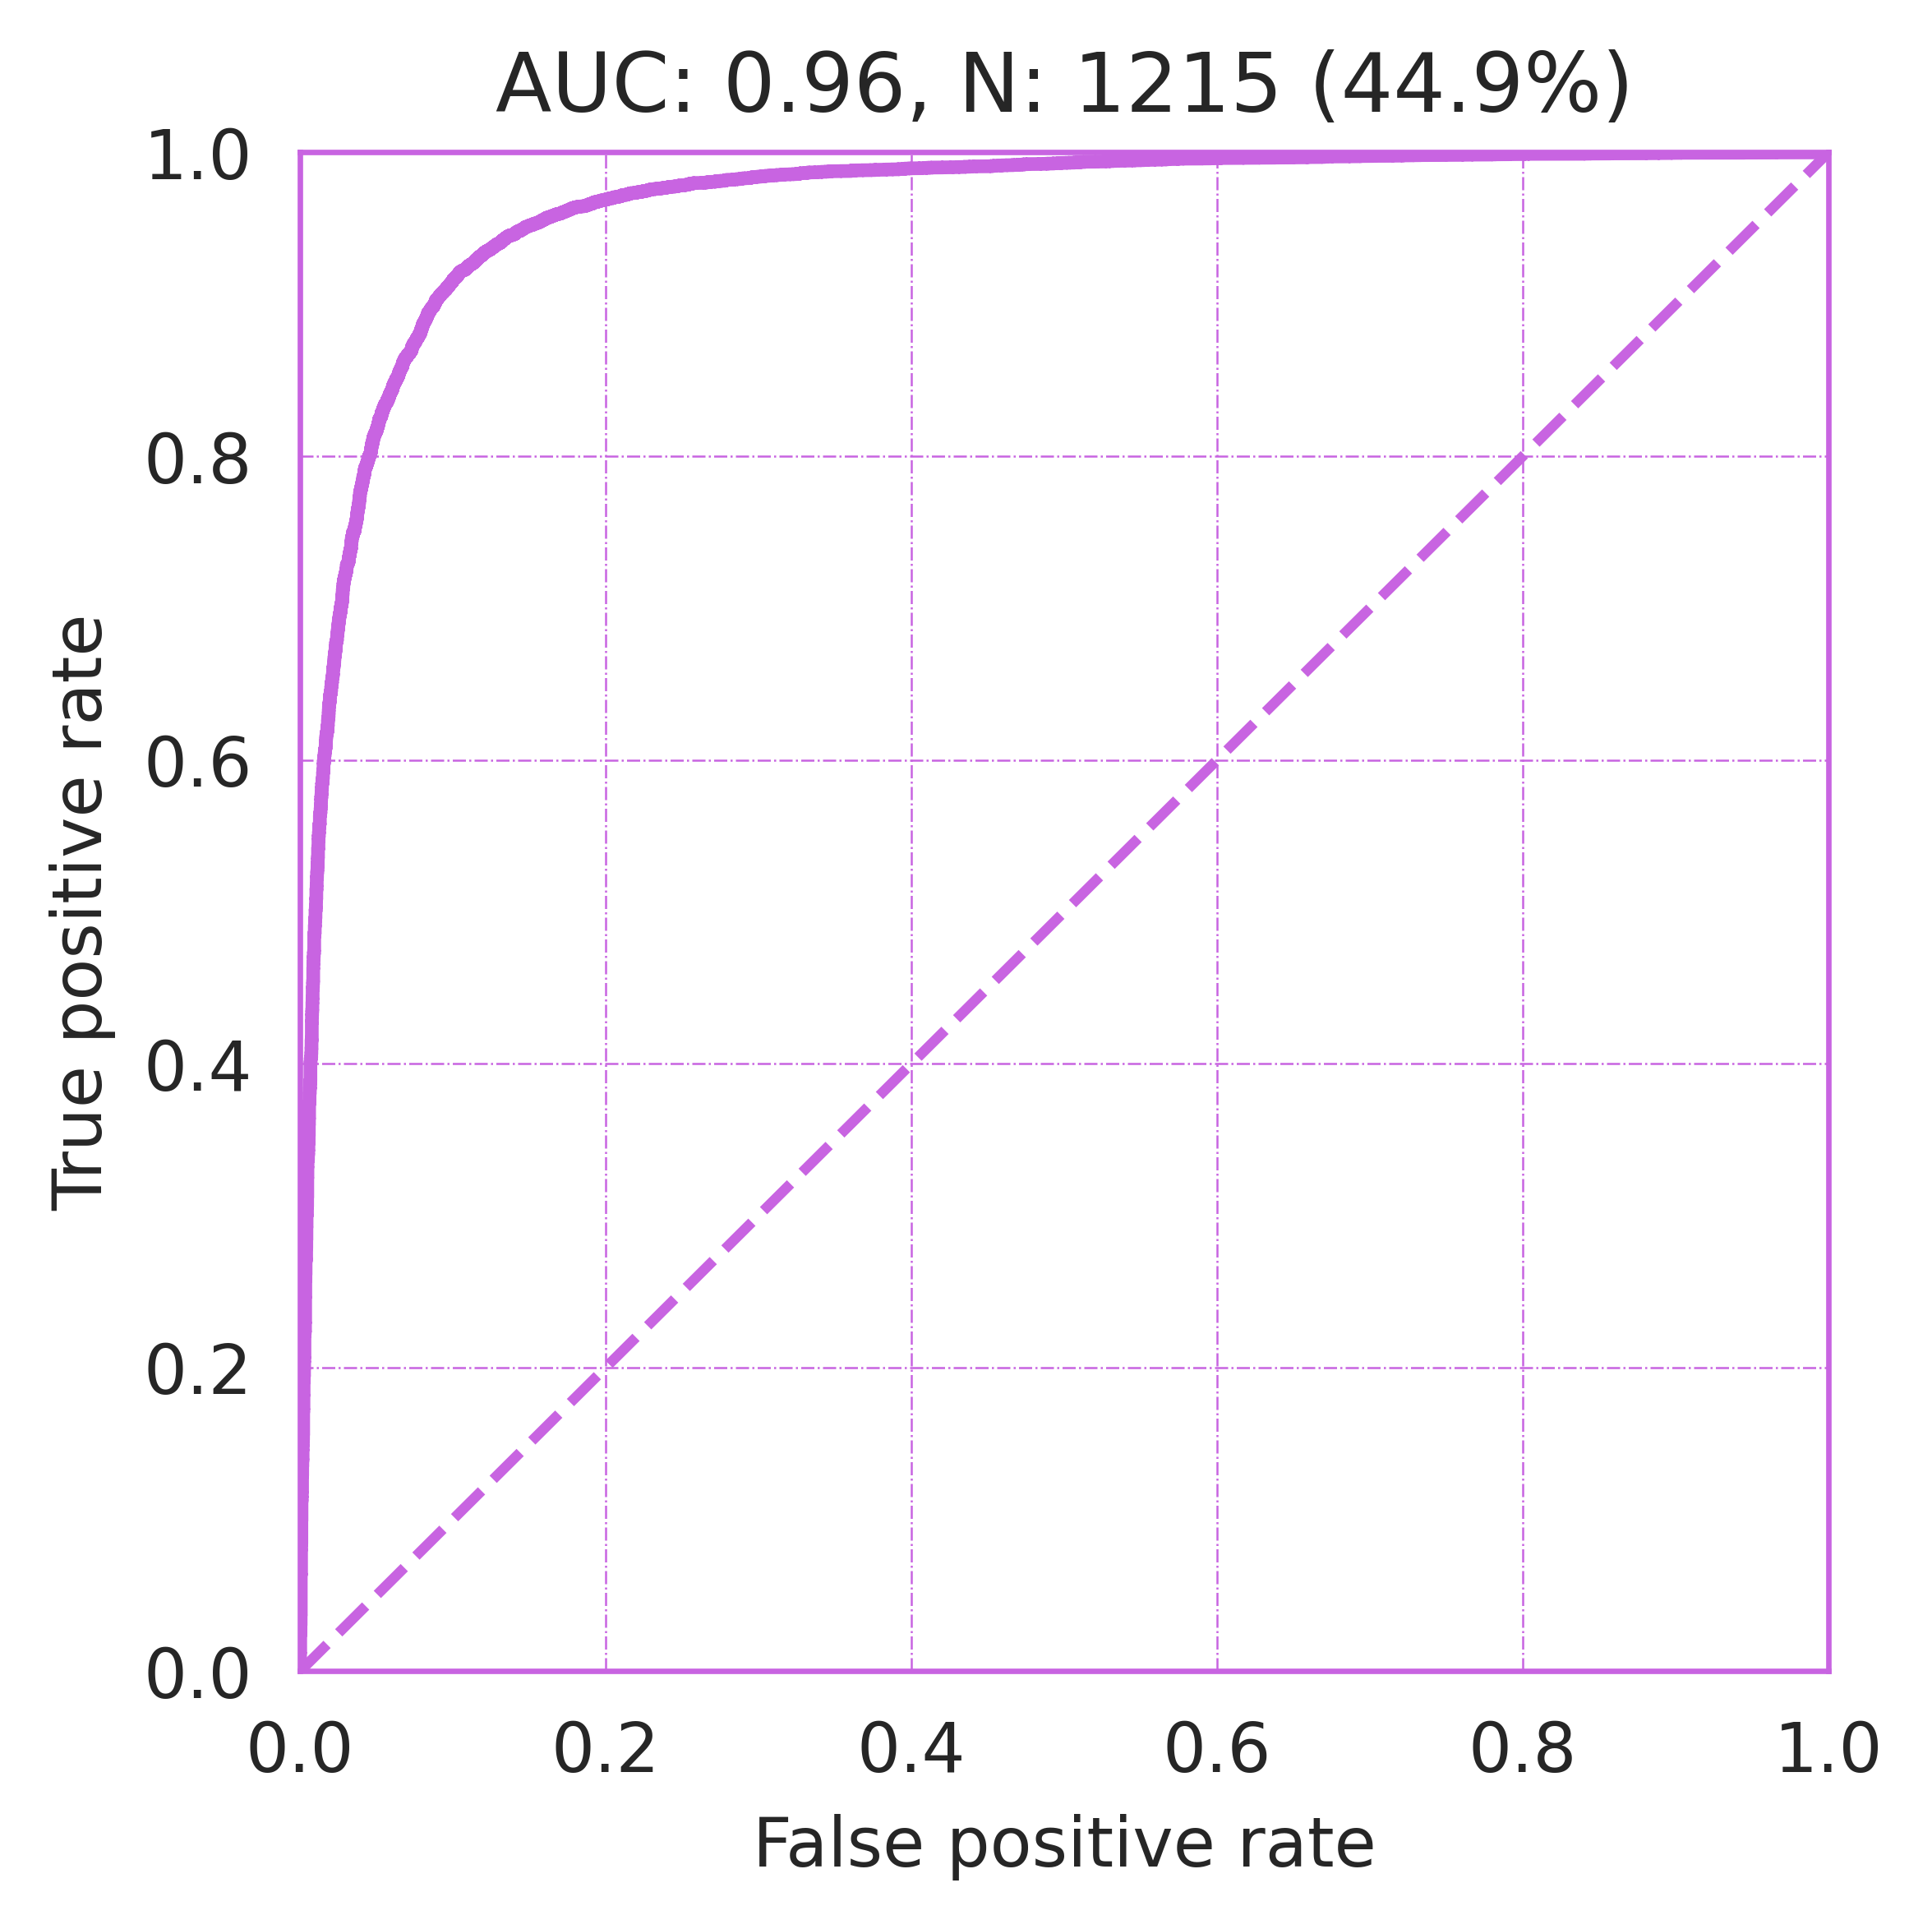

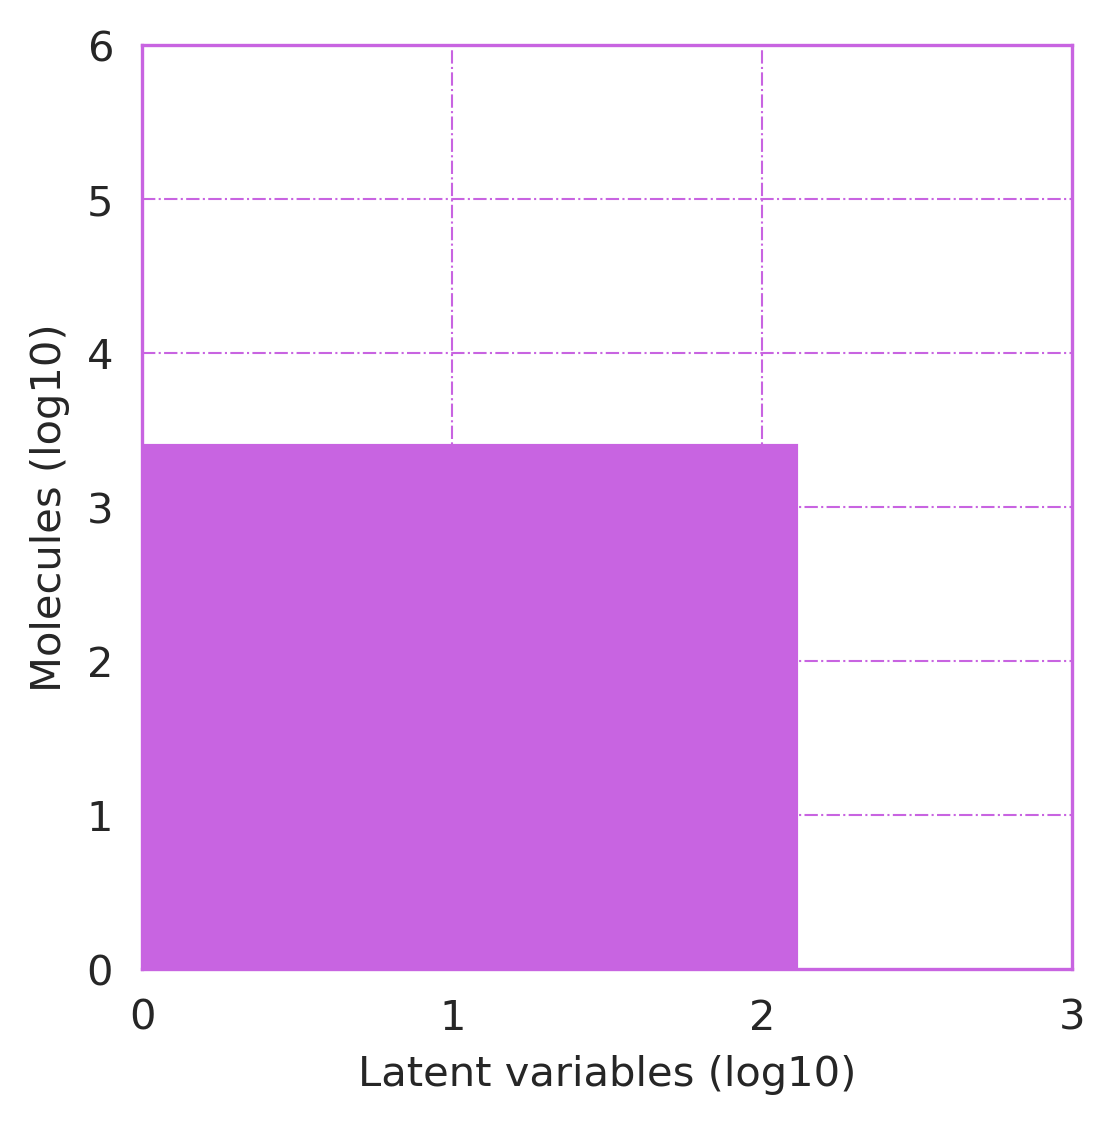

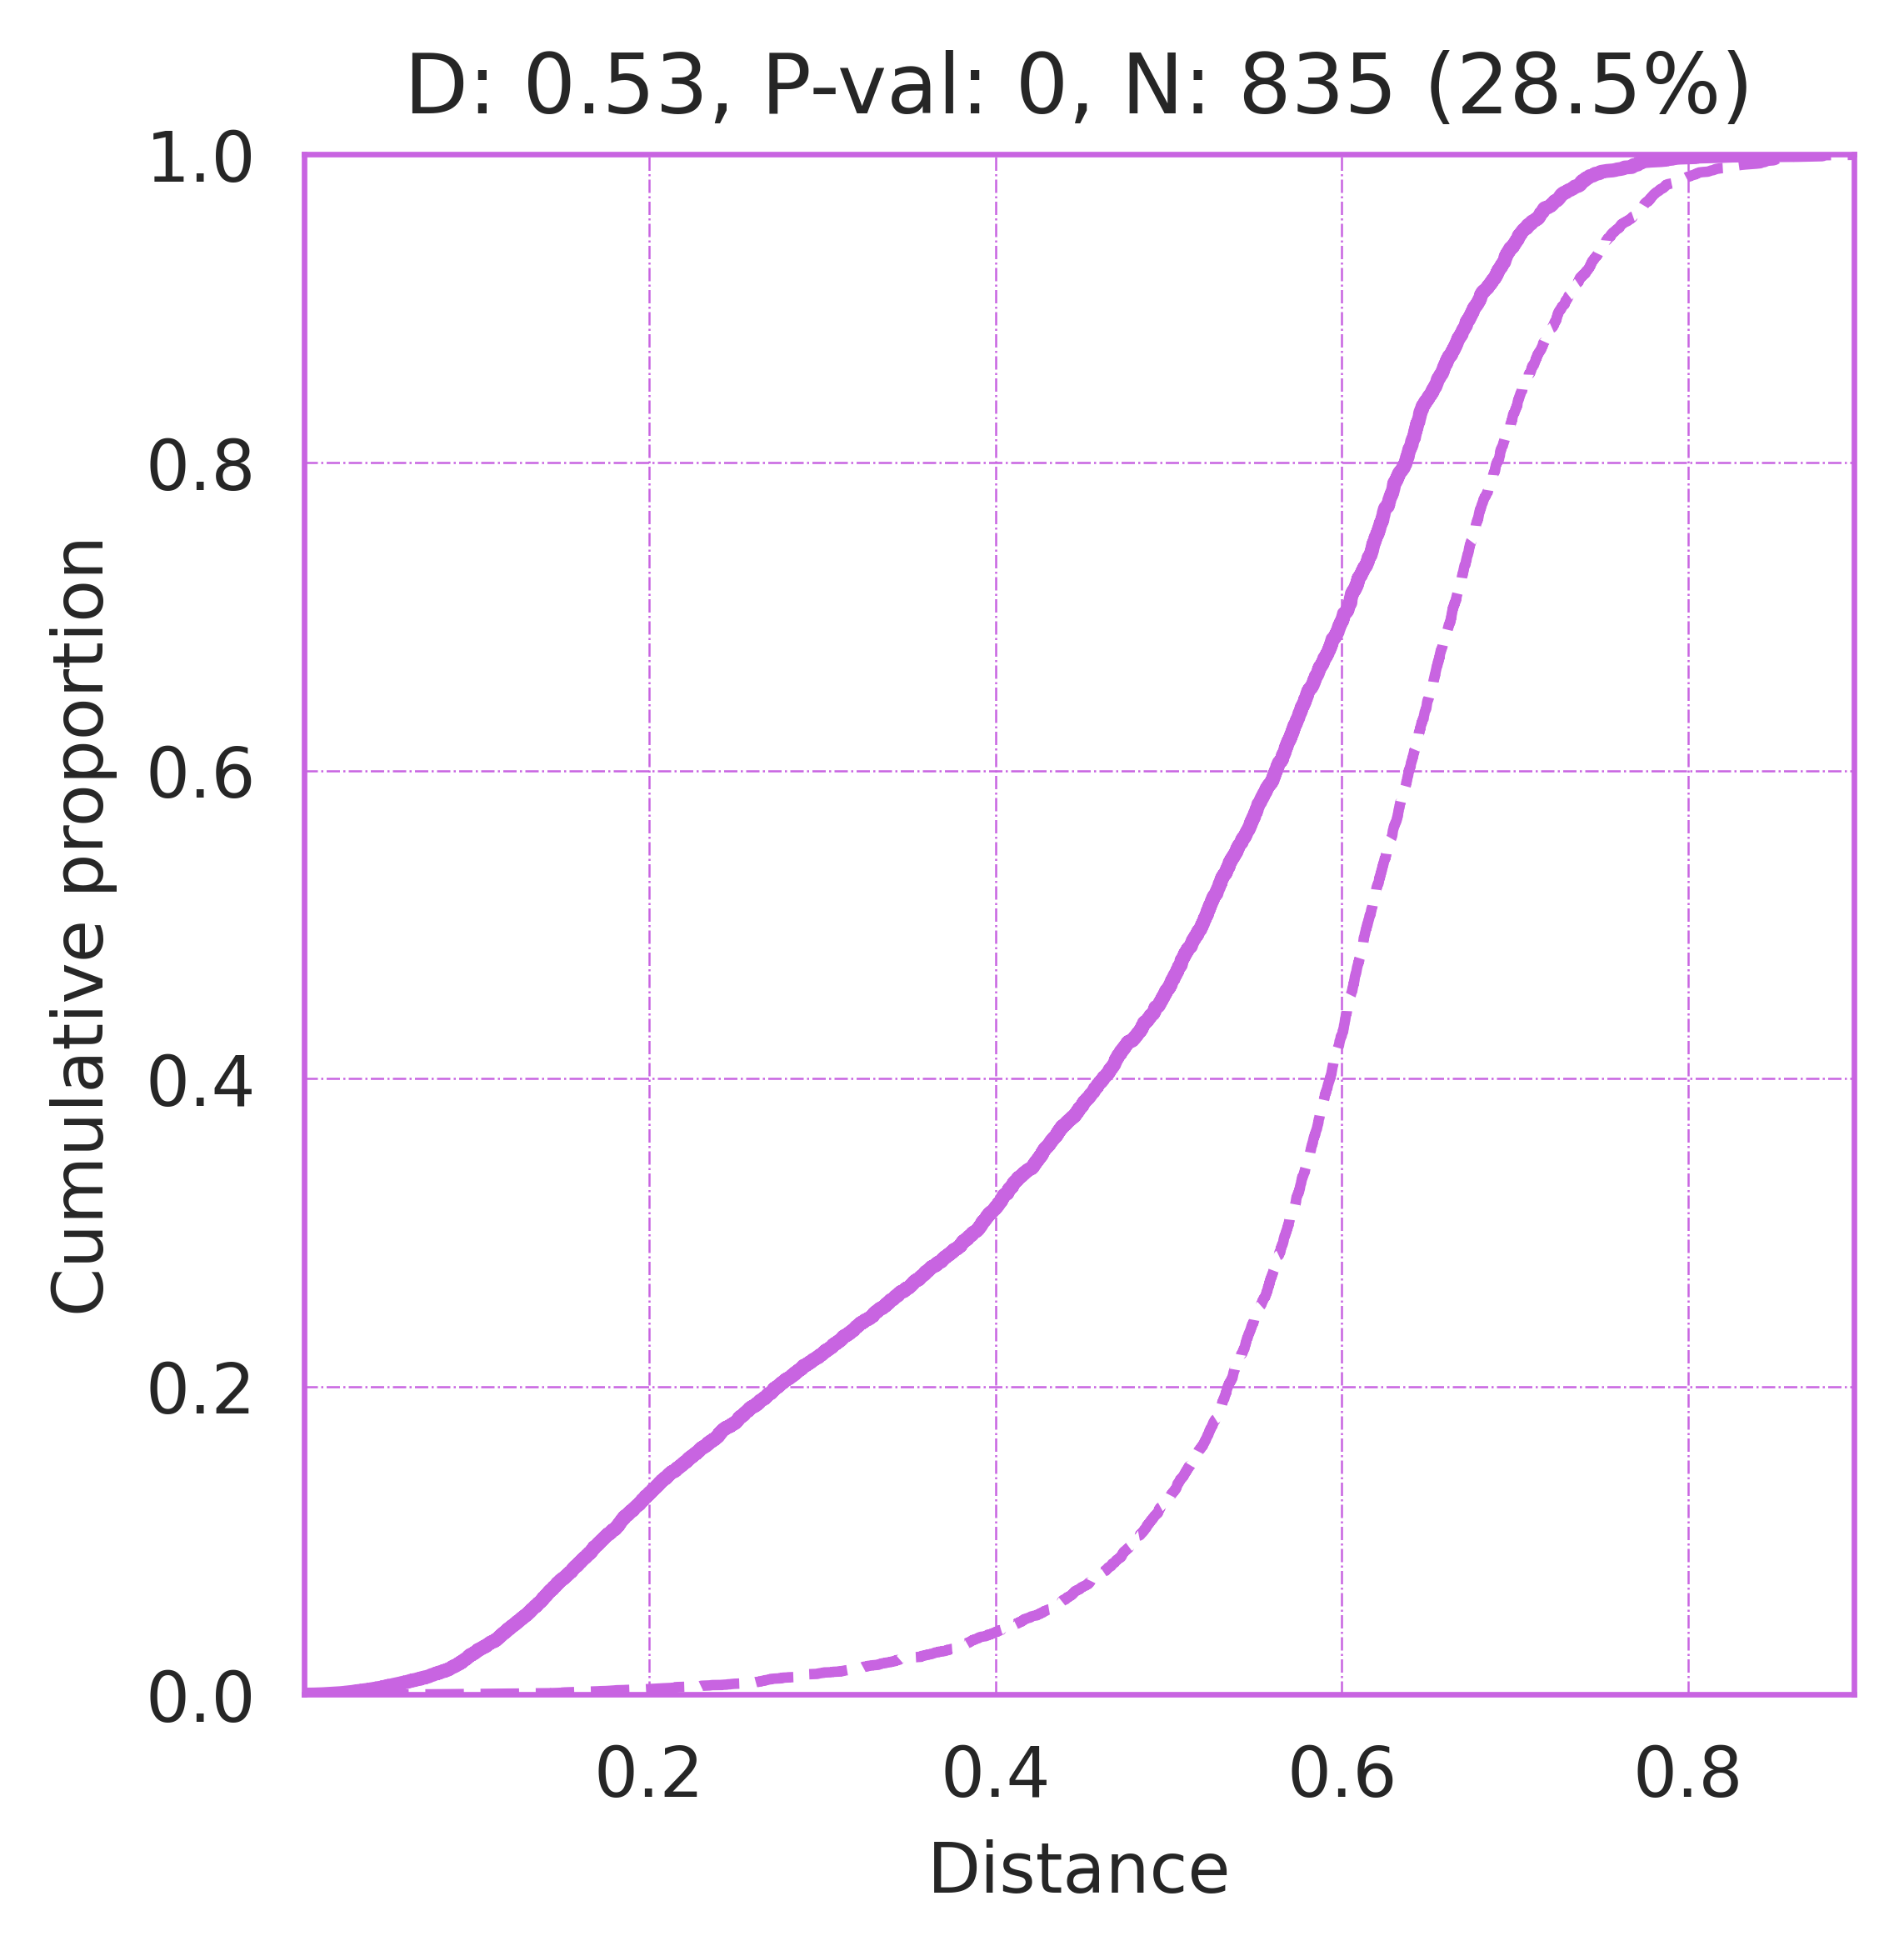

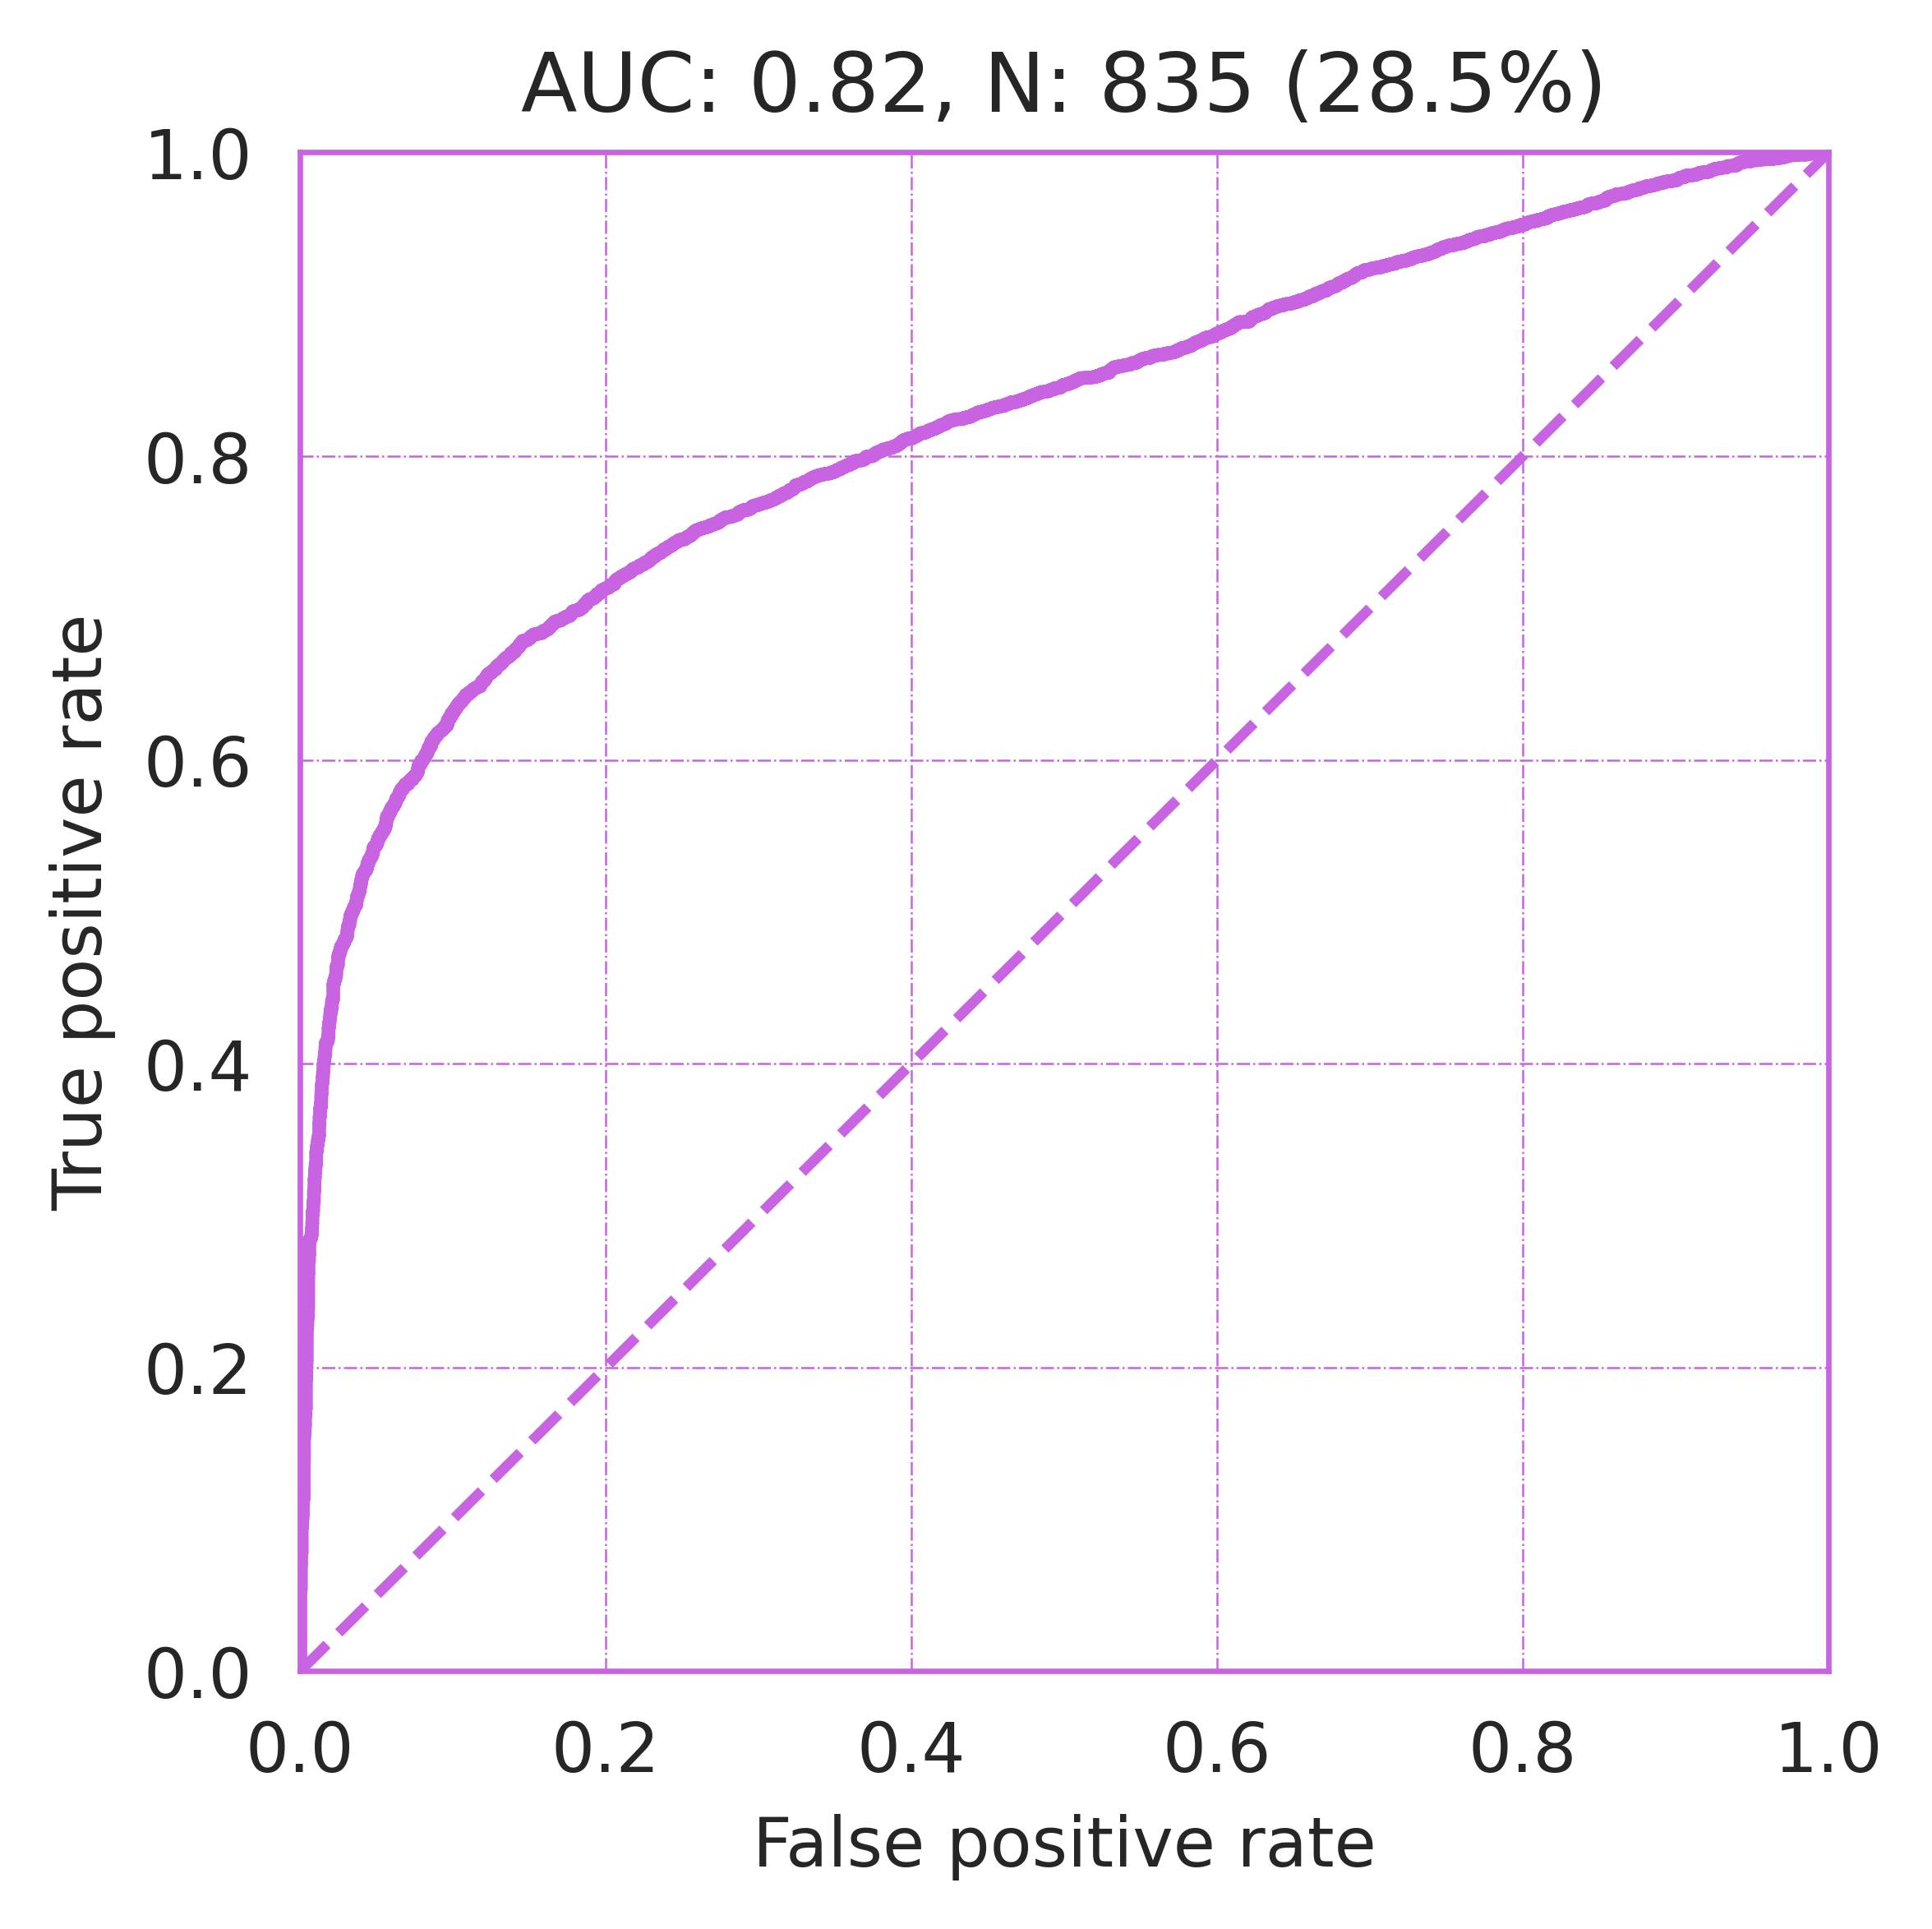

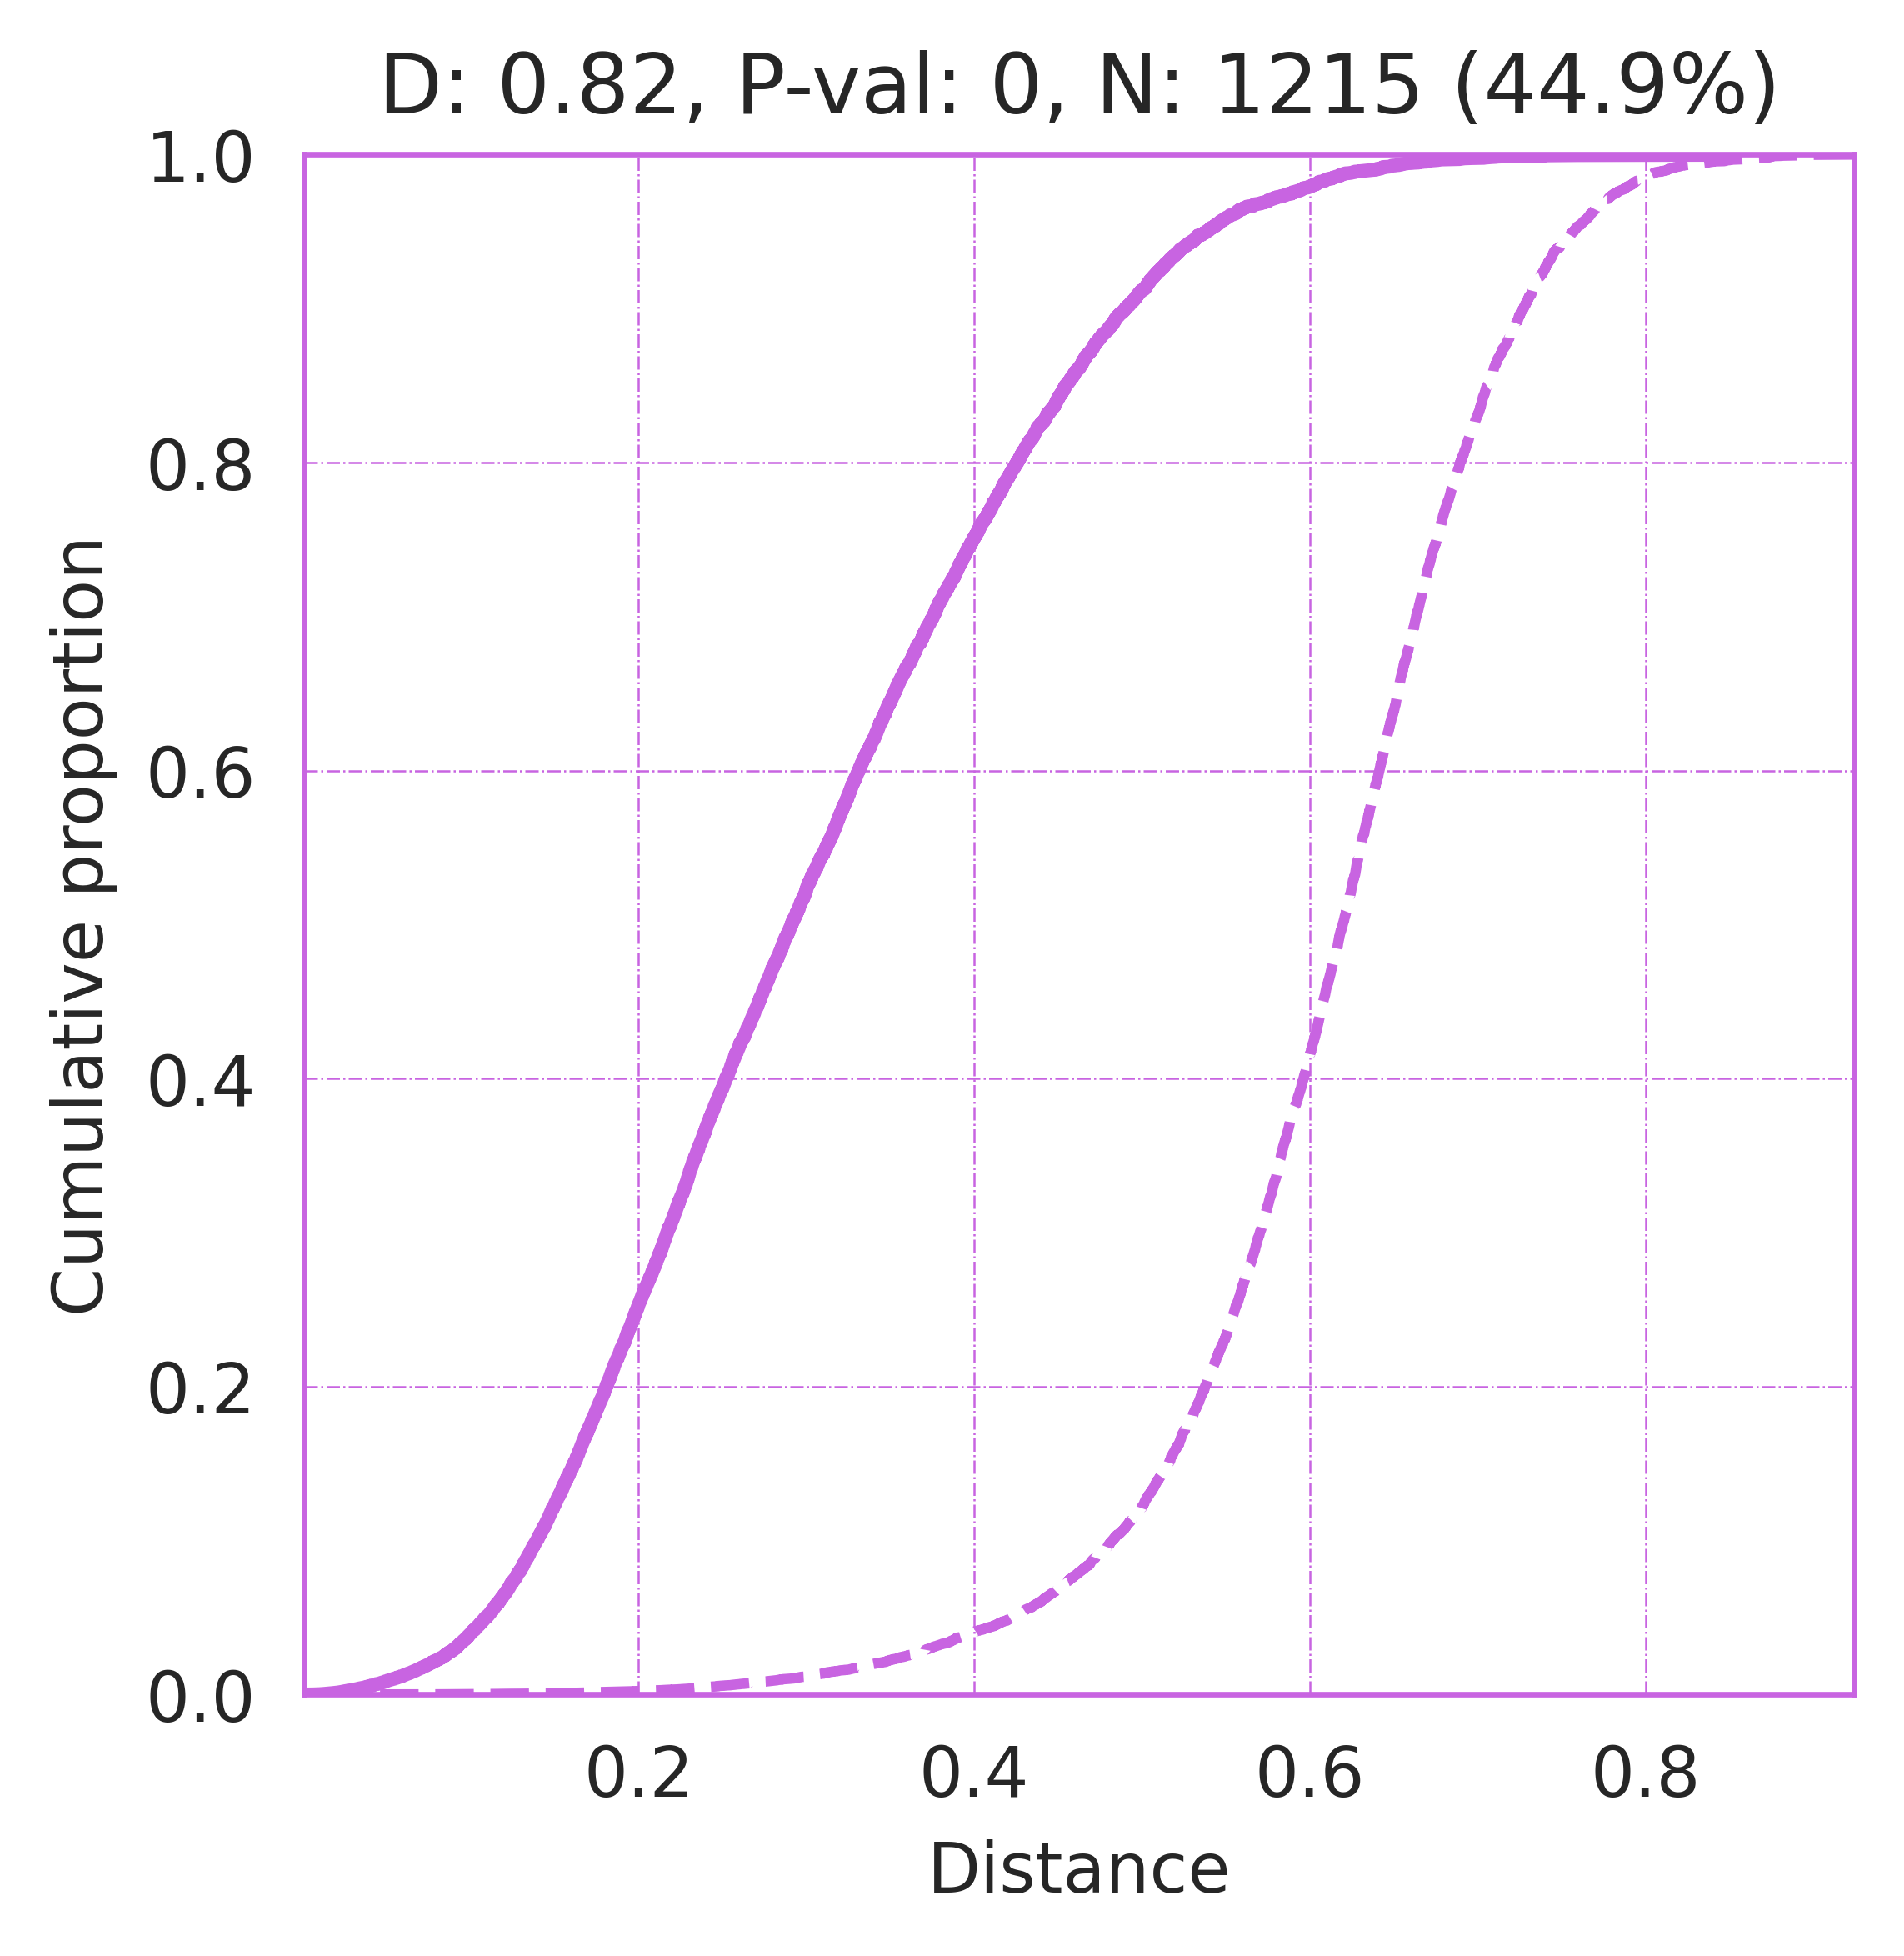

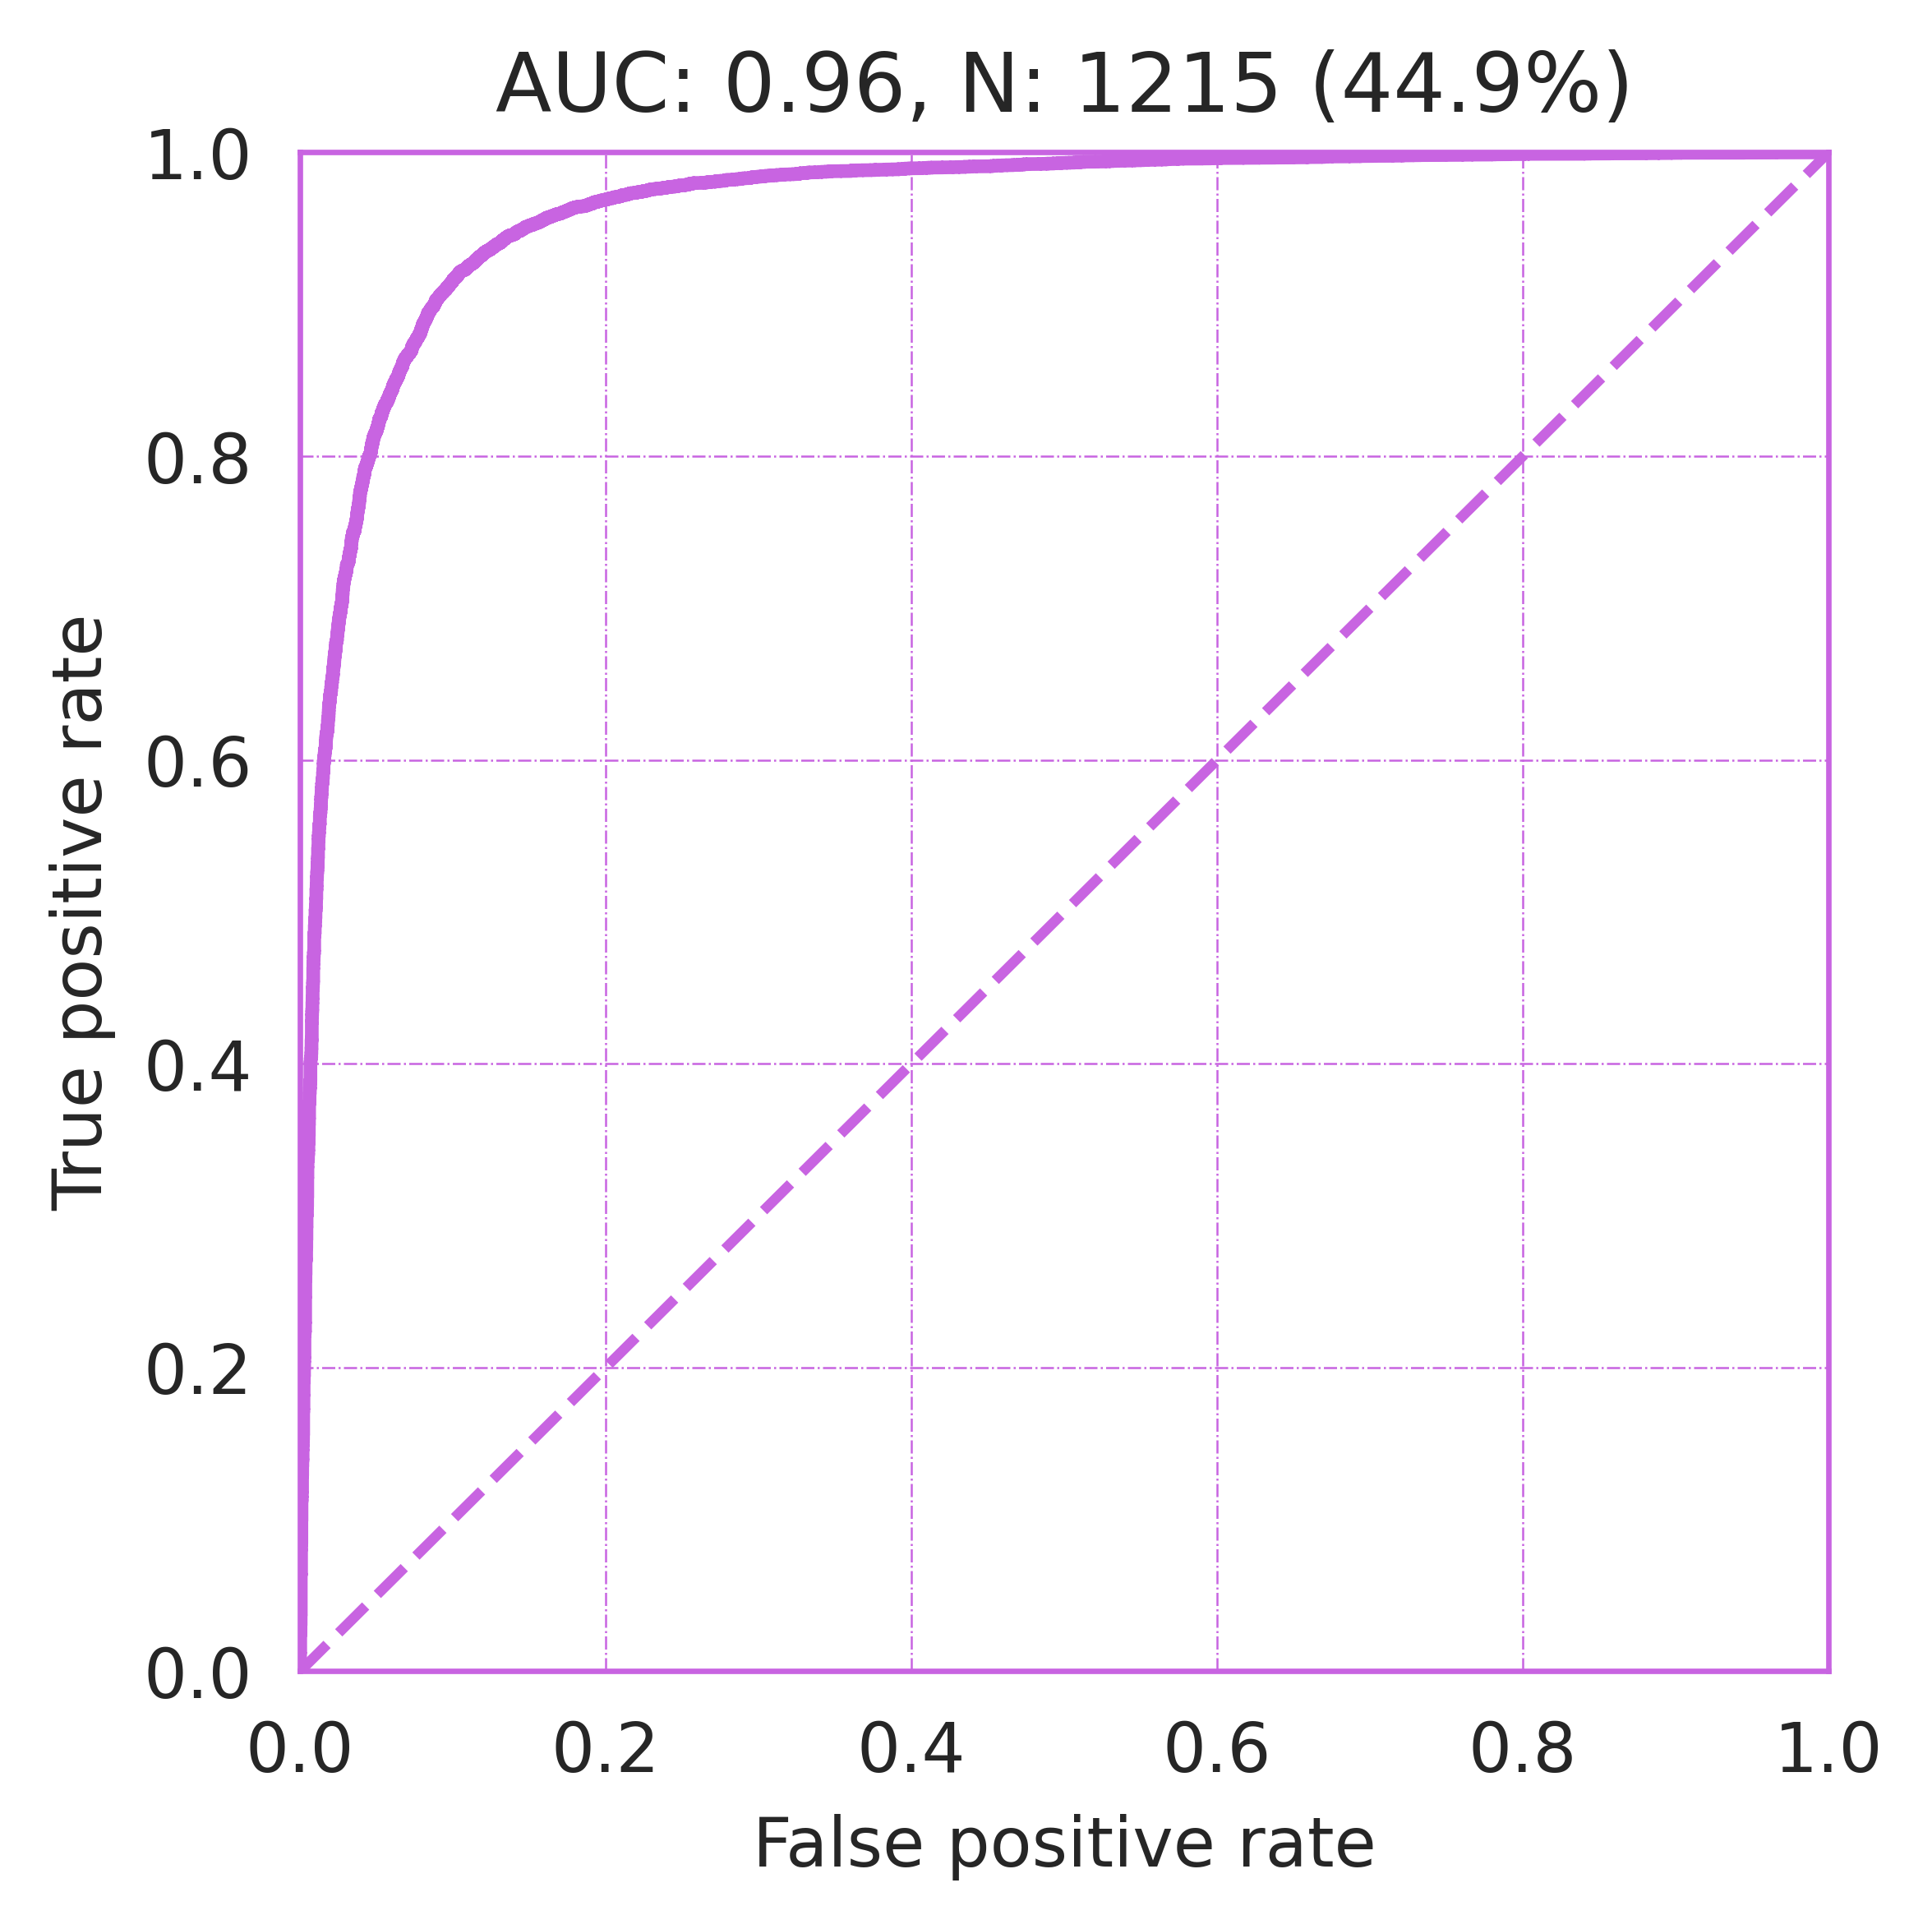

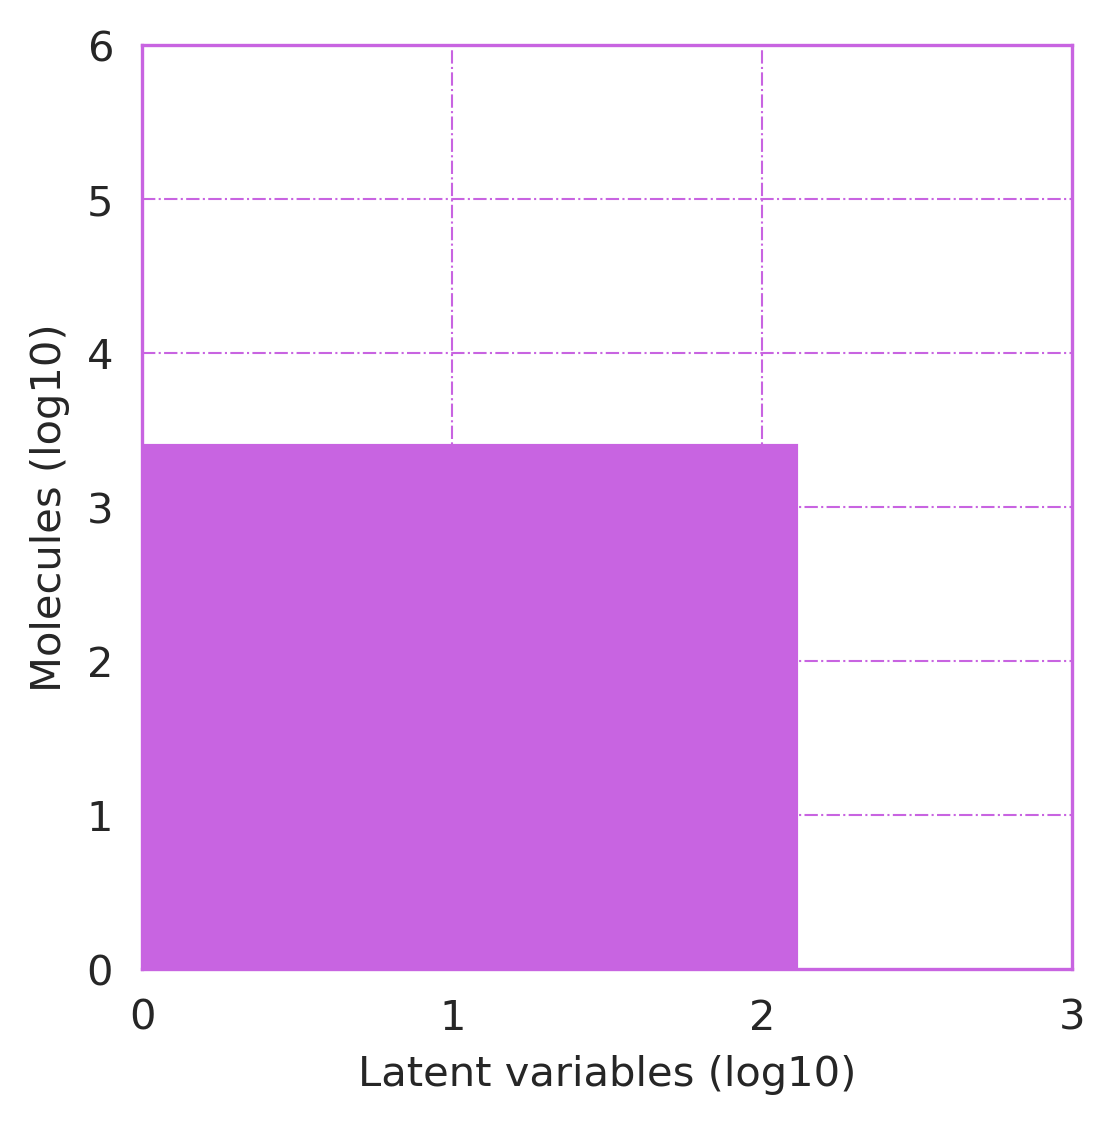

In [16]:
# Dataset Name
dataset = 'B1.002'

# Get sign1
sign1 = cc_local.get_signature('sign1', 'full', dataset)

# Get neig1
neig1 = cc_local.get_signature('neig1', 'full', dataset)  # By default, all vs ref

# Instantiation of sign2
sign2 = cc_local.signature(dataset, 'sign2')

# Cleaning both full and reference datasets. This is crucial!
sign2.clear_all()

# Fit sign2 given sign1 & neig1
sign2.fit(sign1, neig1, oos_predictor=False)

In [17]:
sign2.shape

(5826, 128)

2024-10-24 17:16:28,600 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/full/B/B1/B1.002/sign2
2024-10-24 17:16:28,602 chemicalchecker.core.chemcheck.ChemicalChecker [DEBUG   ] ChemicalChecker with root: /aloy/home/acomajuncosa/Protocols/local_CC_B1
2024-10-24 17:16:28,716 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Computing or retrieving data for canvas small.
2024-10-24 17:16:28,717 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Skipping the following plots: []
2024-10-24 17:16:28,719 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Cosine distances
2024-10-24 17:16:28,722 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Subsampling signature
2024-10-24 17:16:28,756 chemicalchecker.core.signature_data.DataSignature [DEBUG   ] Full dataset sampled (n=5826)
2024-10-24 17:16:28,757 chemicalchecker.core.signature_data.DataSignature [DEBUG   ] Fetching dataset V
2024-10-24 17:16:28,82

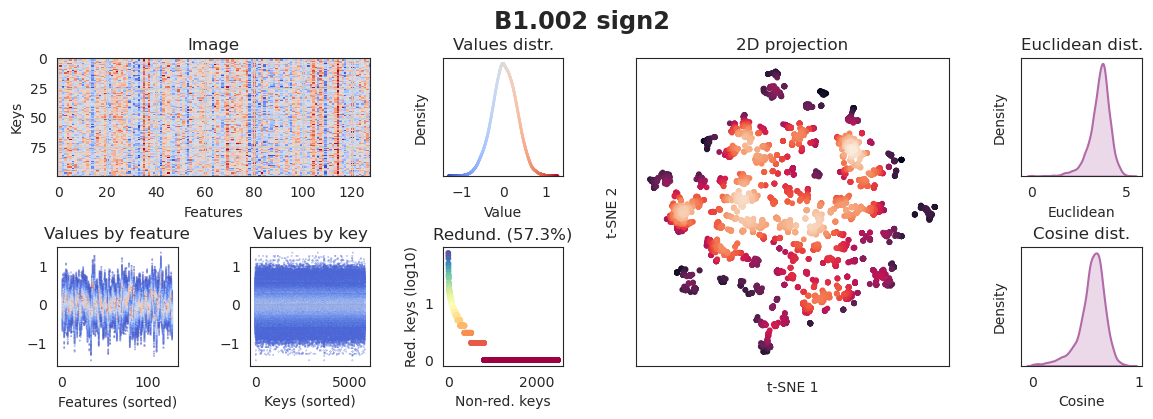

In [18]:
# Instantiation of sign2
sign2 = cc_local.signature(dataset, 'sign2')

# Instantiation of diag2 (diagnosis plots)
diag2 = sign2.diagnosis()

# Plot medium & small diagnosis plots
diag2.canvas(size='small', savefig=True, savefig_kwargs={'dpi': 300})

In [20]:
np.min(np.array(sign2).flatten()), np.max(np.array(sign2).flatten())

(-1.47321, 1.38038)

## sign3 ##

In [21]:
# Dataset Name
dataset = 'B1.002'

# Get CC universe
cc_universe = []
for dat in cc_local.datasets:
    if dat != dataset and dat.endswith('001') and "B1" not in dat:
        cc_universe.extend(cc_local.get_signature('sign2', 'full', dat).keys)
cc_universe = set(cc_universe)

# Get sign2
sign2 = cc_local.signature(dataset, 'sign2')

# Get B1.002 molecules
b1_molecules = set(sign2.keys)

print("Number of molecules in the CC universe: " + str(len(cc_universe)))
print("Number of molecules in B1.002 sign2: " + str(len(b1_molecules)))
print("Intersection CC & B1.002: " + str(len(cc_universe.intersection(b1_molecules))))

2024-10-24 17:19:40,419 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/full/A/A1/A1.001/sign2
2024-10-24 17:19:42,817 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/full/A/A2/A2.001/sign2
2024-10-24 17:19:44,828 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/full/A/A3/A3.001/sign2
2024-10-24 17:19:47,197 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/full/A/A4/A4.001/sign2
2024-10-24 17:19:49,563 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/full/A/A5/A5.001/sign2
2024-10-24 17:19:51,945 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /aloy/home/acomajuncosa/Protoco

Number of molecules in the CC universe: 1009293
Number of molecules in B1.002 sign2: 5826
Intersection CC & B1.002: 5433


In [22]:
# Dataset Name
dataset = 'B1.002'

# Instantiation of sign3
sign3 = cc_local.signature(dataset, 'sign3')
sign3.clear_all()

# Create a list of sign2 to feed sign3 -- using the 24 CC spaces (without B1.001) and B1.002
sign2_list = list()

# For each CC space
for ds in cc_local.coordinates:
    ds += '.001'
    if ds == 'B1.001':
        ds = 'B1.002'
    sign2_list.append(cc_local.get_signature('sign2', 'full', ds))

# In total, we now have 25 spaces
print(len(sign2_list))

# Get B1.002 sign1
sign1_self = cc_local.signature(dataset, 'sign1')

# Get B1.002 sign2
sign2_self = cc_local.signature(dataset, 'sign2')

2024-10-24 17:21:33,878 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] New signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/full/B/B1/B1.002/sign3
2024-10-24 17:21:33,884 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/full/B/B1/B1.002/sign1
2024-10-24 17:21:33,889 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/reference/B/B1/B1.002/sign1
2024-10-24 17:21:33,892 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/reference/B/B1/B1.002/sign1
2024-10-24 17:21:33,894 chemicalchecker.core.sign1.sign1 [DEBUG   ] Reading triplets
2024-10-24 17:21:33,895 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/reference/B/B1/B1.002/sign1
2024-10-24 17:21:33,895 chemicalchecker

25


In [23]:
# Fit sign3 

# Option 1: in the cluster
# kwargs = {"cpu": 5, "mem_by_core": 12, "wait": False}  # GPU SBNB-IRB CONFIGURATION
# kwargs = {"cpu": 32, "mem_by_core": 1, "wait": False}  # CPU SBNB-IRB CONFIGURATION
# sign3.fit_hpc(sign2_list, sign2_self, sign1_self, sign2_universe=None, complete_universe="full", sign2_coverage=None, hpc_args=kwargs)

# Option 2: locally  // CAUTION: COMPUTATIONALLY DEMANDING STEP
sign3.fit(sign2_list, sign2_self, sign1_self, sign2_universe=None, complete_universe=False, sign2_coverage=None)  # Consider not completing the universe

2024-10-24 17:22:16,070 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] CC_Config for function fit is: /aloy/home/acomajuncosa/cc_config.json
2024-10-24 17:22:16,072 chemicalchecker.util.config.config.Config [DEBUG   ] Loading config from: /aloy/home/acomajuncosa/cc_config.json
2024-10-24 17:22:16,084 chemicalchecker.util.hpc.hpc.HPC [DEBUG   ] HPC system to use: slurm
2024-10-24 17:22:16,084 chemicalchecker.util.hpc.hpc.HPC [DEBUG   ] initializing object slurm
2024-10-24 17:22:17,589 chemicalchecker.util.hpc.slurm.slurm [DEBUG   ] Job name is: CC_SIGN3_B1.002_fit__
2024-10-24 17:22:17,591 chemicalchecker.util.hpc.slurm.slurm [INFO    ] Writing file /aloy/scratch/acomajuncosa/CC/tmp_jobs/CC_SIGN3_B1.002_fit__2alk_0ij/job-CC_SIGN3_B1.002_fit__.sh...
2024-10-24 17:22:17,596 chemicalchecker.util.hpc.slurm.slurm [DEBUG   ] HPC submission: sbatch --parsable /aloy/scratch/acomajuncosa/CC/tmp_jobs/CC_SIGN3_B1.002_fit__2alk_0ij/job-CC_SIGN3_B1.002_fit__.sh
2024-10-24 17:22:20,043 

In [3]:
dataset = 'B1.002'

# Instantiation of sign3
sign3 = cc_local.signature(dataset, 'sign3')
sign3 = np.array(sign3)

print(sign3.shape, np.min(sign3), np.max(sign3))

2024-10-25 08:46:55,687 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/full/B/B1/B1.002/sign3


(1009686, 128) -0.17077877 0.18448076


2024-10-25 08:49:18,161 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/full/B/B1/B1.002/sign3
2024-10-25 08:49:18,164 chemicalchecker.core.chemcheck.ChemicalChecker [DEBUG   ] ChemicalChecker with root: /aloy/home/acomajuncosa/Protocols/local_CC_B1
2024-10-25 08:49:18,255 chemicalchecker.core.diagnostics.Diagnosis [DEBUG   ] Across ROC
2024-10-25 08:49:18,256 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/full/A/A1/A1.001/sign3
2024-10-25 08:50:31,918 chemicalchecker.core.signature_data.DataSignature [DEBUG   ] Fetching 10000 rows from dataset V
2024-10-25 08:51:02,637 chemicalchecker.core.signature_data.DataSignature [DEBUG   ] Fetching 10000 rows from dataset V
2024-10-25 08:51:22,040 chemicalchecker.core.signature_base.BaseSignature [DEBUG   ] Loading signature: /aloy/home/acomajuncosa/Protocols/local_CC_B1/full/A/A2/A2.001/sig

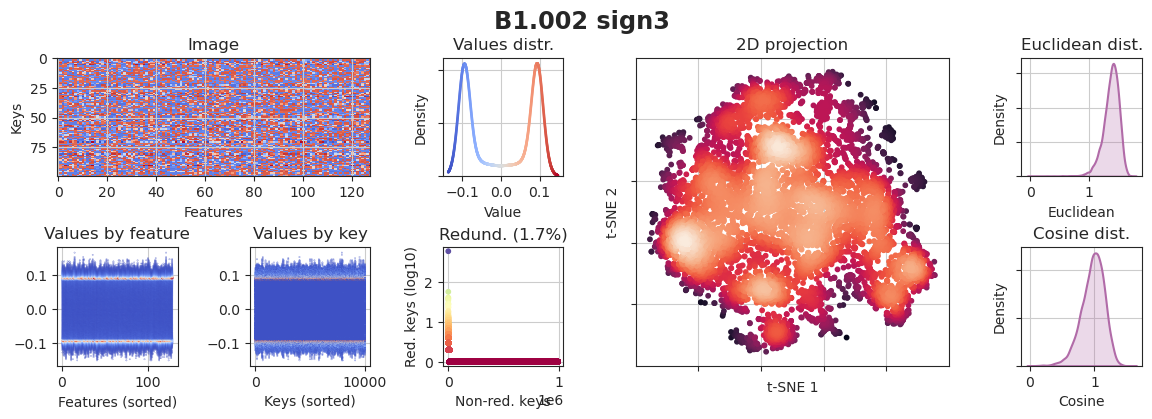

In [5]:
# Instantiation of diag3 (diagnosis plots)
sign3 = cc_local.signature(dataset, 'sign3')
diag3 = sign3.diagnosis(ref_cctype='sign3')

# Plot medium & small diagnosis plots
diag3.canvas(size='medium', savefig=True, savefig_kwargs={'dpi': 300})
diag3.canvas(size='small', savefig=True, savefig_kwargs={'dpi': 300})